<a href="https://colab.research.google.com/github/babi00/ai4biological-pattern/blob/guido-clean/model_grid_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classificatore specie:
- input: immagine
- output label: nativa/non nativa e non invasiva/non nativa e invasiva
La struttura del modello utilizzato è simile a quella precedentemente implementata:
le immagini passano attraverso un modello preallenato (BioCLIP o ResNet) da cui vengono estratti gli embedding
gli embedding allenano un semplice classificatore.

La loss function è stata modificata: ogni classe ha il suo peso (dipendente dalla frequenza della classe).

Durante il training le fasi di estrazione degli embedding e predizione del label sono separate (così che il training sia molto più veloce e leggero). Una volta finito il training viene ricostruito il modello intero, così che il classificatore prenda come input l'immagine (non l'embedding) e restituisca il label (in modo che si possa effettuare successivamente explainability sulle immagini e non solo sugli embedding).

Rispetto al modello di Barbara, estraggo gli embeddings tutti insieme (e non separati per training set e validation set), così da poter effettuare cross validation senza dover ogni volta estrarre gli embeddings.

In [1]:
#@title Imports and downloads
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import functional as TF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision import transforms, models
# from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix, ConfusionMatrixDisplay, f1_score
# import seaborn as sns
# import requests
# from io import BytesIO
from google.colab import drive
import time
from tqdm import tqdm
!pip install open_clip_torch
import open_clip
# import random
import math
from collections import Counter
import datetime
import json
import os

torch.manual_seed(42)
np.random.seed(42)

drive.mount('/content/drive')

# Clone the repository and checkout the 'clean-barbara' branch
!git clone --branch clean-barbara https://github.com/babi00/ai4biological-pattern.git
%cd ai4biological-pattern

# Enable sparse checkout
!git sparse-checkout init --cone

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'ai4biological-pattern' already exists and is not an empty directory.
/content/ai4biological-pattern


In [2]:
#@title Traning log saving function
def save_training_log(model_name, output_dir, train_losses, val_losses, train_accuracies, val_accuracies, classification_report_dict):
    import datetime
    import json
    import os

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log_dir = f"/content/drive/MyDrive/Thesis/{output_dir}/logs"
    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, "training_log.json")

    # Load existing logs (if any)
    if os.path.exists(log_path):
        with open(log_path, "r") as f:
            all_logs = json.load(f)
    else:
        all_logs = []

    # Prepare this run's data
    this_log = {
        "model_name": model_name,
        "timestamp": timestamp,
        "final_train_loss": train_losses[-1] if train_losses else None,
        "final_val_loss": val_losses[-1] if val_losses else None,
        "final_train_accuracy": train_accuracies[-1] if train_accuracies else None,
        "final_val_accuracy": val_accuracies[-1] if val_accuracies else None,
        "classification_report_last_epoch": classification_report_dict[-1] if isinstance(classification_report_dict, list) else classification_report_dict,
        "train_loss_history": train_losses,
        "val_loss_history": val_losses,
        "train_accuracy_history": train_accuracies,
        "val_accuracy_history": val_accuracies
    }

    all_logs.append(this_log)

    # Save updated list
    with open(log_path, "w") as f:
        json.dump(all_logs, f, indent=4)

    print(f"📝 Appended log to {log_path}")


In [20]:
#@title Horizontal flip
def hflip(image):
  return TF.hflip(image)

In [4]:
#@title Original Dataset
class InvasiveSpeciesDataset(Dataset):
    def __init__(self, root_dir, transform=None, get_label_fn=None):
        self.root_dir = root_dir
        self.transform = transform
        self.entries = []
        self.label_map = {
            "native": 0,
            "introduced non-invasive": 1,
            "invasive": 2
        }

        taxa_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d)) and d != "metadata"]
        for taxon in taxa_folders:
            meta_path = os.path.join(root_dir, "filtered_metadata", f"{taxon}_metadata.csv")
            if not os.path.exists(meta_path):
                continue
            metadata_df = pd.read_csv(meta_path)
            for idx, row in metadata_df.iterrows():
                self.entries.append((taxon, row))  # Just index, don’t open anything

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        taxon, row = self.entries[idx]
        filename = str(row["filename"])
        image_path = os.path.join(self.root_dir, taxon, filename)
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.label_map.get(row["label"])
        return image, label, idx

In [5]:
#@title Augmented Dataset
class AugmentedClass1Dataset(Dataset):
  def __init__(self, original_dataset, transform=None):
    self.original_dataset = original_dataset
    self.transform = transform
    self.entries = [entry for entry in original_dataset.entries if original_dataset.label_map.get(entry[1]["label"]) == 1]
    self.root_dir = original_dataset.root_dir

  def __len__(self):
    return len(self.entries)

  def __getitem__(self, idx):
    taxon, row = self.entries[idx]
    filename = str(row['filename'])
    image_path = os.path.join(self.root_dir, taxon, filename)
    image = Image.open(image_path).convert("RGB")
    if self.transform:
        image = self.transform(image)
    label = 1
    return image, label, idx

In [6]:
#@title Return the dataloader of all images and not already separated (also class weights are not present)
def get_data_loader(root_dir, batch_size=32, use_bioclip=True, preprocess=None):
    if use_bioclip and preprocess:
        transform = preprocess
    else:
        transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor()
        ])

    dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        transform=transform,
    )

    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    return loader

In [7]:
#@title helper functions
def get_augmented_transform_flipping(preprocess=None):

    if preprocess:
        # BioCLIP: use its own preprocessing, plus flipping
        return transforms.Compose([
            transforms.Lambda(lambda img: TF.hflip(img)),
            preprocess
        ])
    else:
        # ResNet or default: manual transform
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Lambda(lambda img: TF.hflip(img)),
            transforms.ToTensor()
        ])


def get_augmented_transform_jitter(preprocess=None):

    if preprocess:
        # BioCLIP: use its own preprocessing, plus jittering (no hue modification)
        return transforms.Compose([
            transforms.ColorJitter(0.3, 0.3, 0.3),
            preprocess
        ])
    else:
        # ResNet or default: manual transform
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ColorJitter(0.3, 0.3, 0.3),
            transforms.ToTensor()
        ])

In [8]:
#@title Augmented DataLoader
def get_data_loader_augmented(root_dir, batch_size=32, use_bioclip=True, preprocess=None, augmentation='flipping'):
    if use_bioclip and preprocess:
        original_transform = preprocess
    else:
        original_transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor(),
          # transforms.RandomHorizontalFlip(p=1.0)
        ])

    if augmentation=='flipping':
      augmented_transform = get_augmented_transform_flipping(preprocess if use_bioclip else None)
    elif augmentation=='jittering':
      augmented_transform = get_augmented_transform_jitter(preprocess if use_bioclip else None)
    else:
      print("Error in the augmentation!")
      augmented_transform = -1 #this will break after


    original_dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        transform=original_transform,
    )

    augmented_dataset = AugmentedClass1Dataset(
        original_dataset=original_dataset,
        transform=augmented_transform,
    )

    augmented_loader = DataLoader(augmented_dataset, batch_size=32, shuffle=False)

    return augmented_loader

In [9]:
#@title 2.Define the embedding extractor:
#ResNet without the last FC layer
def get_resnet_embeddings_extractor_model():
    #Use a pre-trained ResNet18 model
    model = models.resnet18(weights='IMAGENET1K_V1')

    #Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    embeddings_extractor= nn.Sequential(*list(model.children())[:-1]) #removes the last FC layer
    print("Model obtained...")

    return embeddings_extractor

#BioCLIP model
def get_bioclip_embeddings_extractor_model(device, bioclip_version=2):
    if bioclip_version==2:
        print("BioCLIP 2!")
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip-2')
    else:
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
    print("Model obtained...")
    model.to(device)
    model.eval()
    return model, preprocess

In [10]:
#@title 3. Extract embeddings using the embeddings_extractor and return the embeddings tensors
def extract_embeddings(dataloader, embeddings_extractor, device, embeddings_save_path, augmented=False, use_bioclip=True):
    embeddings_extractor.eval()
    all_embeddings = []
    all_labels = []
    all_ids = []

    if use_bioclip:
      with torch.no_grad():
        for images, labels, obs_id in tqdm(dataloader, desc='Extracting embeddings'):
            images = images.to(device)
            embeddings = embeddings_extractor.encode_image(images)
            embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)  # Optional: normalize
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_ids.extend(obs_id)

    else:
      with torch.no_grad():
        for images, labels, obs_id in tqdm(dataloader, desc='Extracting embeddings'):
            images = images.to(device)
            embeddings = embeddings_extractor(images).view(images.size(0), -1)
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_ids.extend(obs_id)

    embeddings_tensors = torch.cat(all_embeddings, dim=0).to(device)
    labels_tensors = torch.cat(all_labels, dim=0).to(device)
    obs_id_tensor = torch.tensor(all_ids).to(device)

    all_embeddings = {
       'embeddings' : embeddings_tensors,
       'labels' : labels_tensors,
       'ids' : obs_id_tensor
    }

    if augmented==False:
      torch.save(all_embeddings, embeddings_save_path)

    # embedding_size = embeddings_tensors.shape[1] #useful for classifier

    return all_embeddings

In [11]:
#@title Split the embeddings 80-20, then add the augmentation to the training set
def split_embeddings(embeddings_dict, augmented_embeddings_dict=None, val_percentage=0.2):

    """Split the embeddings and not the images into training set and validation set"""

    embeddings_tensors = embeddings_dict["embeddings"]
    labels_tensors = embeddings_dict["labels"]
    obs_id_tensor = embeddings_dict["ids"]

    embedding_size = embeddings_tensors.shape[1] #useful for classifier

    dataset = torch.utils.data.TensorDataset(embeddings_tensors, labels_tensors, obs_id_tensor)

    train_size = int((1-val_percentage) * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    #if using augmentation
    if augmented_embeddings_dict:
      print("Augmenting train dataset...")
      aug_embeddings_tensors = augmented_embeddings_dict["embeddings"]
      aug_labels_tensors = augmented_embeddings_dict["labels"]
      aug_obs_id_tensor = augmented_embeddings_dict["ids"]

      augmented_train_dataset = torch.utils.data.TensorDataset(aug_embeddings_tensors, aug_labels_tensors, aug_obs_id_tensor)

      #concatenate train dataset with augmented train dataset
      train_dataset = ConcatDataset([train_dataset, augmented_train_dataset])

    label_counts = Counter()
    for _, label, _ in train_dataset:
        label_counts[int(label)] += 1

    print("🔢 Class distribution in train set:", label_counts)

    # total = sum(label_counts.values())
    class_weights = torch.tensor([
        1.0 / math.log(1.02 + label_counts[0]),
        1.0 / math.log(1.02 + label_counts[1]),
        1.0 / math.log(1.02 + label_counts[2]),
    ], dtype=torch.float)

    print("⚖️ Class weights:", class_weights)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=True)

    return train_loader, val_loader, class_weights, embedding_size

In [12]:
#@title Classifier
class InvasiveSpeciesClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=256, num_classes=3):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(), #consider adding a Dropout layer
            # nn.Dropout(0.3), #We remove the dropout layer
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

In [13]:
#@title Early Stopping class

#Patience: how many epochs to wait after last improvements
#delta: minimum change in validation to be considered improvement
class EarlyStopping:

    def __init__(self, patience=5, delta=0.01, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Stopping early as no improvement has been observed.")

In [14]:
#@title 4. Training function
def train_classifier(train_loader, val_loader, feature_extractor, classifier, optimizer, criterion, device, output_dir, model_name, num_epoch=10, verbose=True, save_classifier=False):

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    early_stopping = EarlyStopping(patience=10, delta=0, verbose=True)

    for epoch in range(num_epoch):
        print(f"\n🔁 Epoch {epoch + 1}/{num_epoch}")
        classifier.train()
        running_loss, correct, total = 0, 0, 0

        for embeddings, labels, _ in tqdm(train_loader, desc="Training"): # Unpack all three values
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc, y_true, y_pred = evaluate_classifier(
            val_loader, feature_extractor, classifier, criterion, device
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if verbose:
            print(f"📉 Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
            print(f"📈 Val Loss:   {val_loss:.4f} | Accuracy: {val_acc:.4f}")

            print("\n📋 Classification Report:")
            report_dict = classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=["Native", "NN Non-Invasive", "NN Invasive"], zero_division=0, output_dict=True)
            print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=["Native", "NN Non-Invasive", "NN Invasive"], zero_division=0, output_dict=False))

            #plot confusion matrix
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
            fig, ax = plt.subplots(figsize=(6, 6))
            im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
            ax.figure.colorbar(im, ax=ax)
            classes = ["Native", "NN-NI", "NN-I"]

            # Show all ticks and label them
            ax.set(xticks=np.arange(len(classes)),
                yticks=np.arange(len(classes)),
                xticklabels=classes,
                yticklabels=classes,
                ylabel='True label',
                xlabel='Predicted label',
                title='Validation Confusion Matrix')

            # Rotate the tick labels and set alignment.
            plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

            # Loop over data dimensions and create text annotations.
            fmt = 'd'
            thresh = cm.max() / 2. if cm.max() > 0 else 1
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, format(cm[i, j], fmt),
                            ha="center", va="center",
                            color="white" if cm[i, j] > thresh else "black")

            fig.tight_layout()
            plt.grid(False)
            plt.show()
        else:
          report_dict = None

        # Check early stopping condition
        early_stopping.check_early_stop(val_loss)

        if early_stopping.stop_training:
          print(f"Early stopping at epoch {epoch}")
          break


    torch.save(classifier.state_dict(), f'classifier_head_{model_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/Thesis/{output_dir}/classifier_head_{model_name}.pth'
    torch.save(classifier.state_dict(), google_drive_path)

    return train_losses, train_accuracies, val_losses, val_accuracies, report_dict

In [15]:
#@title 5. Evaluation function
def evaluate_classifier(loader, feature_extractor, classifier, criterion, device):
    classifier.eval()
    total_loss, correct, total = 0, 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for embeddings, labels, obs_ids in tqdm(loader, desc="Evaluating"): # Unpack all three values
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc, all_labels, all_preds

In [16]:
#@title Focal loss function

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        alpha: Class weighting (tensor or list), same as in CrossEntropyLoss
        gamma: Focusing parameter (higher → more focus on hard samples) (gamma=0 => cross entropy loss)
        reduction: 'mean', 'sum', or 'none'
        """
        super(FocalLoss, self).__init__()
        self.alpha=alpha
        self.gamma=gamma
        self.reduction=reduction

    def forward(self, inputs, targets):
        #cross entropy per sample (no reduction)
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')

        #convert to probabilities of true class for modulating factor
        pt = torch.exp(-ce_loss) #ce = -log(pt), so pt = e^(-ce), model confidence of true class

        #focal loss formula (focal term)
        focal_loss = ((1-pt)**self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean() #return average loss per batch
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [17]:
#@title Full Model
class FullModel(nn.Module):
    def __init__(self, embedding_model, classifier_head):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier_head = classifier_head

    def forward(self, x):
        with torch.no_grad():
            if hasattr(self.encoder, 'encode_image'):
                features = self.encoder.encode_image(x)
            else:
                features = self.encoder(x)

        if features.ndim == 4:
            features = features.view(features.size(0), -1)

        return self.classifier_head(features)

In [18]:
#@title Create model and predict
def create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=None, augmentation=False, augmentation_factor=2, loss_type='CE', output_dir="invasive_species", model_name="prova", verbose=True, save_model=True, embeddings_save_path=None, epochs=50, debug_subset_size=None):
    start_time = time.time()

    model_name = f'bioclip_2_{model_name}' if use_bioclip and bioclip_version==2 else f'bioclip_1_{model_name}' if use_bioclip else f'resnet_{model_name}'

    github = '/content/ai4biological-pattern/barbara_new'
    github_repository = f'{github}/{folder_name}'

    if not os.path.isdir(github_repository): #check if data has already been downloaded
        !git sparse-checkout set barbara_new/{folder_name}
        !git checkout clean-barbara

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    if use_bioclip:
        feature_extractor, preprocess = get_bioclip_embeddings_extractor_model(device, bioclip_version)
        feature_extractor = feature_extractor.to(device)
    else:
        feature_extractor = get_resnet_embeddings_extractor_model()
        feature_extractor = feature_extractor.to(device)
        preprocess = None
    print("Feature extractor obtained..")


    if os.path.exists(embeddings_save_path):

        print("✅ Embeddings already exist, loading from file...")
        embeddings_dict = torch.load(embeddings_save_path)
        # embeddings = embeddings_dict["embeddings"]
        # labels = embeddings_dict["labels"]
        # ids = embeddings_dict["ids"]

        #now get only images of class 1 from the original dataset, pass them to the function and concatenate the original training dataset and the augmented dataset
        img_loader = get_data_loader(root_dir=github_repository)

        if augmentation:
          #only extract embeddings for augmentated data
          augmented_loader = get_data_loader_augmented(root_dir=github_repository, augmentation='flipping')
          augmented_embeddings_dict = extract_embeddings(augmented_loader, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

          if augmentation_factor==3:
            augmented_loader_2 = get_data_loader_augmented(root_dir=github_repository, augmentation='jittering')
            augmented_embeddings_dict_2 = extract_embeddings(augmented_loader_2, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

            augmented_embeddings_dict = {
              "embeddings": torch.cat([augmented_embeddings_dict["embeddings"], augmented_embeddings_dict_2["embeddings"]]),
              "labels": torch.cat([augmented_embeddings_dict["labels"], augmented_embeddings_dict_2["labels"]]),
              "ids": torch.cat([augmented_embeddings_dict["ids"], augmented_embeddings_dict_2["ids"]])
            }

        else:
          augmented_embeddings_dict=None

        if debug_subset_size is not None:
          print(f"⚠ Debug mode: using only the first {debug_subset_size} embeddings.")
          embeddings_dict['embeddings'] = embeddings_dict['embeddings'][:debug_subset_size]
          embeddings_dict['labels'] = embeddings_dict['labels'][:debug_subset_size]
          embeddings_dict['ids'] = embeddings_dict['ids'][:debug_subset_size]

          if augmentation:
            augmented_embeddings_dict['embeddings'] = augmented_embeddings_dict['embeddings'][:debug_subset_size]
            augmented_embeddings_dict['labels'] = augmented_embeddings_dict['labels'][:debug_subset_size]
            augmented_embeddings_dict['ids'] = augmented_embeddings_dict['ids'][:debug_subset_size]
          else:
            augmented_embeddings_dict=None


        #to this function I will pass both extracted embeddings and augmented embeddings (if they exist)
        embeddings_train_loader, embeddings_val_loader, class_weights, input_size = split_embeddings(embeddings_dict, augmented_embeddings_dict, val_percentage=0.2)

    else:

        img_loader = get_data_loader(root_dir=github_repository)
        print("Dataloader obtained..")

        #this function also saves embeddings in the desired path
        #input size is the same for training and validation, is is the size (number of features) of the single embedding.
        embeddings_dict = extract_embeddings(img_loader, feature_extractor, device, use_bioclip, embeddings_save_path)

        if augmentation:
          #only extract embeddings for augmentated data
          augmented_loader = get_data_loader_augmented(root_dir=github_repository)
          augmented_embeddings_dict = extract_embeddings(augmented_loader, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

          if augmentation_factor==3:
            augmented_loader_2 = get_data_loader_augmented(root_dir=github_repository, augmentation='jittering')
            augmented_embeddings_dict_2 = extract_embeddings(augmented_loader_2, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

            augmented_embeddings_dict = {
              "embeddings": torch.cat([augmented_embeddings_dict["embeddings"], augmented_embeddings_dict_2["embeddings"]]),
              "labels": torch.cat([augmented_embeddings_dict["labels"], augmented_embeddings_dict_2["labels"]]),
              "ids": torch.cat([augmented_embeddings_dict["ids"], augmented_embeddings_dict_2["ids"]])
            }

        else:
          augmented_embeddings_dict=None

        if debug_subset_size is not None:
          print(f"⚠ Debug mode: using only the first {debug_subset_size} embeddings.")
          embeddings_dict['embeddings'] = embeddings_dict['embeddings'][:debug_subset_size]
          embeddings_dict['labels'] = embeddings_dict['labels'][:debug_subset_size]
          embeddings_dict['ids'] = embeddings_dict['ids'][:debug_subset_size]

          if augmentation:
            augmented_embeddings_dict['embeddings'] = augmented_embeddings_dict['embeddings'][:debug_subset_size]
            augmented_embeddings_dict['labels'] = augmented_embeddings_dict['labels'][:debug_subset_size]
            augmented_embeddings_dict['ids'] = augmented_embeddings_dict['ids'][:debug_subset_size]
          else:
            augmented_embeddings_dict=None

        embeddings_train_loader, embeddings_val_loader, class_weights, input_size = split_embeddings(embeddings_dict, augmented_embeddings_dict, val_percentage=0.2)


    classifier = InvasiveSpeciesClassifier(embedding_dim=input_size).to(device)
    if loss_type=='CE':
      criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    elif loss_type=='FL':
       criterion = FocalLoss(alpha=class_weights.to(device), gamma=2, reduction='mean')
    optimizer = optim.Adam(classifier.parameters(), lr=1e-4)


    train_losses, train_accuracies, val_losses, val_accuracies, report_dict = train_classifier(
        train_loader=embeddings_train_loader,
        val_loader=embeddings_val_loader,
        feature_extractor=feature_extractor,
        classifier=classifier,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        output_dir=output_dir,
        model_name=model_name,
        num_epoch=epochs,
        verbose=verbose,
        save_classifier=save_model
    )

    # Save results
    save_training_log(model_name, output_dir, train_losses, val_losses, train_accuracies, val_accuracies, report_dict)

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Train Loss')
    plt.plot(epochs, val_losses, 'ro-', label='Val Loss')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'bo-', label='Train Accuracy')
    plt.plot(epochs, val_accuracies, 'ro-', label='Val Accuracy')
    plt.title("Accuracy over Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    full_model = FullModel(feature_extractor, classifier)
    print("Full model built...")
    full_model.eval()

    if save_model:
      torch.save(full_model.state_dict(), f'full_{model_name}.pth')
      google_drive_path = f'/content/drive/MyDrive/Thesis/{output_dir}/full_{model_name}.pth'
      torch.save(full_model.state_dict(), google_drive_path)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total execution time: {elapsed_time:.2f} seconds")

    #return the validation loss and accuracy for the last epoch
    return val_losses[-1], val_accuracies[-1]

In [21]:
#prima versione, nel get_data_loader veniva utilizzato:
#class_weights = torch.tensor([
#        total / label_counts[0],  #Native
#        total / label_counts[1],  #NN Non-Invasive
#        total / label_counts[2],  #NN Invasive
#    ], dtype=torch.float)
# create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=True, output_dir="invasive_species", model_name="first_attempt_with_class_weighting")

Using device: cuda
Model obtained...
Feature extractor obtained..
✅ Embeddings already exist, loading from file...


Extracting embeddings: 100%|██████████| 29/29 [00:12<00:00,  2.26it/s]


Augmenting train dataset...
🔢 Class distribution in train set: Counter({0: 24736, 2: 9664, 1: 1634})
⚖️ Class weights: tensor([0.0989, 0.1351, 0.1090])

🔁 Epoch 1/1


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 425.17it/s]


📉 Train Loss: 0.7464 | Accuracy: 0.6888
📈 Val Loss:   0.6778 | Accuracy: 0.7084

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.74      0.92      0.82      6220
NN Non-Invasive       0.00      0.00      0.00       174
    NN Invasive       0.50      0.21      0.29      2389

       accuracy                           0.71      8783
      macro avg       0.41      0.38      0.37      8783
   weighted avg       0.66      0.71      0.66      8783



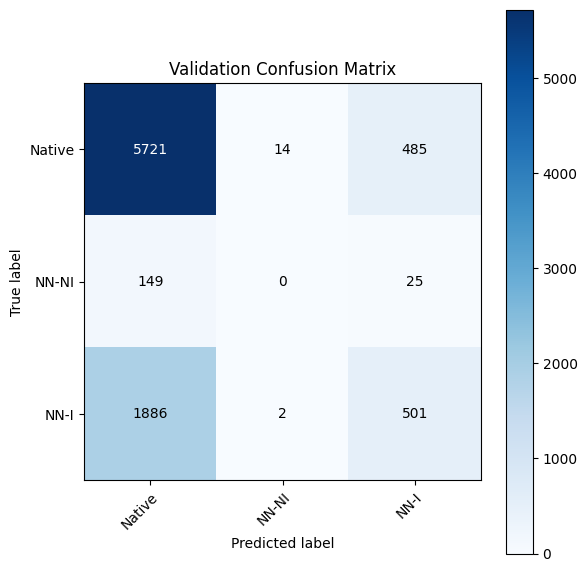

📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


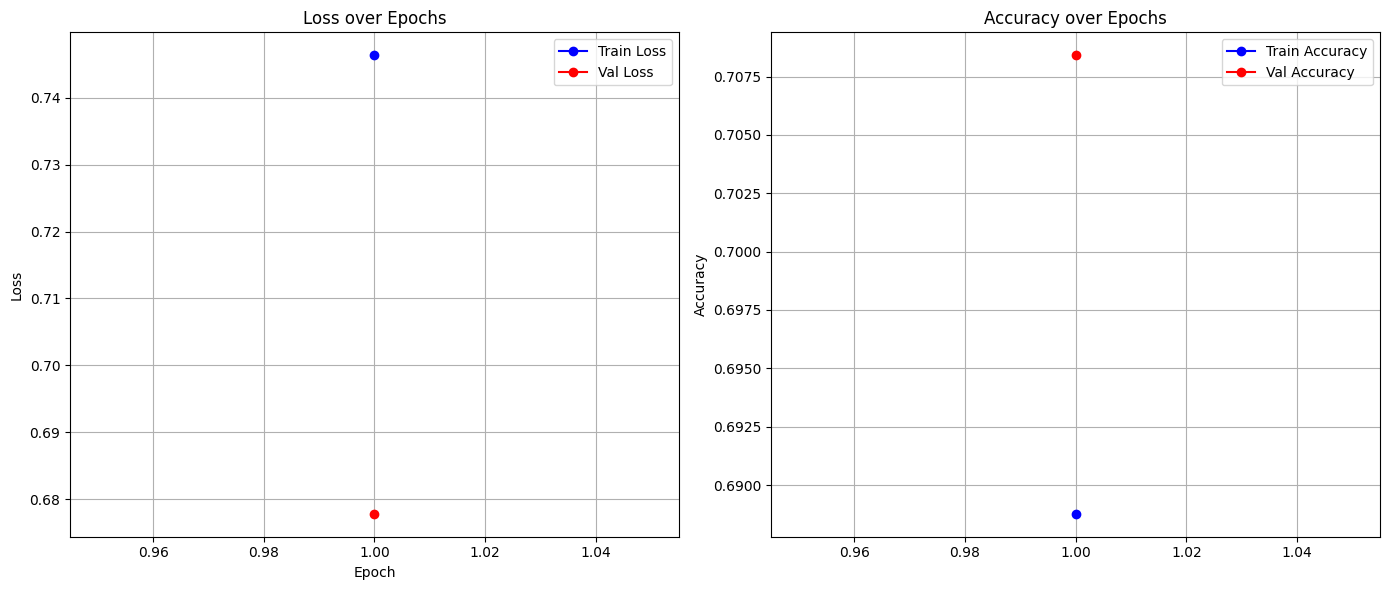

Full model built...
Total execution time: 42.12 seconds


(0.6778010524691448, 0.7084139815552772)

In [19]:
model_name = "epochs_50_augmented"
embeddings_save_path = '/content/drive/MyDrive/Thesis/resnet_embeddings.pt'
create_model_and_predict(folder_name="taxas", use_bioclip=False, augmentation=True, output_dir="invasive_species", model_name=model_name, embeddings_save_path=embeddings_save_path, epochs=1, debug_subset_size=None)

In [23]:
# model_name_BC1 = "epochs_50_augmented"
# embeddings_save_path_BC1 = '/content/drive/MyDrive/Thesis/bioclip_1_embeddings.pt'
# create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=1, augmentation=True, output_dir="invasive_species", model_name=model_name_BC1, embeddings_save_path=embeddings_save_path_BC1, debug_subset_size=None)

In [24]:
# model_name_BC2 = "epochs_50_augmented"
# embeddings_save_path_BC2 = '/content/drive/MyDrive/Thesis/bioclip_2_embeddings.pt'
# create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=True, bioclip_version=2, output_dir="invasive_species", model_name=model_name, embeddings_save_path=embeddings_save_path_BC2, debug_subset_size=None)

### Augmentation Flipping+Jittering

In [25]:
# epochs=50
# model_name = "epochs_50_augmented_twice"
# embeddings_save_path = '/content/drive/MyDrive/Thesis/resnet_embeddings.pt'
# create_model_and_predict(folder_name="taxas", use_bioclip=False, augmentation=True, output_dir="invasive_species", model_name=model_name, embeddings_save_path=embeddings_save_path, epochs=epochs, debug_subset_size=None)

In [26]:
# epochs=50
# model_name_BC1 = "epochs_50_augmented_twice"
# embeddings_save_path_BC1 = '/content/drive/MyDrive/Thesis/bioclip_1_embeddings.pt'
# create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=1, augmentation=True, output_dir="invasive_species", model_name=model_name_BC1, embeddings_save_path=embeddings_save_path_BC1, epochs=epochs, debug_subset_size=None)

In [27]:
# epochs = 50
# model_name_BC2 = "epochs_50_augmented_twice"
# embeddings_save_path_BC2 = '/content/drive/MyDrive/Thesis/bioclip_2_embeddings.pt'
# create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=True, bioclip_version=2, output_dir="invasive_species", model_name=model_name, embeddings_save_path=embeddings_save_path_BC2, epochs=epochs, debug_subset_size=None)

Hyperparameters:

- epochs
- augmentation_factor (No, x2, x3)
- loss (CrossEntropy, FocalLoss)

In [32]:
#@title Grid Search

augmentation_factors = [2,3]
losses = ['CE', 'FL']
augmentations = [False, True]

best_hp = {
    'augmentation': None,
    'loss_type': None,
    'factor': None,
    'val_loss': None,
    'val_accuracy': None
}

epochs = 50
model_name_BC2 = "hp_tuning_best_BC2"
embeddings_save_path_BC2 = '/content/drive/MyDrive/Thesis/bioclip_2_embeddings.pt'

best_accuracy = None

for loss_type in losses:
    for augmentation in augmentations:

        if not augmentation:
            print(f"Launching model with hyperparameters {augmentation}, {loss_type}")
            val_loss, val_accuracy = create_model_and_predict(
                folder_name="taxas", use_bioclip=True, augmentation=augmentation,
                augmentation_factor=None, loss_type=loss_type,
                bioclip_version=2, output_dir="invasive_species", model_name=model_name_BC2,
                save_model=False, verbose=False, embeddings_save_path=embeddings_save_path_BC2,
                epochs=epochs, debug_subset_size=None
            )

            if best_accuracy is None or val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_hp.update({
                    'augmentation': augmentation,
                    'loss_type': loss_type,
                    'factor': None,
                    'val_loss': val_loss,
                    'val_accuracy': val_accuracy
                })

        else:
            for factor in augmentation_factors:
                print(f"Launching model with hyperparameters {augmentation}, {loss_type}, {factor}")
                val_loss, val_accuracy = create_model_and_predict(
                    folder_name="taxas", use_bioclip=True, augmentation=augmentation,
                    augmentation_factor=factor, loss_type=loss_type,
                    bioclip_version=2, output_dir="invasive_species", model_name=model_name_BC2,
                    save_model=False, verbose=False, embeddings_save_path=embeddings_save_path_BC2,
                    epochs=epochs, debug_subset_size=None
                )

                if best_accuracy is None or val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_hp.update({
                        'augmentation': augmentation,
                        'loss_type': loss_type,
                        'factor': factor,
                        'val_loss': val_loss,
                        'val_accuracy': val_accuracy
                    })

print("Best hyperparameters for the model BioCLIP 2:")
print(best_hp)


Launching model with hyperparameters False, CE
Using device: cuda
BioCLIP 2!


KeyboardInterrupt: 

Using device: cuda
BioCLIP 2!


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

open_clip_config.json:   0%|          | 0.00/534 [00:00<?, ?B/s]

Model obtained...
Feature extractor obtained..
✅ Embeddings already exist, loading from file...


Extracting embeddings: 100%|██████████| 29/29 [00:47<00:00,  1.63s/it]


Augmenting train dataset...
🔢 Class distribution in train set: Counter({0: 24750, 2: 9650, 1: 1634})
⚖️ Class weights: tensor([0.0988, 0.1351, 0.1090])

🔁 Epoch 1/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 723.12it/s]


📉 Train Loss: 0.7048 | Accuracy: 0.7013
📈 Val Loss:   0.5412 | Accuracy: 0.7519

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.81      0.84      0.83      6206
NN Non-Invasive       0.00      0.00      0.00       174
    NN Invasive       0.58      0.57      0.58      2403

       accuracy                           0.75      8783
      macro avg       0.47      0.47      0.47      8783
   weighted avg       0.73      0.75      0.74      8783



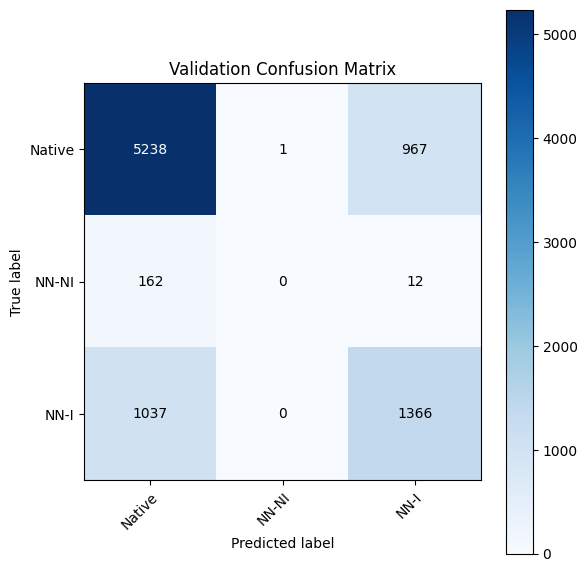


🔁 Epoch 2/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1045.08it/s]


📉 Train Loss: 0.5625 | Accuracy: 0.7361
📈 Val Loss:   0.4886 | Accuracy: 0.7653

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.83      0.84      0.84      6206
NN Non-Invasive       0.47      0.05      0.09       174
    NN Invasive       0.60      0.61      0.61      2403

       accuracy                           0.77      8783
      macro avg       0.64      0.50      0.51      8783
   weighted avg       0.76      0.77      0.76      8783



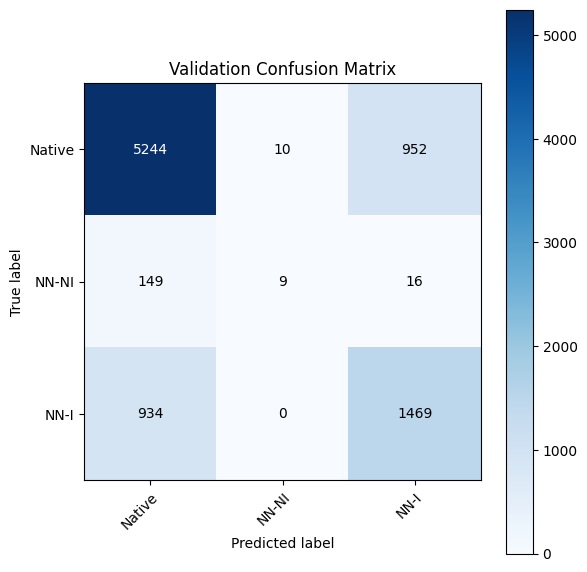


🔁 Epoch 3/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1113.71it/s]


📉 Train Loss: 0.5198 | Accuracy: 0.7536
📈 Val Loss:   0.4689 | Accuracy: 0.7774

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.84      0.84      6206
NN Non-Invasive       0.41      0.20      0.27       174
    NN Invasive       0.63      0.65      0.64      2403

       accuracy                           0.78      8783
      macro avg       0.63      0.56      0.58      8783
   weighted avg       0.78      0.78      0.78      8783



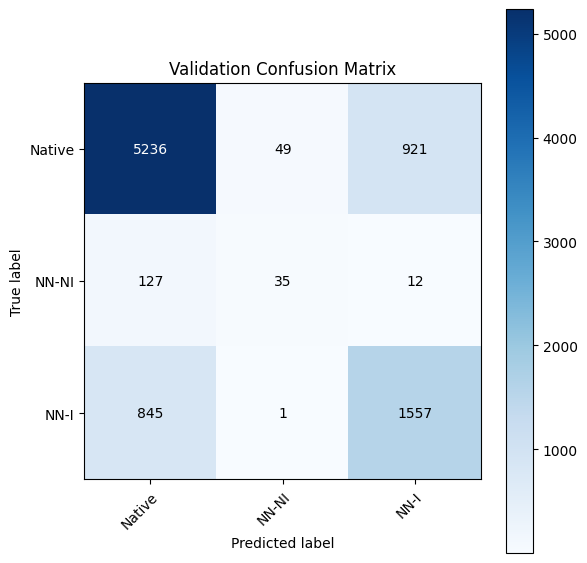


🔁 Epoch 4/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1106.77it/s]


📉 Train Loss: 0.4967 | Accuracy: 0.7672
📈 Val Loss:   0.4559 | Accuracy: 0.7874

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.86      0.85      6206
NN Non-Invasive       0.42      0.30      0.35       174
    NN Invasive       0.65      0.63      0.64      2403

       accuracy                           0.79      8783
      macro avg       0.64      0.60      0.62      8783
   weighted avg       0.78      0.79      0.79      8783



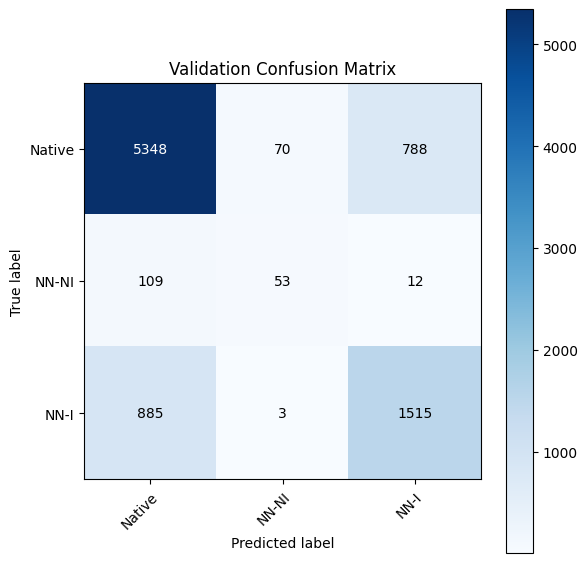


🔁 Epoch 5/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1124.50it/s]


📉 Train Loss: 0.4807 | Accuracy: 0.7750
📈 Val Loss:   0.4482 | Accuracy: 0.7903

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.86      0.85      6206
NN Non-Invasive       0.38      0.36      0.37       174
    NN Invasive       0.67      0.63      0.65      2403

       accuracy                           0.79      8783
      macro avg       0.63      0.62      0.62      8783
   weighted avg       0.79      0.79      0.79      8783



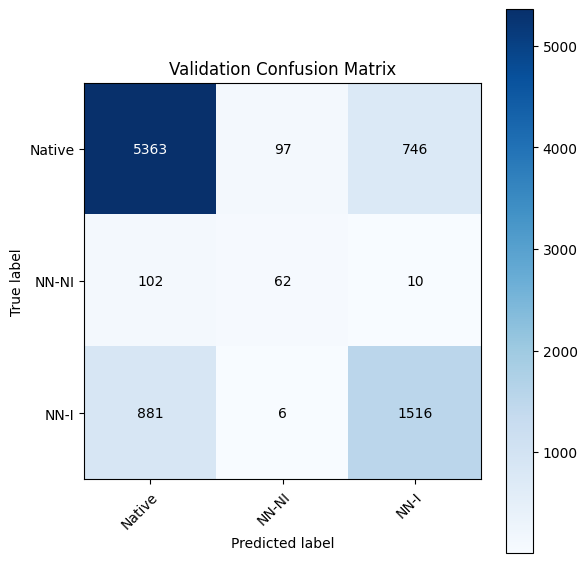


🔁 Epoch 6/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 687.51it/s]


📉 Train Loss: 0.4687 | Accuracy: 0.7815
📈 Val Loss:   0.4408 | Accuracy: 0.7905

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.83      0.85      6206
NN Non-Invasive       0.37      0.40      0.38       174
    NN Invasive       0.65      0.71      0.68      2403

       accuracy                           0.79      8783
      macro avg       0.63      0.65      0.64      8783
   weighted avg       0.80      0.79      0.79      8783



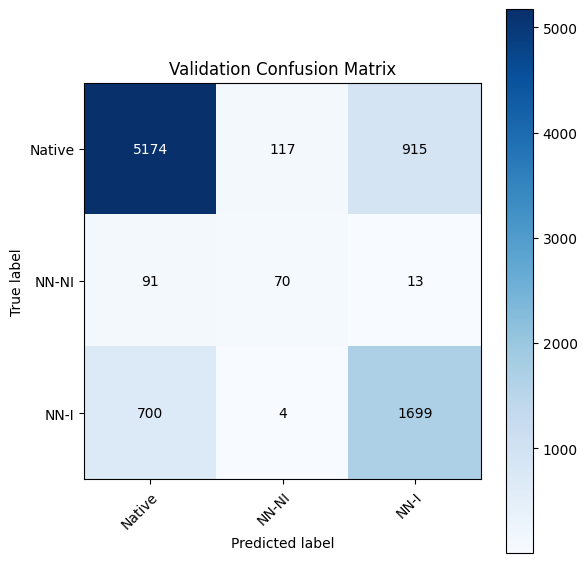


🔁 Epoch 7/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1119.90it/s]


📉 Train Loss: 0.4590 | Accuracy: 0.7872
📈 Val Loss:   0.4307 | Accuracy: 0.7981

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.87      0.86      6206
NN Non-Invasive       0.37      0.34      0.36       174
    NN Invasive       0.68      0.65      0.67      2403

       accuracy                           0.80      8783
      macro avg       0.63      0.62      0.63      8783
   weighted avg       0.80      0.80      0.80      8783



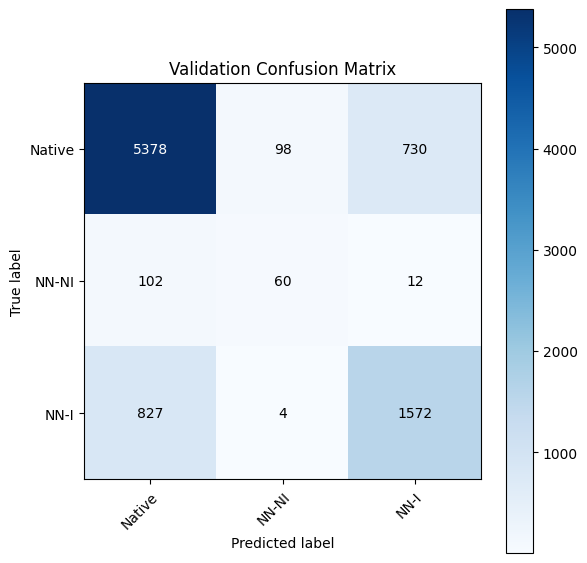


🔁 Epoch 8/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1109.01it/s]


📉 Train Loss: 0.4507 | Accuracy: 0.7923
📈 Val Loss:   0.4234 | Accuracy: 0.8034

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.88      0.86      6206
NN Non-Invasive       0.45      0.36      0.40       174
    NN Invasive       0.69      0.64      0.66      2403

       accuracy                           0.80      8783
      macro avg       0.66      0.62      0.64      8783
   weighted avg       0.80      0.80      0.80      8783



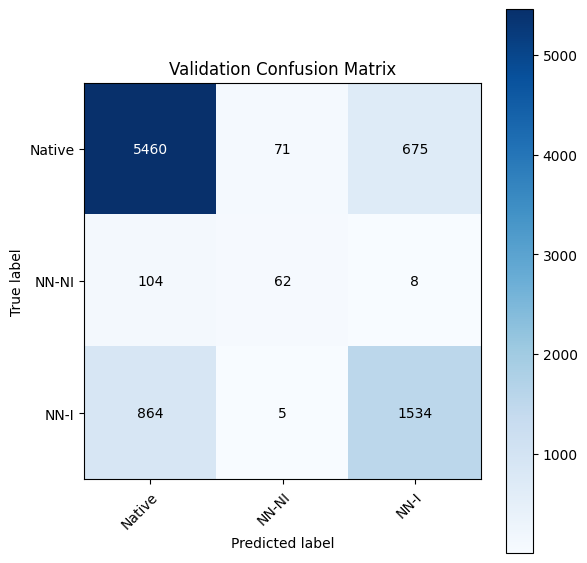


🔁 Epoch 9/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1019.23it/s]


📉 Train Loss: 0.4439 | Accuracy: 0.7977
📈 Val Loss:   0.4229 | Accuracy: 0.8029

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.89      0.87      6206
NN Non-Invasive       0.40      0.37      0.39       174
    NN Invasive       0.71      0.60      0.65      2403

       accuracy                           0.80      8783
      macro avg       0.65      0.62      0.64      8783
   weighted avg       0.80      0.80      0.80      8783



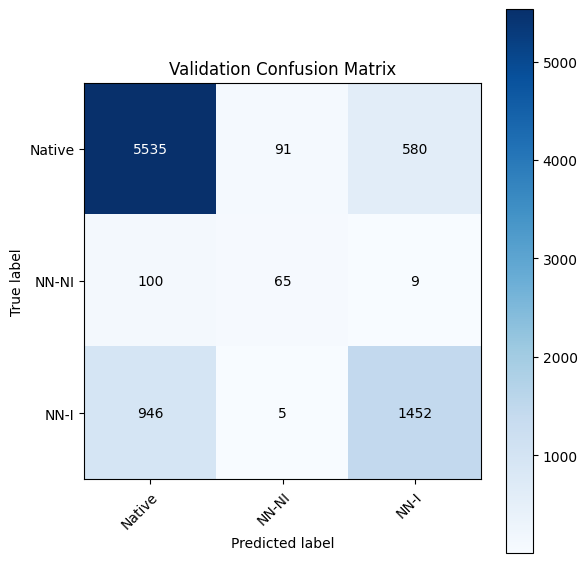


🔁 Epoch 10/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 768.06it/s]


📉 Train Loss: 0.4375 | Accuracy: 0.8005
📈 Val Loss:   0.4206 | Accuracy: 0.7982

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.83      0.85      6206
NN Non-Invasive       0.39      0.44      0.42       174
    NN Invasive       0.65      0.74      0.69      2403

       accuracy                           0.80      8783
      macro avg       0.64      0.67      0.65      8783
   weighted avg       0.81      0.80      0.80      8783



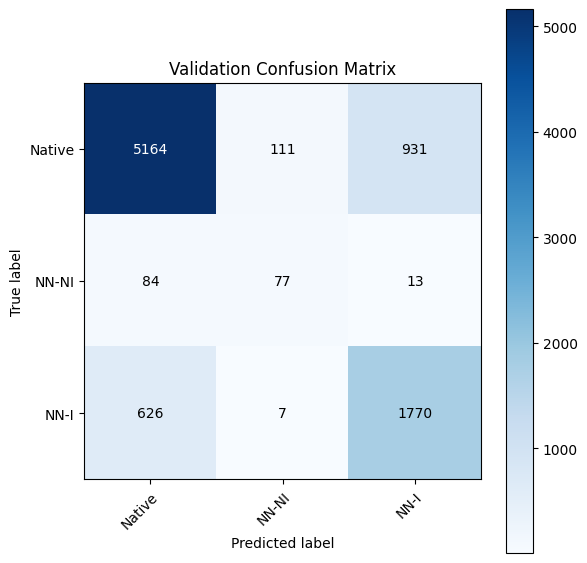


🔁 Epoch 11/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1024.40it/s]


📉 Train Loss: 0.4323 | Accuracy: 0.8035
📈 Val Loss:   0.4187 | Accuracy: 0.8058

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.89      0.87      6206
NN Non-Invasive       0.38      0.45      0.42       174
    NN Invasive       0.72      0.61      0.66      2403

       accuracy                           0.81      8783
      macro avg       0.65      0.65      0.65      8783
   weighted avg       0.80      0.81      0.80      8783



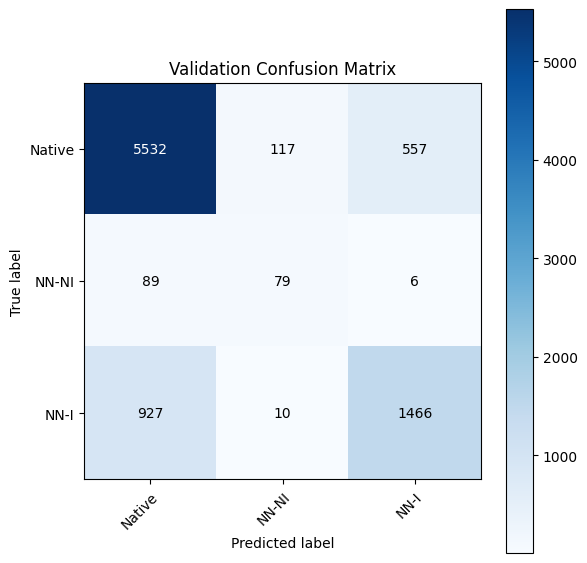


🔁 Epoch 12/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1057.45it/s]


📉 Train Loss: 0.4275 | Accuracy: 0.8053
📈 Val Loss:   0.4192 | Accuracy: 0.8010

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.84      0.86      6206
NN Non-Invasive       0.36      0.58      0.44       174
    NN Invasive       0.67      0.72      0.70      2403

       accuracy                           0.80      8783
      macro avg       0.64      0.71      0.67      8783
   weighted avg       0.81      0.80      0.81      8783



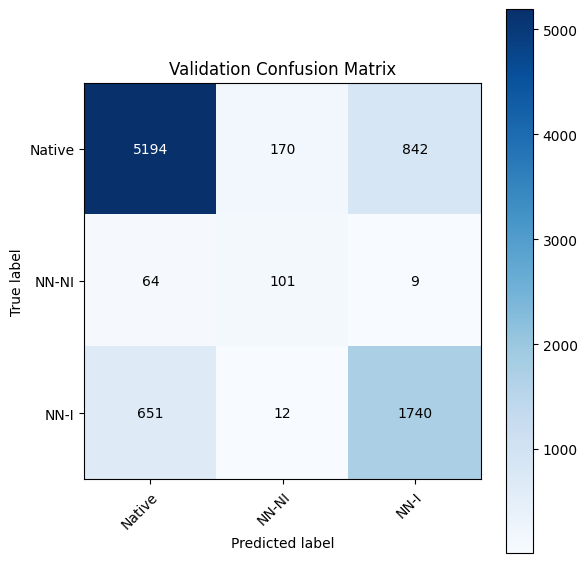


🔁 Epoch 13/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1068.50it/s]


📉 Train Loss: 0.4227 | Accuracy: 0.8083
📈 Val Loss:   0.4073 | Accuracy: 0.8099

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.87      0.87      6206
NN Non-Invasive       0.43      0.44      0.44       174
    NN Invasive       0.70      0.67      0.69      2403

       accuracy                           0.81      8783
      macro avg       0.66      0.66      0.66      8783
   weighted avg       0.81      0.81      0.81      8783



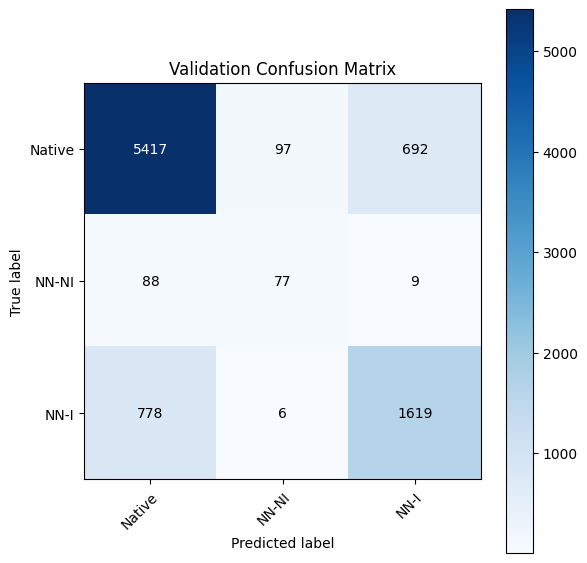


🔁 Epoch 14/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1041.07it/s]


📉 Train Loss: 0.4191 | Accuracy: 0.8101
📈 Val Loss:   0.4060 | Accuracy: 0.8109

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.87      0.87      6206
NN Non-Invasive       0.42      0.47      0.44       174
    NN Invasive       0.70      0.68      0.69      2403

       accuracy                           0.81      8783
      macro avg       0.66      0.67      0.67      8783
   weighted avg       0.81      0.81      0.81      8783



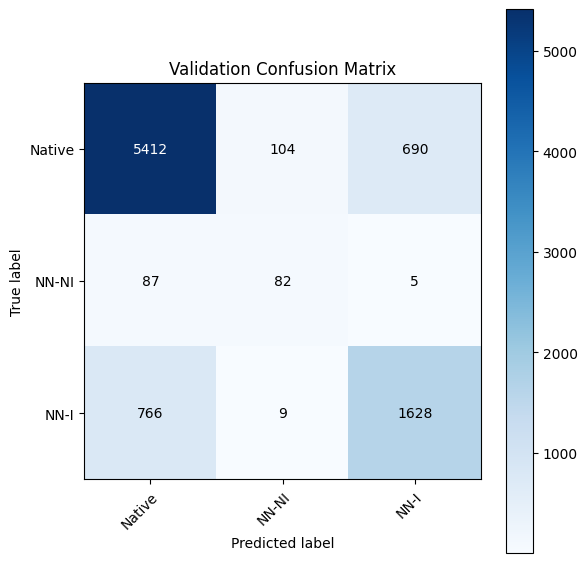


🔁 Epoch 15/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 766.17it/s]


📉 Train Loss: 0.4150 | Accuracy: 0.8126
📈 Val Loss:   0.4052 | Accuracy: 0.8088

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.86      0.87      6206
NN Non-Invasive       0.40      0.53      0.45       174
    NN Invasive       0.69      0.69      0.69      2403

       accuracy                           0.81      8783
      macro avg       0.65      0.70      0.67      8783
   weighted avg       0.81      0.81      0.81      8783



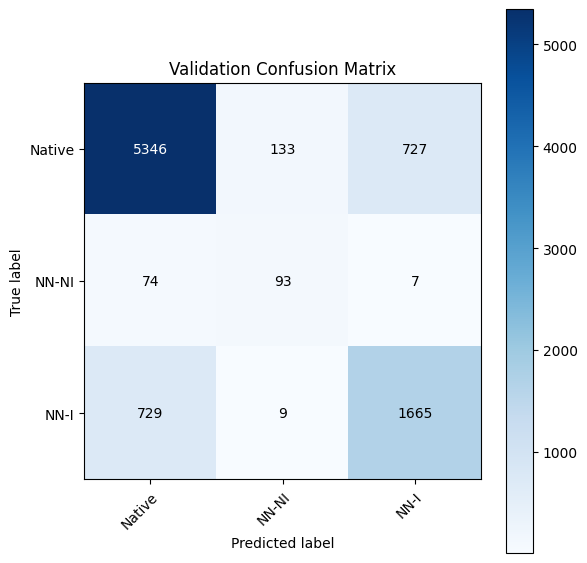


🔁 Epoch 16/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1103.95it/s]


📉 Train Loss: 0.4116 | Accuracy: 0.8135
📈 Val Loss:   0.4002 | Accuracy: 0.8134

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.86      0.87      6206
NN Non-Invasive       0.43      0.50      0.46       174
    NN Invasive       0.69      0.71      0.70      2403

       accuracy                           0.81      8783
      macro avg       0.67      0.69      0.68      8783
   weighted avg       0.82      0.81      0.81      8783



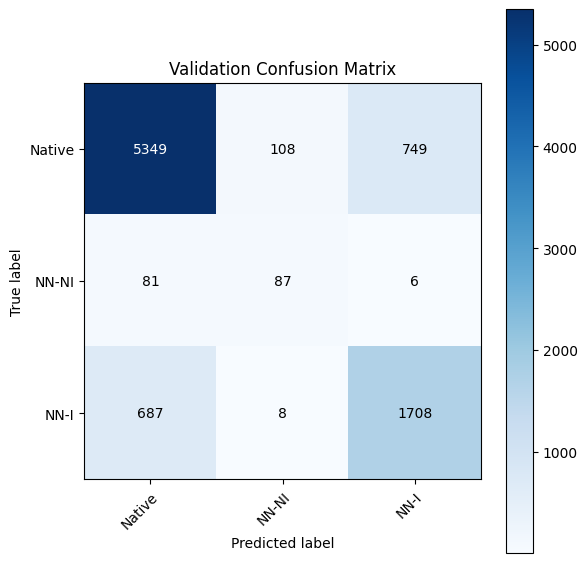


🔁 Epoch 17/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1068.78it/s]


📉 Train Loss: 0.4080 | Accuracy: 0.8156
📈 Val Loss:   0.3998 | Accuracy: 0.8116

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.86      0.87      6206
NN Non-Invasive       0.43      0.50      0.46       174
    NN Invasive       0.69      0.72      0.70      2403

       accuracy                           0.81      8783
      macro avg       0.66      0.69      0.68      8783
   weighted avg       0.82      0.81      0.81      8783



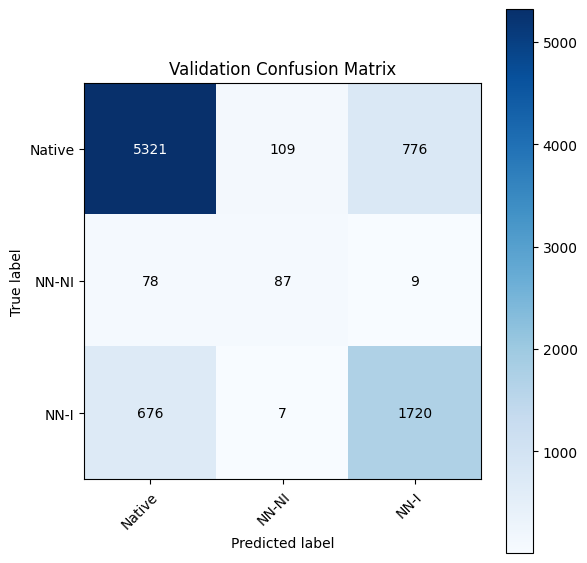


🔁 Epoch 18/10000


Evaluating: 100%|██████████| 275/275 [00:01<00:00, 240.71it/s]


📉 Train Loss: 0.4051 | Accuracy: 0.8173
📈 Val Loss:   0.4006 | Accuracy: 0.8107

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.84      0.86      6206
NN Non-Invasive       0.41      0.55      0.47       174
    NN Invasive       0.68      0.75      0.71      2403

       accuracy                           0.81      8783
      macro avg       0.66      0.71      0.68      8783
   weighted avg       0.82      0.81      0.81      8783



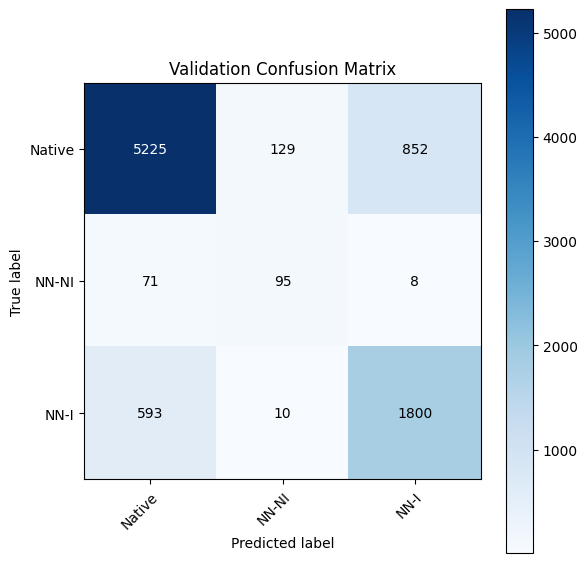


🔁 Epoch 19/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1027.98it/s]


📉 Train Loss: 0.4024 | Accuracy: 0.8184
📈 Val Loss:   0.3965 | Accuracy: 0.8130

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.85      0.87      6206
NN Non-Invasive       0.42      0.51      0.46       174
    NN Invasive       0.68      0.74      0.71      2403

       accuracy                           0.81      8783
      macro avg       0.66      0.70      0.68      8783
   weighted avg       0.82      0.81      0.82      8783



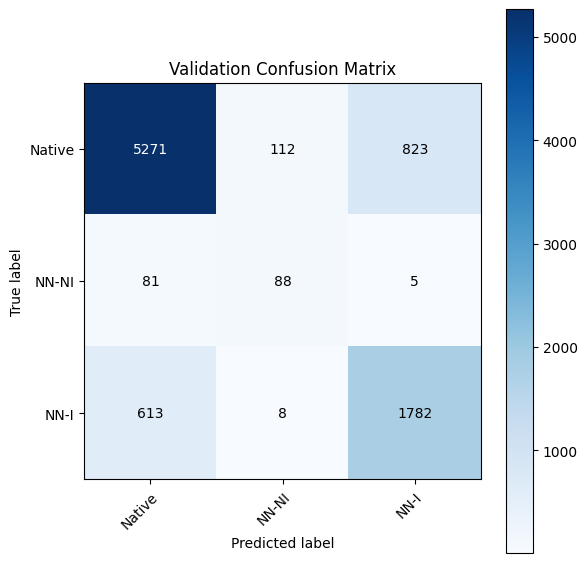


🔁 Epoch 20/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1055.85it/s]


📉 Train Loss: 0.3996 | Accuracy: 0.8200
📈 Val Loss:   0.3960 | Accuracy: 0.8158

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.86      0.87      6206
NN Non-Invasive       0.43      0.57      0.49       174
    NN Invasive       0.70      0.72      0.71      2403

       accuracy                           0.82      8783
      macro avg       0.67      0.72      0.69      8783
   weighted avg       0.82      0.82      0.82      8783



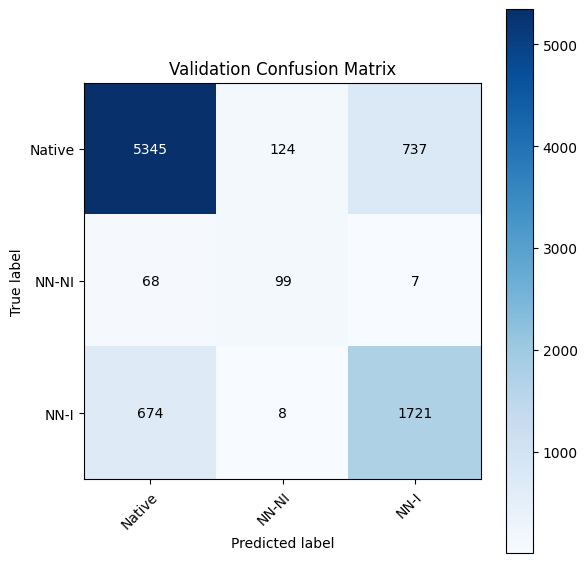


🔁 Epoch 21/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1035.99it/s]


📉 Train Loss: 0.3968 | Accuracy: 0.8213
📈 Val Loss:   0.3927 | Accuracy: 0.8179

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.89      0.87      6206
NN Non-Invasive       0.44      0.48      0.46       174
    NN Invasive       0.73      0.65      0.69      2403

       accuracy                           0.82      8783
      macro avg       0.68      0.67      0.67      8783
   weighted avg       0.81      0.82      0.82      8783



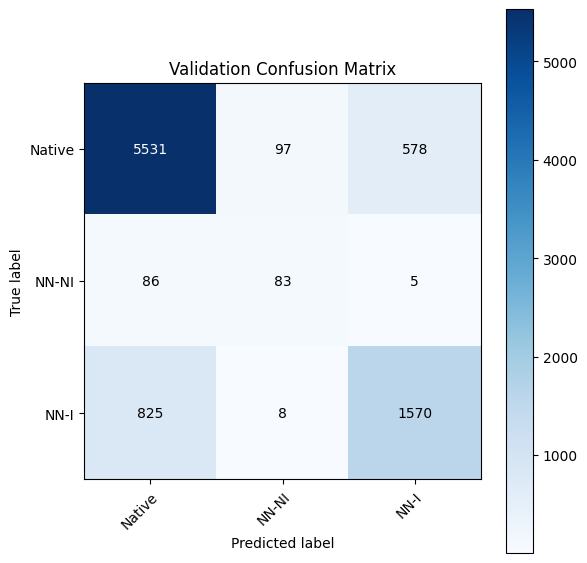


🔁 Epoch 22/10000


Evaluating: 100%|██████████| 275/275 [00:01<00:00, 221.97it/s]


📉 Train Loss: 0.3939 | Accuracy: 0.8230
📈 Val Loss:   0.3952 | Accuracy: 0.8166

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.86      0.87      6206
NN Non-Invasive       0.40      0.59      0.47       174
    NN Invasive       0.70      0.72      0.71      2403

       accuracy                           0.82      8783
      macro avg       0.66      0.72      0.69      8783
   weighted avg       0.82      0.82      0.82      8783



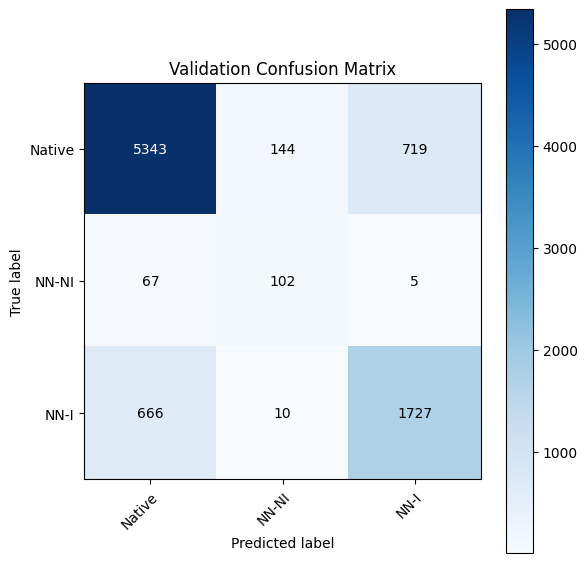


🔁 Epoch 23/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1037.06it/s]


📉 Train Loss: 0.3918 | Accuracy: 0.8225
📈 Val Loss:   0.3938 | Accuracy: 0.8190

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.88      0.87      6206
NN Non-Invasive       0.43      0.59      0.50       174
    NN Invasive       0.72      0.68      0.70      2403

       accuracy                           0.82      8783
      macro avg       0.67      0.72      0.69      8783
   weighted avg       0.82      0.82      0.82      8783



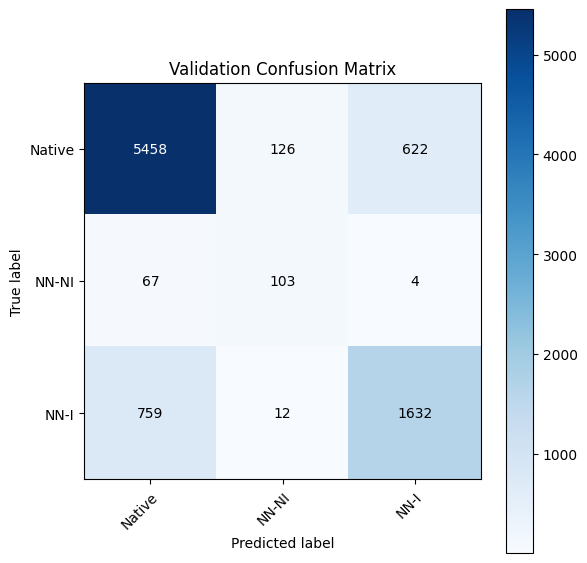


🔁 Epoch 24/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1046.60it/s]


📉 Train Loss: 0.3899 | Accuracy: 0.8243
📈 Val Loss:   0.3921 | Accuracy: 0.8177

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.88      0.87      6206
NN Non-Invasive       0.41      0.54      0.47       174
    NN Invasive       0.73      0.67      0.70      2403

       accuracy                           0.82      8783
      macro avg       0.67      0.70      0.68      8783
   weighted avg       0.82      0.82      0.82      8783



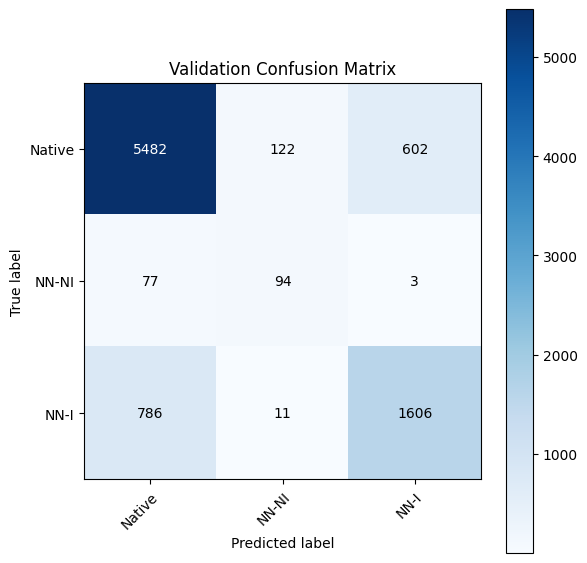


🔁 Epoch 25/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1013.05it/s]


📉 Train Loss: 0.3871 | Accuracy: 0.8245
📈 Val Loss:   0.3869 | Accuracy: 0.8189

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.87      0.87      6206
NN Non-Invasive       0.43      0.53      0.48       174
    NN Invasive       0.71      0.71      0.71      2403

       accuracy                           0.82      8783
      macro avg       0.67      0.70      0.69      8783
   weighted avg       0.82      0.82      0.82      8783



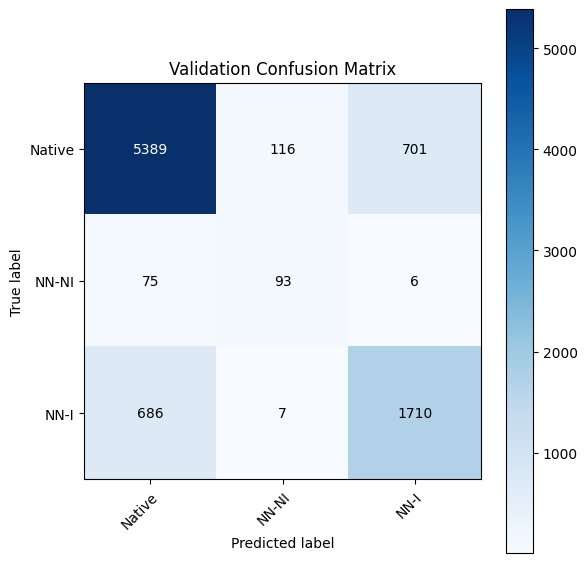


🔁 Epoch 26/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 725.48it/s]


📉 Train Loss: 0.3849 | Accuracy: 0.8267
📈 Val Loss:   0.3883 | Accuracy: 0.8202

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.86      0.87      6206
NN Non-Invasive       0.41      0.57      0.47       174
    NN Invasive       0.71      0.73      0.72      2403

       accuracy                           0.82      8783
      macro avg       0.67      0.72      0.69      8783
   weighted avg       0.83      0.82      0.82      8783



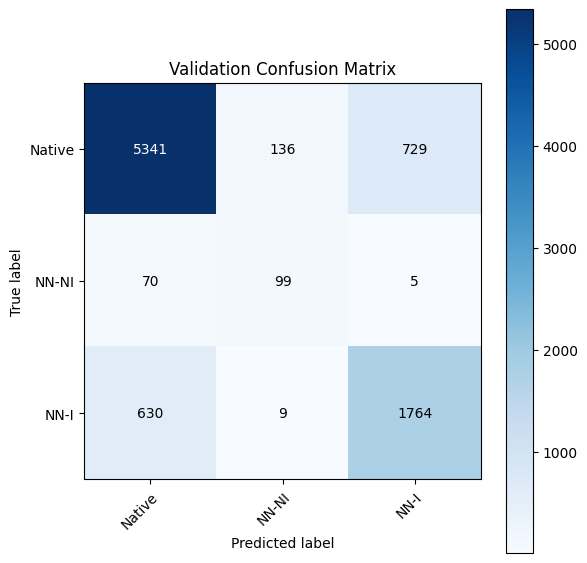


🔁 Epoch 27/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1052.74it/s]


📉 Train Loss: 0.3827 | Accuracy: 0.8277
📈 Val Loss:   0.3839 | Accuracy: 0.8247

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.87      0.88      6206
NN Non-Invasive       0.46      0.53      0.49       174
    NN Invasive       0.71      0.73      0.72      2403

       accuracy                           0.82      8783
      macro avg       0.69      0.71      0.70      8783
   weighted avg       0.83      0.82      0.83      8783



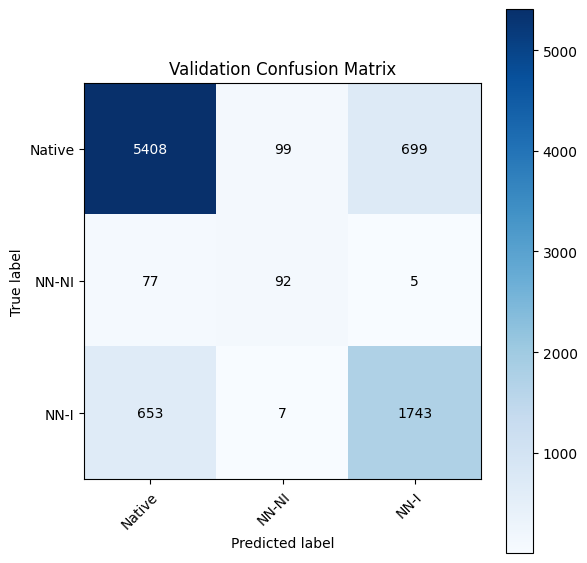


🔁 Epoch 28/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 956.47it/s]


📉 Train Loss: 0.3803 | Accuracy: 0.8289
📈 Val Loss:   0.3859 | Accuracy: 0.8212

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.86      0.87      6206
NN Non-Invasive       0.43      0.57      0.50       174
    NN Invasive       0.70      0.73      0.72      2403

       accuracy                           0.82      8783
      macro avg       0.67      0.72      0.70      8783
   weighted avg       0.83      0.82      0.82      8783



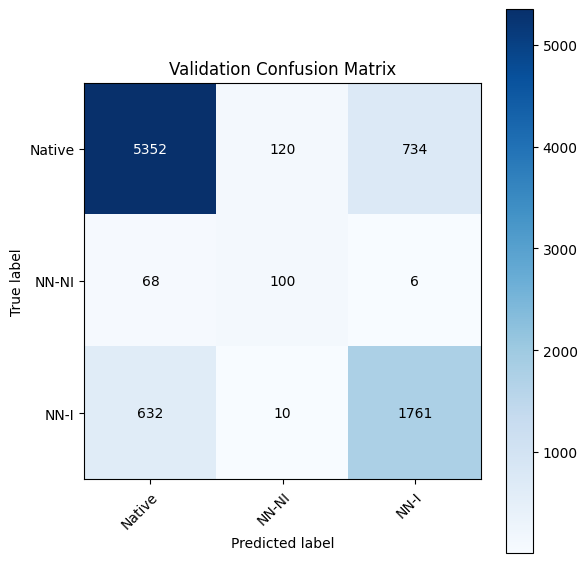


🔁 Epoch 29/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1011.08it/s]


📉 Train Loss: 0.3784 | Accuracy: 0.8296
📈 Val Loss:   0.3827 | Accuracy: 0.8216

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.85      0.87      6206
NN Non-Invasive       0.46      0.51      0.49       174
    NN Invasive       0.69      0.77      0.73      2403

       accuracy                           0.82      8783
      macro avg       0.68      0.71      0.69      8783
   weighted avg       0.83      0.82      0.82      8783



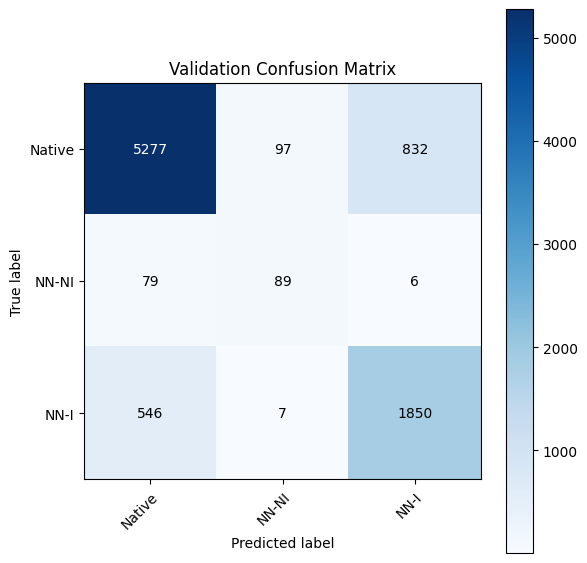


🔁 Epoch 30/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 769.28it/s]


📉 Train Loss: 0.3768 | Accuracy: 0.8307
📈 Val Loss:   0.3839 | Accuracy: 0.8260

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.91      0.88      6206
NN Non-Invasive       0.51      0.49      0.50       174
    NN Invasive       0.75      0.64      0.69      2403

       accuracy                           0.83      8783
      macro avg       0.71      0.68      0.69      8783
   weighted avg       0.82      0.83      0.82      8783



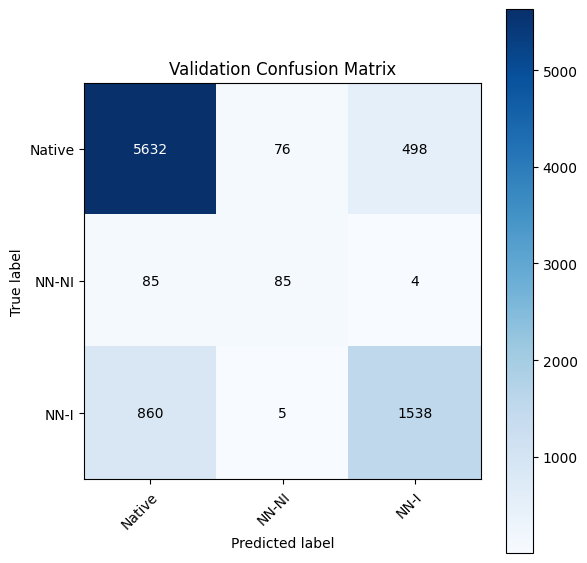


🔁 Epoch 31/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1030.64it/s]


📉 Train Loss: 0.3750 | Accuracy: 0.8322
📈 Val Loss:   0.3799 | Accuracy: 0.8251

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.87      0.88      6206
NN Non-Invasive       0.45      0.53      0.49       174
    NN Invasive       0.72      0.72      0.72      2403

       accuracy                           0.83      8783
      macro avg       0.68      0.71      0.69      8783
   weighted avg       0.83      0.83      0.83      8783



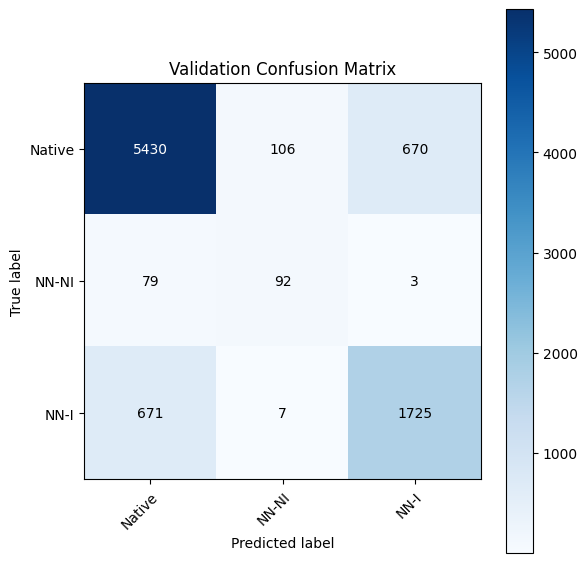


🔁 Epoch 32/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1012.05it/s]


📉 Train Loss: 0.3727 | Accuracy: 0.8332
📈 Val Loss:   0.3785 | Accuracy: 0.8267

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.88      0.88      6206
NN Non-Invasive       0.45      0.53      0.49       174
    NN Invasive       0.72      0.72      0.72      2403

       accuracy                           0.83      8783
      macro avg       0.68      0.71      0.70      8783
   weighted avg       0.83      0.83      0.83      8783



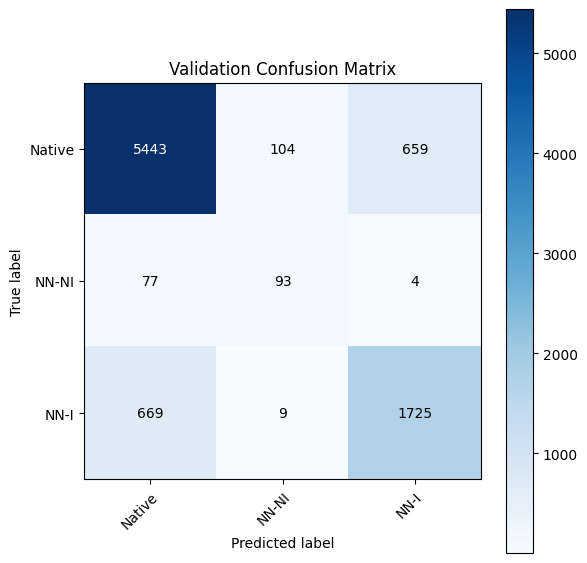


🔁 Epoch 33/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1017.34it/s]


📉 Train Loss: 0.3715 | Accuracy: 0.8349
📈 Val Loss:   0.3747 | Accuracy: 0.8281

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.88      0.88      6206
NN Non-Invasive       0.50      0.47      0.49       174
    NN Invasive       0.72      0.72      0.72      2403

       accuracy                           0.83      8783
      macro avg       0.70      0.69      0.70      8783
   weighted avg       0.83      0.83      0.83      8783



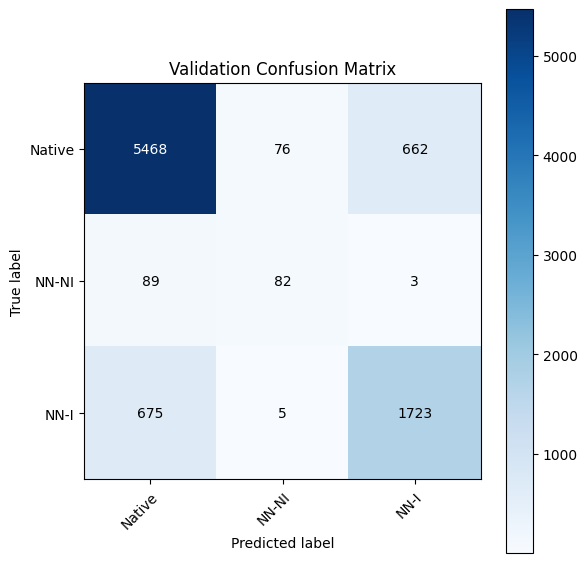


🔁 Epoch 34/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 933.50it/s]


📉 Train Loss: 0.3690 | Accuracy: 0.8358
📈 Val Loss:   0.3770 | Accuracy: 0.8243

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.86      0.88      6206
NN Non-Invasive       0.45      0.55      0.49       174
    NN Invasive       0.71      0.74      0.72      2403

       accuracy                           0.82      8783
      macro avg       0.68      0.72      0.70      8783
   weighted avg       0.83      0.82      0.83      8783



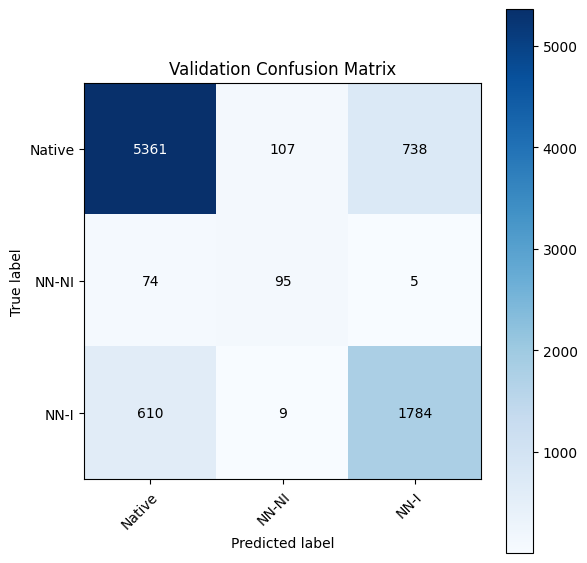


🔁 Epoch 35/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 765.34it/s]


📉 Train Loss: 0.3674 | Accuracy: 0.8366
📈 Val Loss:   0.3810 | Accuracy: 0.8209

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.85      0.87      6206
NN Non-Invasive       0.43      0.62      0.51       174
    NN Invasive       0.69      0.77      0.73      2403

       accuracy                           0.82      8783
      macro avg       0.67      0.75      0.70      8783
   weighted avg       0.83      0.82      0.82      8783



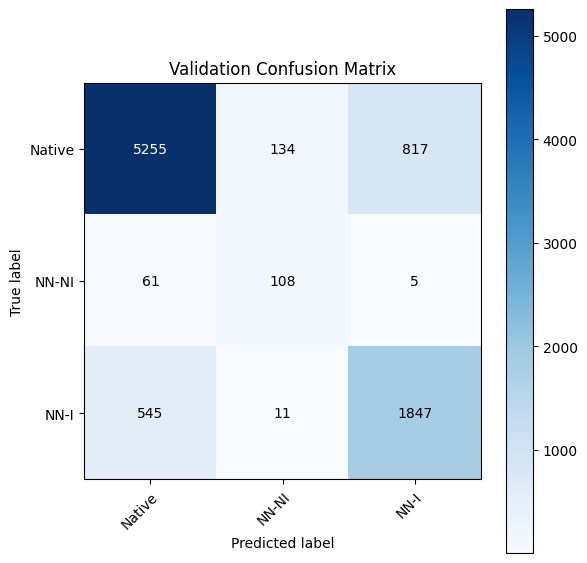


🔁 Epoch 36/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 942.69it/s]


📉 Train Loss: 0.3661 | Accuracy: 0.8362
📈 Val Loss:   0.3766 | Accuracy: 0.8268

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.87      0.88      6206
NN Non-Invasive       0.45      0.59      0.51       174
    NN Invasive       0.71      0.74      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.68      0.73      0.70      8783
   weighted avg       0.83      0.83      0.83      8783



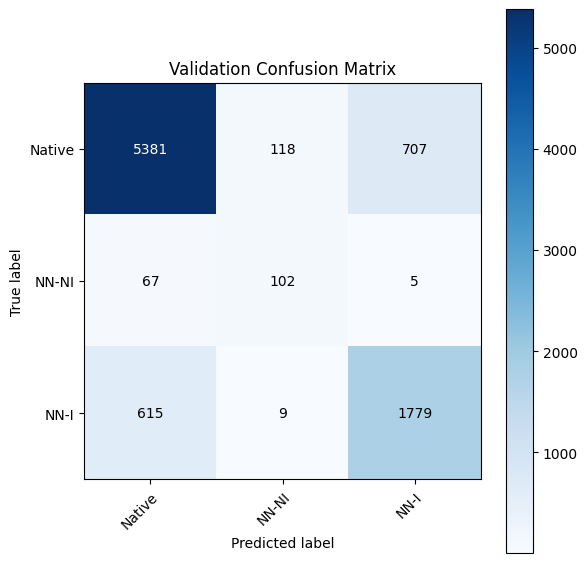


🔁 Epoch 37/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 955.34it/s]


📉 Train Loss: 0.3641 | Accuracy: 0.8371
📈 Val Loss:   0.3791 | Accuracy: 0.8232

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.85      0.87      6206
NN Non-Invasive       0.42      0.64      0.51       174
    NN Invasive       0.70      0.77      0.73      2403

       accuracy                           0.82      8783
      macro avg       0.67      0.75      0.70      8783
   weighted avg       0.83      0.82      0.83      8783



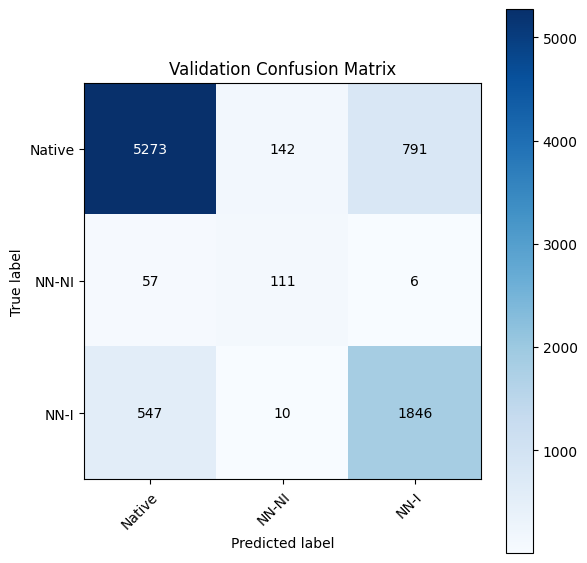


🔁 Epoch 38/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 937.30it/s]


📉 Train Loss: 0.3627 | Accuracy: 0.8378
📈 Val Loss:   0.3764 | Accuracy: 0.8269

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.86      0.88      6206
NN Non-Invasive       0.44      0.64      0.52       174
    NN Invasive       0.71      0.76      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.68      0.75      0.71      8783
   weighted avg       0.83      0.83      0.83      8783



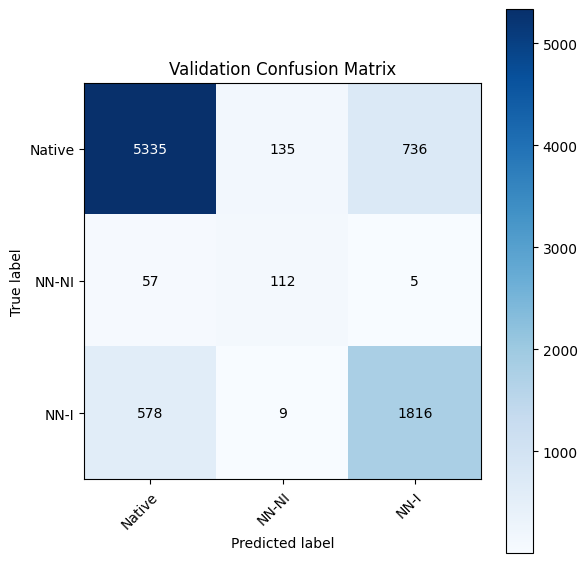


🔁 Epoch 39/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 810.06it/s]


📉 Train Loss: 0.3610 | Accuracy: 0.8379
📈 Val Loss:   0.3722 | Accuracy: 0.8318

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.88      0.88      6206
NN Non-Invasive       0.48      0.55      0.51       174
    NN Invasive       0.73      0.72      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.70      0.72      0.71      8783
   weighted avg       0.83      0.83      0.83      8783



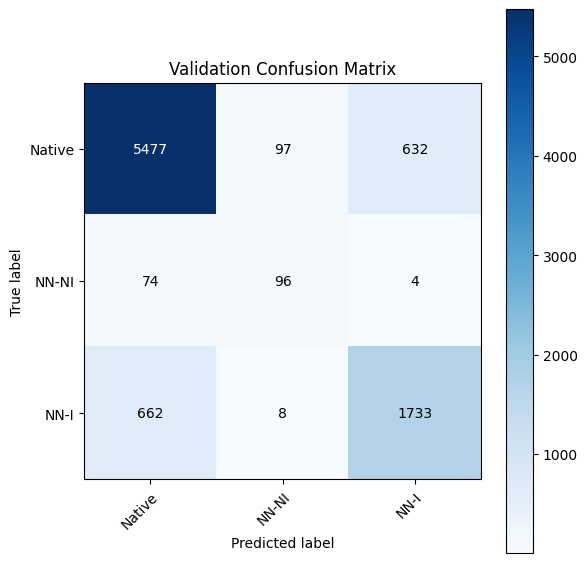


🔁 Epoch 40/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1000.49it/s]


📉 Train Loss: 0.3596 | Accuracy: 0.8408
📈 Val Loss:   0.3723 | Accuracy: 0.8322

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.88      6206
NN Non-Invasive       0.47      0.56      0.51       174
    NN Invasive       0.74      0.70      0.72      2403

       accuracy                           0.83      8783
      macro avg       0.70      0.72      0.71      8783
   weighted avg       0.83      0.83      0.83      8783



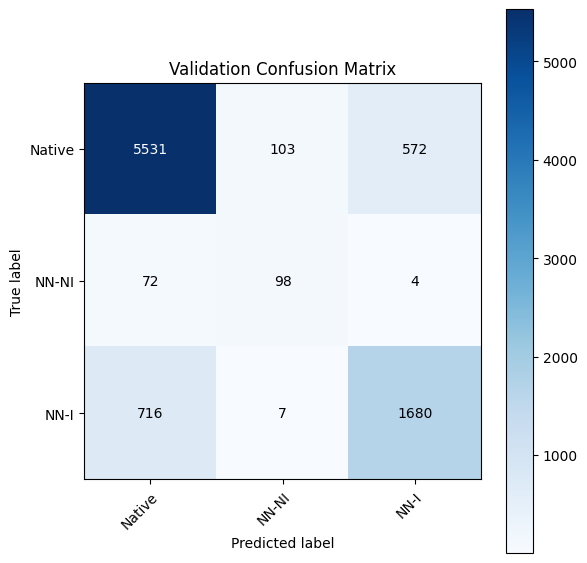


🔁 Epoch 41/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1012.64it/s]


📉 Train Loss: 0.3576 | Accuracy: 0.8426
📈 Val Loss:   0.3723 | Accuracy: 0.8298

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.87      0.88      6206
NN Non-Invasive       0.47      0.60      0.53       174
    NN Invasive       0.72      0.74      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.69      0.74      0.71      8783
   weighted avg       0.83      0.83      0.83      8783



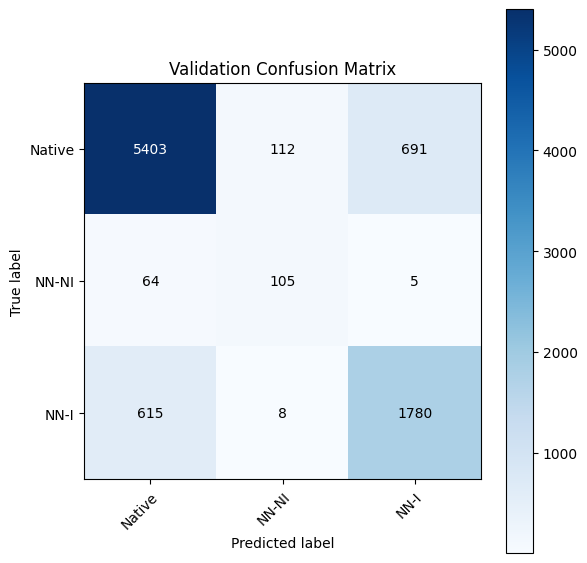


🔁 Epoch 42/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 933.74it/s]


📉 Train Loss: 0.3566 | Accuracy: 0.8421
📈 Val Loss:   0.3733 | Accuracy: 0.8281

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.86      0.88      6206
NN Non-Invasive       0.46      0.63      0.53       174
    NN Invasive       0.71      0.75      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.69      0.75      0.71      8783
   weighted avg       0.83      0.83      0.83      8783



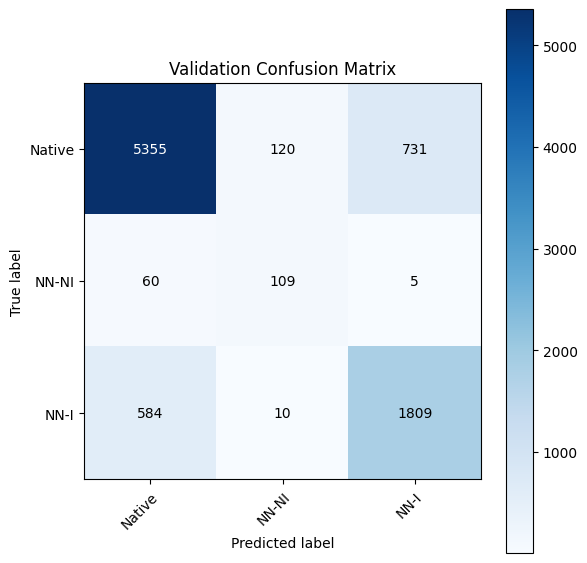


🔁 Epoch 43/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 909.55it/s]


📉 Train Loss: 0.3549 | Accuracy: 0.8425
📈 Val Loss:   0.3801 | Accuracy: 0.8189

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.83      0.87      6206
NN Non-Invasive       0.45      0.63      0.52       174
    NN Invasive       0.67      0.81      0.73      2403

       accuracy                           0.82      8783
      macro avg       0.68      0.76      0.71      8783
   weighted avg       0.84      0.82      0.82      8783



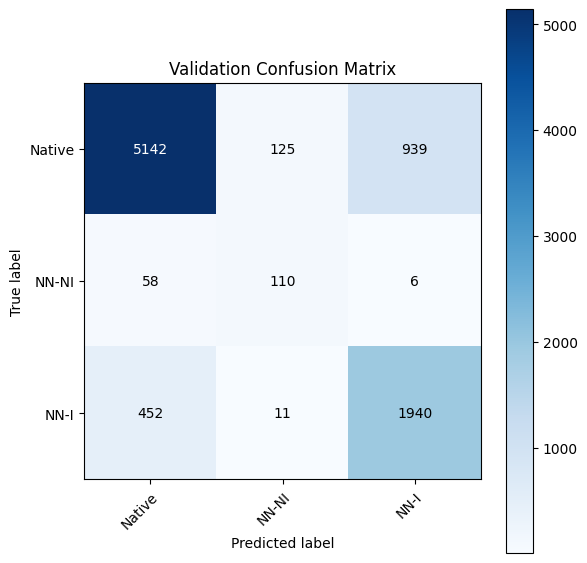


🔁 Epoch 44/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 693.45it/s]


📉 Train Loss: 0.3539 | Accuracy: 0.8414
📈 Val Loss:   0.3721 | Accuracy: 0.8274

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.86      0.88      6206
NN Non-Invasive       0.45      0.61      0.52       174
    NN Invasive       0.71      0.76      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.68      0.74      0.71      8783
   weighted avg       0.83      0.83      0.83      8783



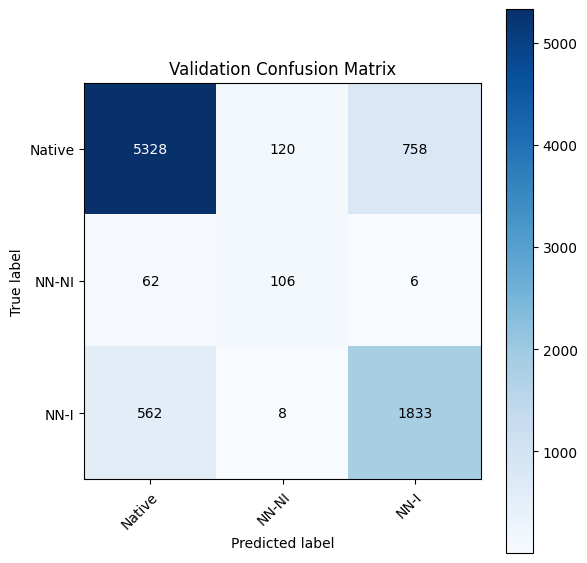


🔁 Epoch 45/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 924.41it/s]


📉 Train Loss: 0.3520 | Accuracy: 0.8439
📈 Val Loss:   0.3685 | Accuracy: 0.8307

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.86      0.88      6206
NN Non-Invasive       0.50      0.59      0.54       174
    NN Invasive       0.71      0.76      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.70      0.74      0.72      8783
   weighted avg       0.84      0.83      0.83      8783



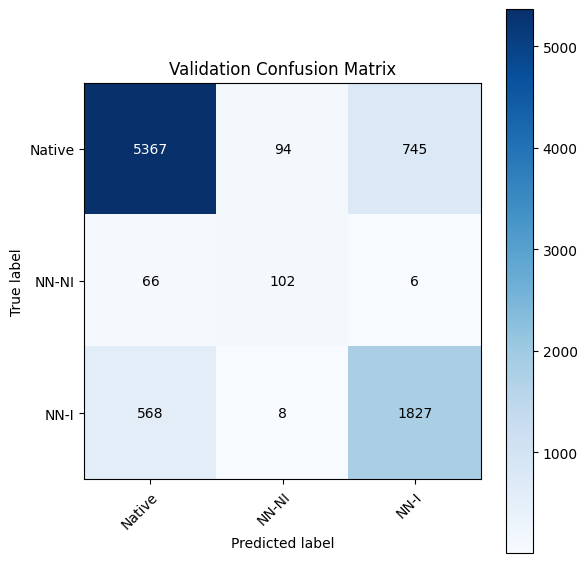


🔁 Epoch 46/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 888.43it/s]


📉 Train Loss: 0.3504 | Accuracy: 0.8456
📈 Val Loss:   0.3687 | Accuracy: 0.8316

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.87      0.88      6206
NN Non-Invasive       0.47      0.60      0.53       174
    NN Invasive       0.72      0.75      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.69      0.74      0.71      8783
   weighted avg       0.84      0.83      0.83      8783



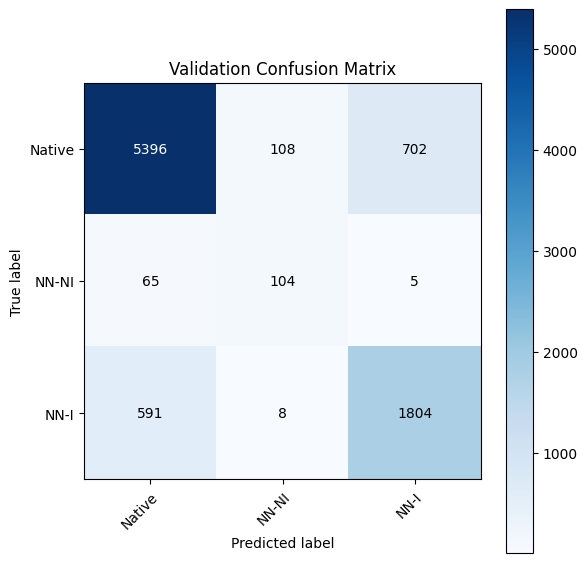


🔁 Epoch 47/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 874.44it/s]


📉 Train Loss: 0.3491 | Accuracy: 0.8457
📈 Val Loss:   0.3698 | Accuracy: 0.8350

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.90      0.89      6206
NN Non-Invasive       0.48      0.60      0.53       174
    NN Invasive       0.75      0.69      0.72      2403

       accuracy                           0.84      8783
      macro avg       0.70      0.73      0.71      8783
   weighted avg       0.83      0.84      0.83      8783



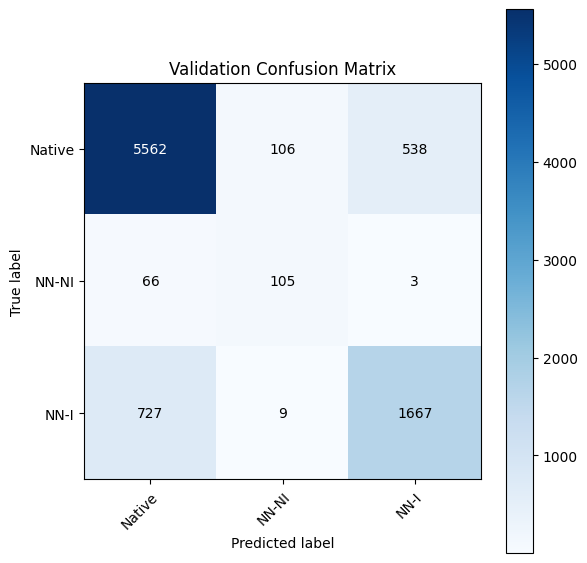


🔁 Epoch 48/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 788.57it/s]


📉 Train Loss: 0.3479 | Accuracy: 0.8463
📈 Val Loss:   0.3685 | Accuracy: 0.8330

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.88      0.88      6206
NN Non-Invasive       0.47      0.64      0.54       174
    NN Invasive       0.73      0.73      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.70      0.75      0.72      8783
   weighted avg       0.84      0.83      0.83      8783



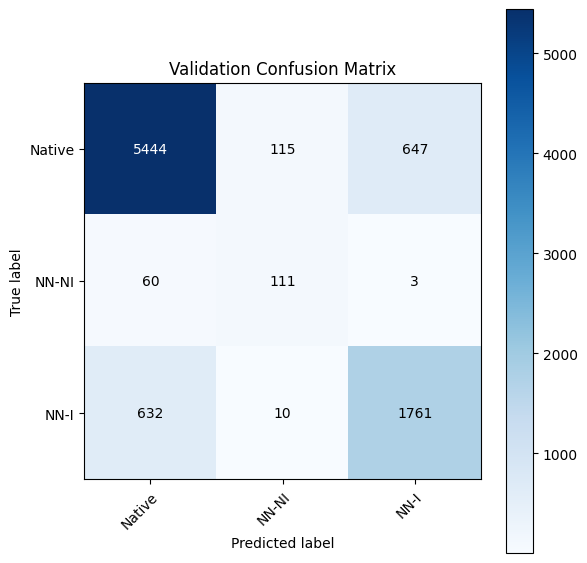


🔁 Epoch 49/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 949.29it/s]


📉 Train Loss: 0.3465 | Accuracy: 0.8478
📈 Val Loss:   0.3671 | Accuracy: 0.8345

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.88      0.88      6206
NN Non-Invasive       0.47      0.61      0.53       174
    NN Invasive       0.74      0.73      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.70      0.74      0.72      8783
   weighted avg       0.84      0.83      0.84      8783



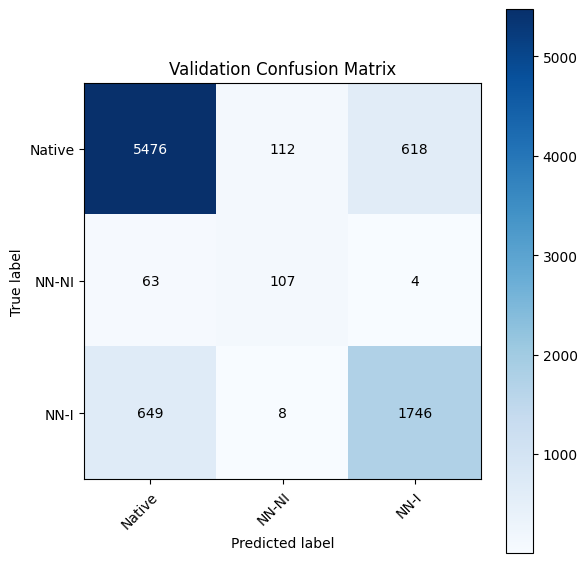


🔁 Epoch 50/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 988.71it/s]


📉 Train Loss: 0.3456 | Accuracy: 0.8475
📈 Val Loss:   0.3639 | Accuracy: 0.8343

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.88      0.88      6206
NN Non-Invasive       0.51      0.57      0.54       174
    NN Invasive       0.72      0.74      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.71      0.73      0.72      8783
   weighted avg       0.84      0.83      0.84      8783



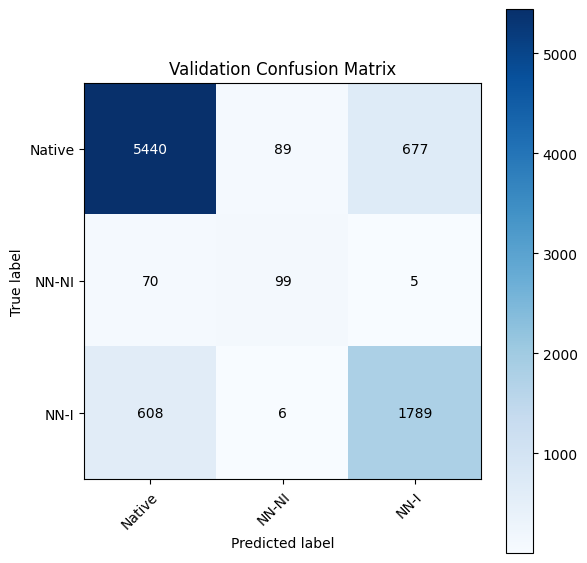


🔁 Epoch 51/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 996.87it/s] 


📉 Train Loss: 0.3443 | Accuracy: 0.8478
📈 Val Loss:   0.3644 | Accuracy: 0.8345

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.88      0.88      6206
NN Non-Invasive       0.50      0.59      0.54       174
    NN Invasive       0.73      0.73      0.73      2403

       accuracy                           0.83      8783
      macro avg       0.71      0.73      0.72      8783
   weighted avg       0.84      0.83      0.83      8783



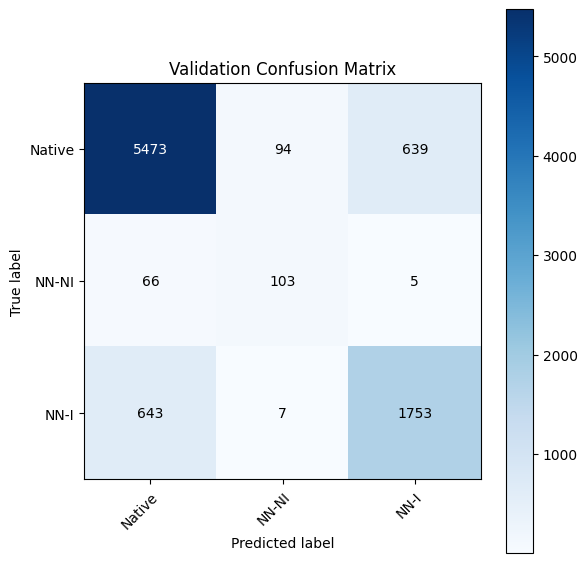


🔁 Epoch 52/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 966.41it/s]


📉 Train Loss: 0.3428 | Accuracy: 0.8491
📈 Val Loss:   0.3646 | Accuracy: 0.8317

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.86      0.88      6206
NN Non-Invasive       0.53      0.57      0.55       174
    NN Invasive       0.70      0.78      0.74      2403

       accuracy                           0.83      8783
      macro avg       0.71      0.74      0.72      8783
   weighted avg       0.84      0.83      0.83      8783



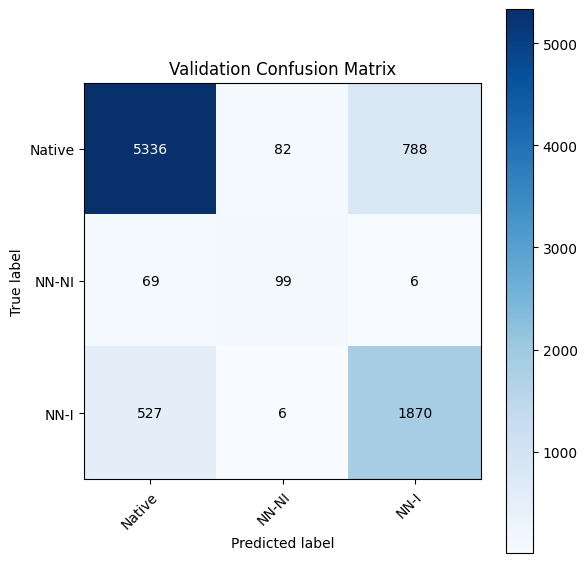


🔁 Epoch 53/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 797.30it/s]


📉 Train Loss: 0.3418 | Accuracy: 0.8496
📈 Val Loss:   0.3670 | Accuracy: 0.8371

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.89      6206
NN Non-Invasive       0.49      0.64      0.55       174
    NN Invasive       0.75      0.71      0.73      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.75      0.72      8783
   weighted avg       0.84      0.84      0.84      8783



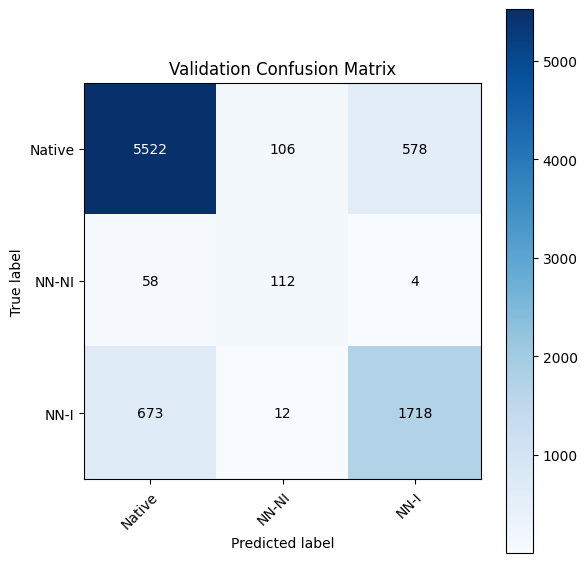


🔁 Epoch 54/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 972.40it/s]


📉 Train Loss: 0.3407 | Accuracy: 0.8494
📈 Val Loss:   0.3732 | Accuracy: 0.8223

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.83      0.87      6206
NN Non-Invasive       0.49      0.64      0.56       174
    NN Invasive       0.67      0.82      0.74      2403

       accuracy                           0.82      8783
      macro avg       0.69      0.76      0.72      8783
   weighted avg       0.84      0.82      0.83      8783



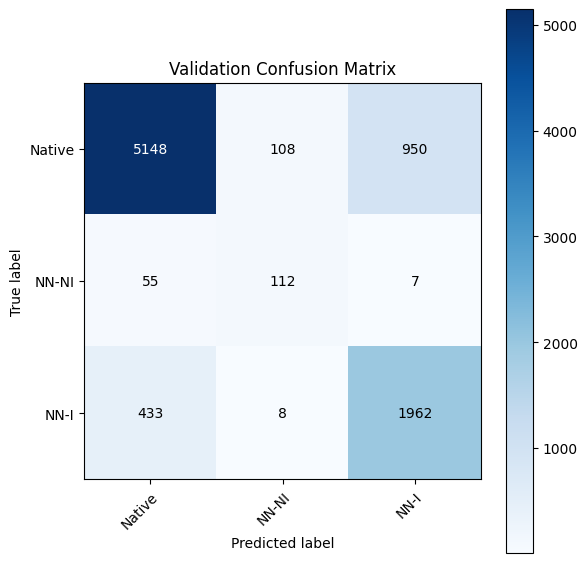


🔁 Epoch 55/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 981.72it/s]


📉 Train Loss: 0.3393 | Accuracy: 0.8509
📈 Val Loss:   0.3644 | Accuracy: 0.8384

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.90      0.89      6206
NN Non-Invasive       0.50      0.61      0.55       174
    NN Invasive       0.76      0.70      0.73      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.74      0.72      8783
   weighted avg       0.84      0.84      0.84      8783



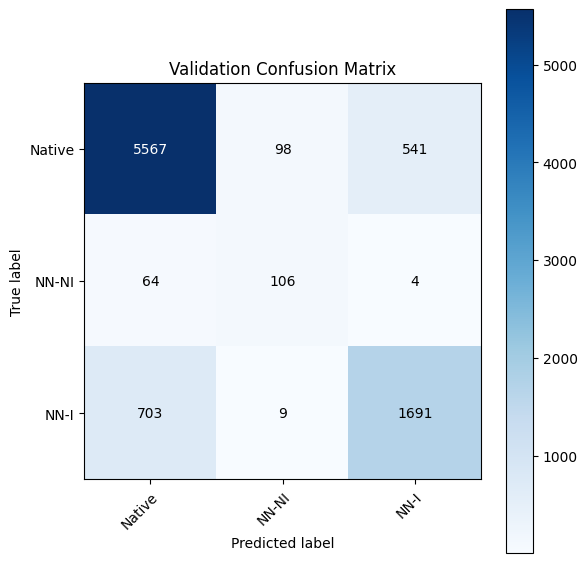


🔁 Epoch 56/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 920.70it/s]


📉 Train Loss: 0.3380 | Accuracy: 0.8514
📈 Val Loss:   0.3605 | Accuracy: 0.8367

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.87      0.88      6206
NN Non-Invasive       0.53      0.59      0.56       174
    NN Invasive       0.72      0.76      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.74      0.73      8783
   weighted avg       0.84      0.84      0.84      8783



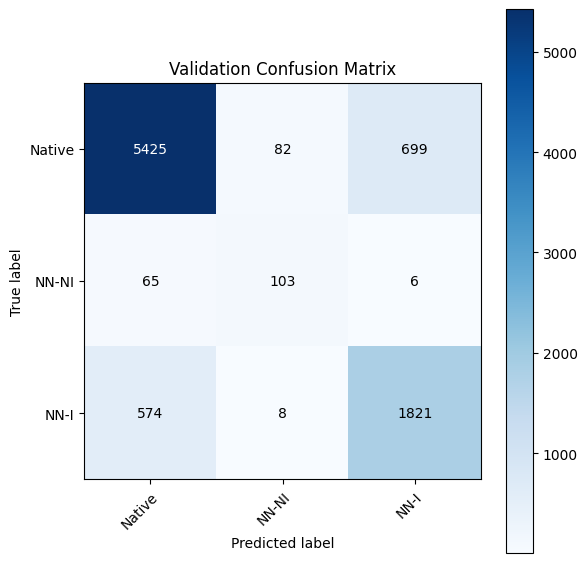


🔁 Epoch 57/10000


Evaluating: 100%|██████████| 275/275 [00:01<00:00, 140.76it/s]


📉 Train Loss: 0.3368 | Accuracy: 0.8525
📈 Val Loss:   0.3659 | Accuracy: 0.8376

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.89      6206
NN Non-Invasive       0.48      0.68      0.56       174
    NN Invasive       0.75      0.71      0.73      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.76      0.73      8783
   weighted avg       0.84      0.84      0.84      8783



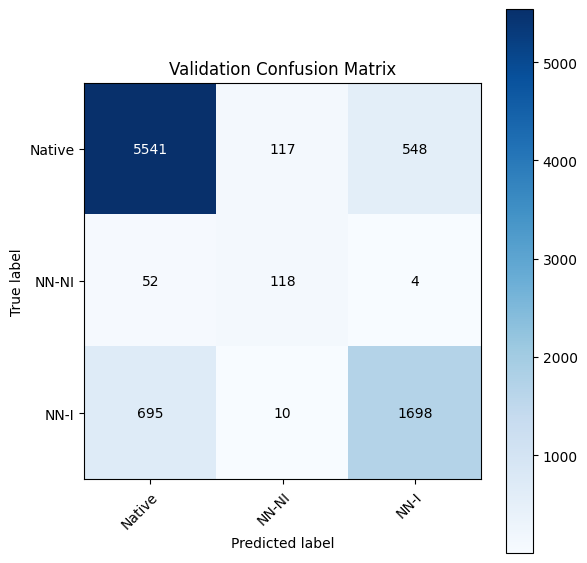


🔁 Epoch 58/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 929.64it/s]


📉 Train Loss: 0.3358 | Accuracy: 0.8515
📈 Val Loss:   0.3655 | Accuracy: 0.8316

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.86      0.88      6206
NN Non-Invasive       0.48      0.68      0.56       174
    NN Invasive       0.71      0.77      0.74      2403

       accuracy                           0.83      8783
      macro avg       0.70      0.77      0.73      8783
   weighted avg       0.84      0.83      0.83      8783



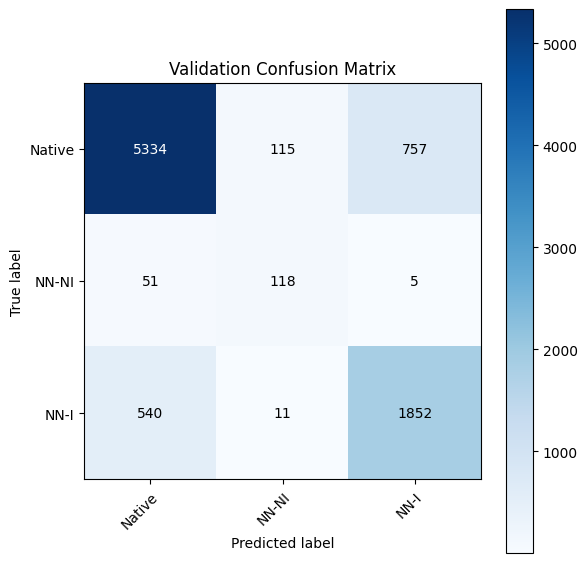


🔁 Epoch 59/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 958.58it/s]


📉 Train Loss: 0.3347 | Accuracy: 0.8526
📈 Val Loss:   0.3623 | Accuracy: 0.8362

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.88      6206
NN Non-Invasive       0.51      0.67      0.58       174
    NN Invasive       0.72      0.75      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.77      0.73      8783
   weighted avg       0.84      0.84      0.84      8783



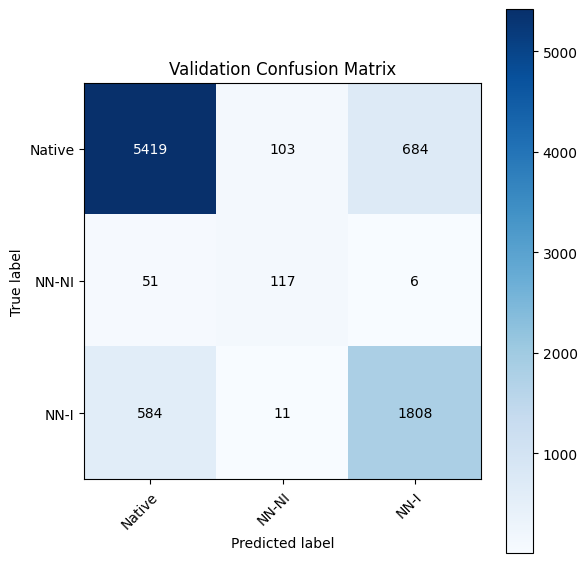


🔁 Epoch 60/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 909.24it/s]


📉 Train Loss: 0.3333 | Accuracy: 0.8536
📈 Val Loss:   0.3652 | Accuracy: 0.8388

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.89      6206
NN Non-Invasive       0.49      0.70      0.58       174
    NN Invasive       0.76      0.71      0.73      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.77      0.73      8783
   weighted avg       0.84      0.84      0.84      8783



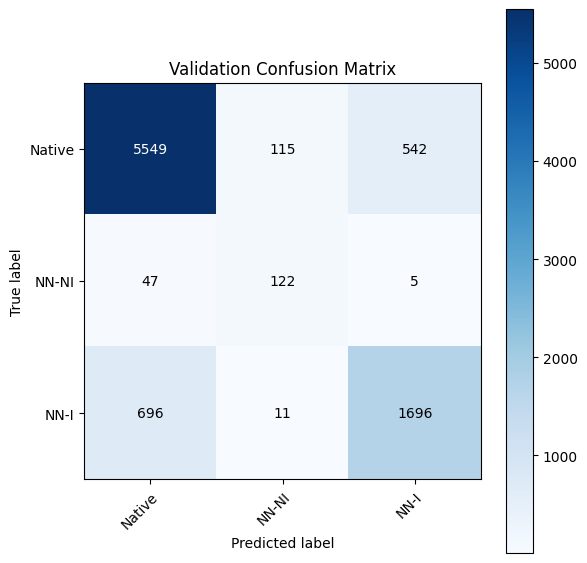


🔁 Epoch 61/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 770.06it/s]


📉 Train Loss: 0.3321 | Accuracy: 0.8547
📈 Val Loss:   0.3615 | Accuracy: 0.8395

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.88      0.89      6206
NN Non-Invasive       0.52      0.67      0.58       174
    NN Invasive       0.74      0.74      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.76      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



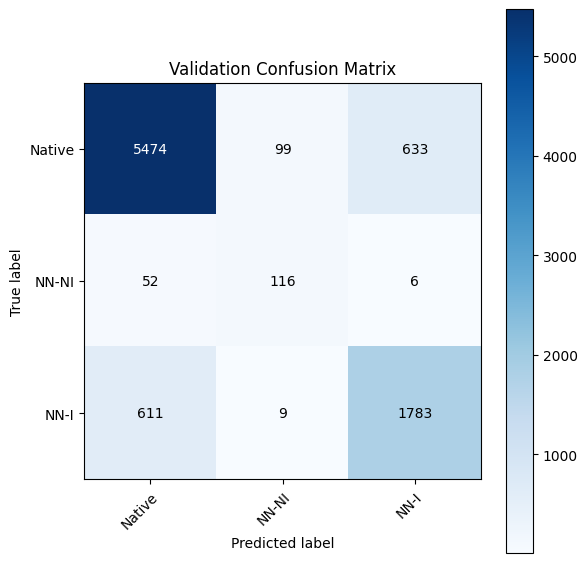


🔁 Epoch 62/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 927.28it/s]


📉 Train Loss: 0.3307 | Accuracy: 0.8548
📈 Val Loss:   0.3603 | Accuracy: 0.8405

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.90      0.89      6206
NN Non-Invasive       0.54      0.64      0.58       174
    NN Invasive       0.75      0.71      0.73      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.75      0.73      8783
   weighted avg       0.84      0.84      0.84      8783



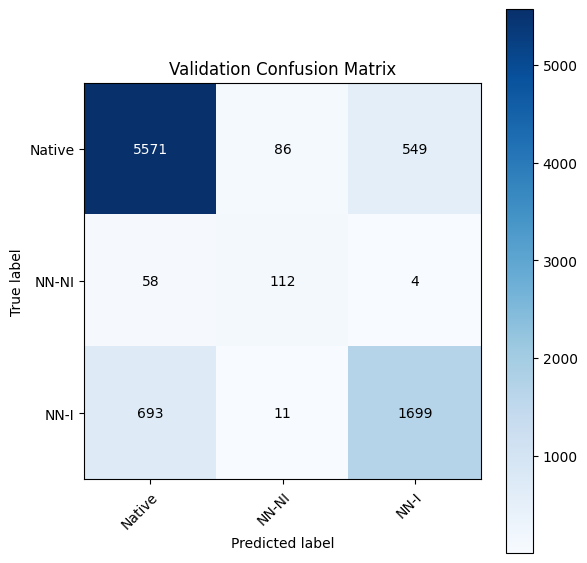


🔁 Epoch 63/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 950.90it/s]


📉 Train Loss: 0.3302 | Accuracy: 0.8551
📈 Val Loss:   0.3589 | Accuracy: 0.8392

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.88      0.89      6206
NN Non-Invasive       0.53      0.65      0.58       174
    NN Invasive       0.74      0.74      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.76      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



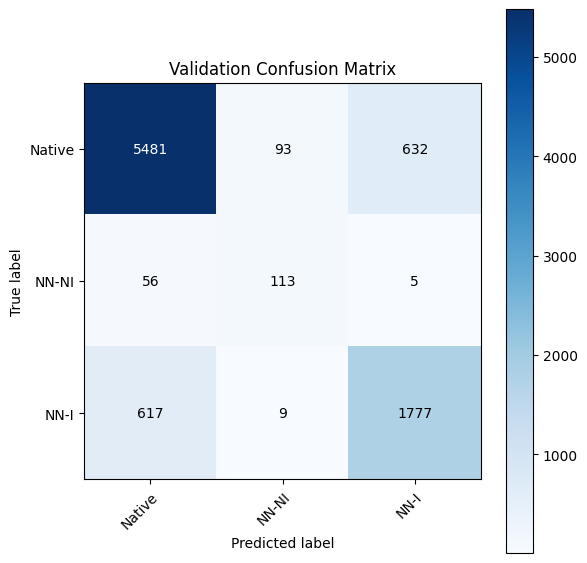


🔁 Epoch 64/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 939.70it/s]


📉 Train Loss: 0.3291 | Accuracy: 0.8564
📈 Val Loss:   0.3575 | Accuracy: 0.8399

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.55      0.61      0.58       174
    NN Invasive       0.74      0.74      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.74      0.73      8783
   weighted avg       0.84      0.84      0.84      8783



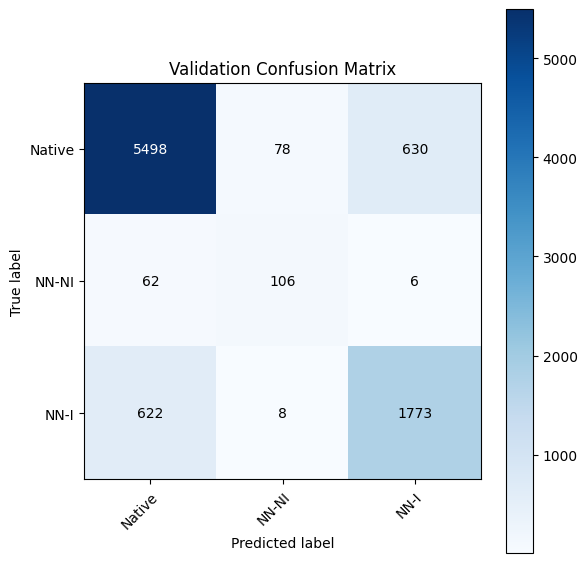


🔁 Epoch 65/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 885.73it/s]


📉 Train Loss: 0.3279 | Accuracy: 0.8560
📈 Val Loss:   0.3610 | Accuracy: 0.8350

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.86      0.88      6206
NN Non-Invasive       0.51      0.68      0.58       174
    NN Invasive       0.71      0.77      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.77      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



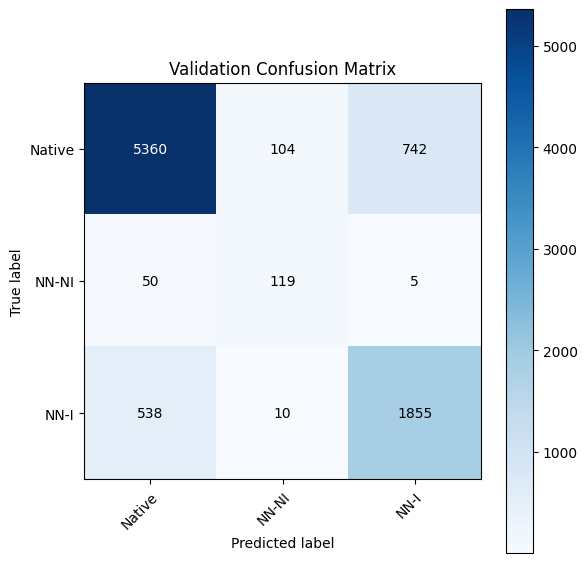


🔁 Epoch 66/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 754.18it/s]


📉 Train Loss: 0.3268 | Accuracy: 0.8577
📈 Val Loss:   0.3628 | Accuracy: 0.8398

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.48      0.71      0.57       174
    NN Invasive       0.75      0.72      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.77      0.73      8783
   weighted avg       0.84      0.84      0.84      8783



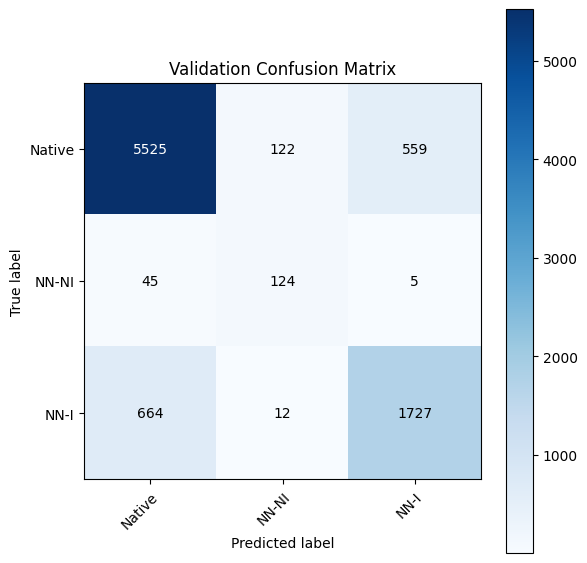


🔁 Epoch 67/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 944.24it/s]


📉 Train Loss: 0.3254 | Accuracy: 0.8567
📈 Val Loss:   0.3619 | Accuracy: 0.8365

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.88      6206
NN Non-Invasive       0.50      0.72      0.59       174
    NN Invasive       0.72      0.76      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.78      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



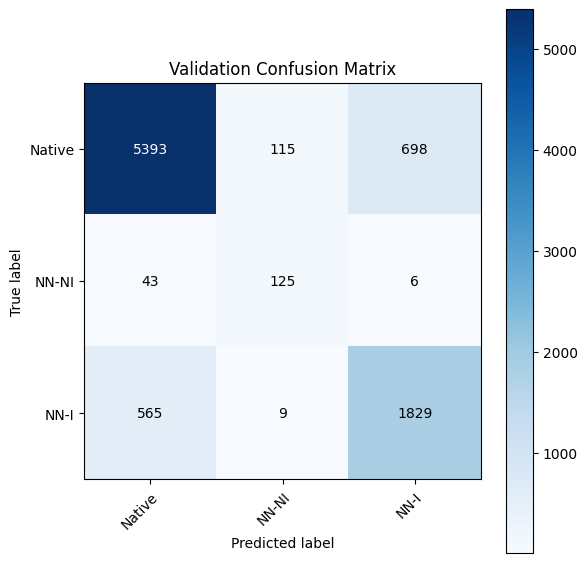


🔁 Epoch 68/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 944.38it/s]


📉 Train Loss: 0.3247 | Accuracy: 0.8572
📈 Val Loss:   0.3612 | Accuracy: 0.8368

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.89      6206
NN Non-Invasive       0.51      0.70      0.59       174
    NN Invasive       0.75      0.70      0.73      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.76      0.73      8783
   weighted avg       0.84      0.84      0.84      8783



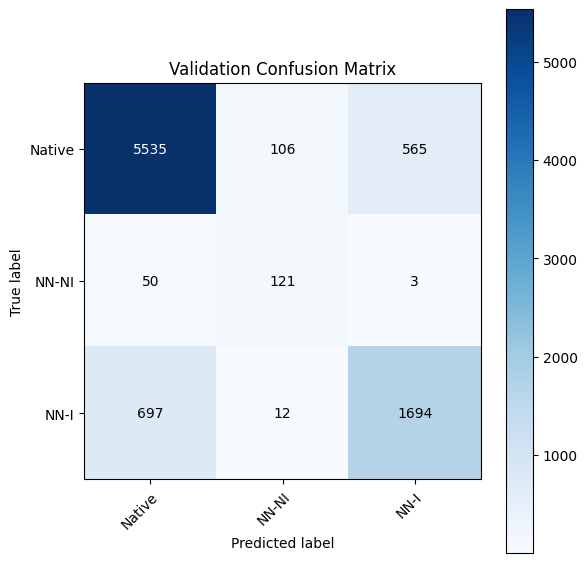


🔁 Epoch 69/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 938.74it/s]


📉 Train Loss: 0.3237 | Accuracy: 0.8589
📈 Val Loss:   0.3566 | Accuracy: 0.8401

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.55      0.66      0.60       174
    NN Invasive       0.73      0.76      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.76      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



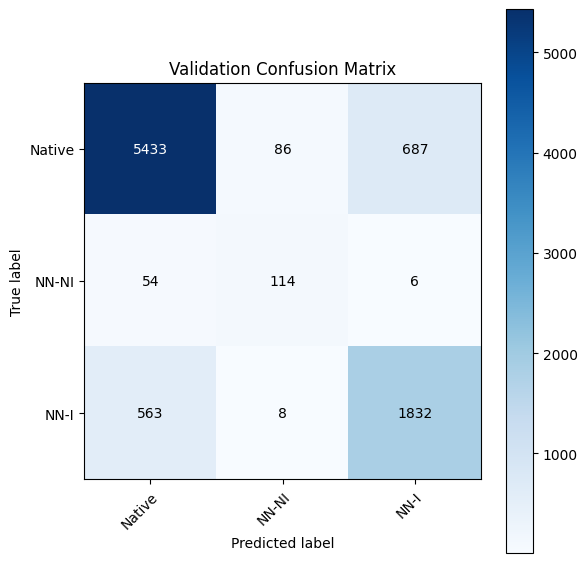


🔁 Epoch 70/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 796.66it/s]


📉 Train Loss: 0.3229 | Accuracy: 0.8586
📈 Val Loss:   0.3561 | Accuracy: 0.8405

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.54      0.64      0.59       174
    NN Invasive       0.74      0.73      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.75      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



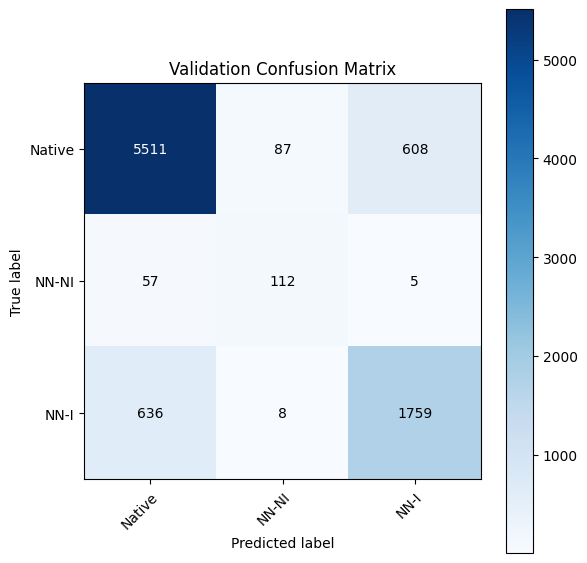


🔁 Epoch 71/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 951.10it/s]


📉 Train Loss: 0.3222 | Accuracy: 0.8581
📈 Val Loss:   0.3584 | Accuracy: 0.8421

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.52      0.69      0.59       174
    NN Invasive       0.76      0.72      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.77      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



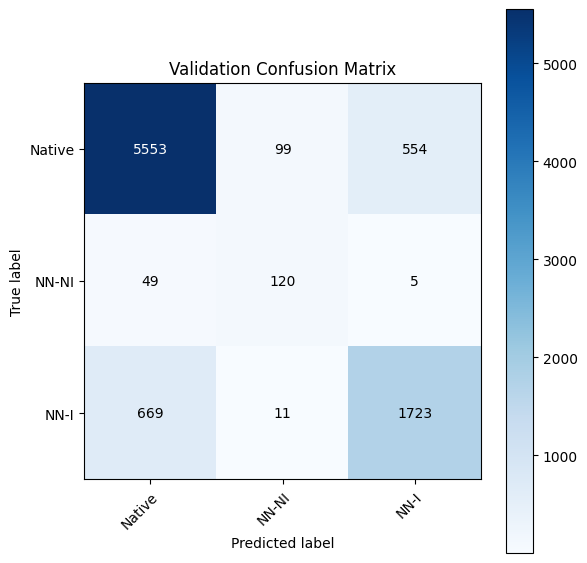


🔁 Epoch 72/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 896.64it/s]


📉 Train Loss: 0.3207 | Accuracy: 0.8598
📈 Val Loss:   0.3572 | Accuracy: 0.8376

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.88      6206
NN Non-Invasive       0.54      0.67      0.60       174
    NN Invasive       0.72      0.77      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.77      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



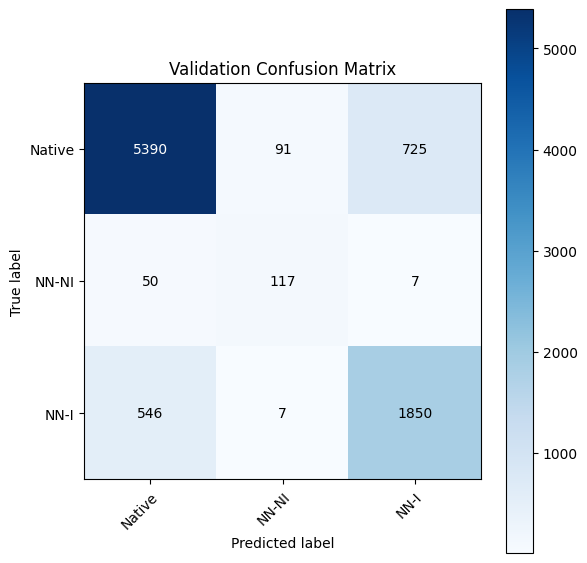


🔁 Epoch 73/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 897.84it/s]


📉 Train Loss: 0.3195 | Accuracy: 0.8613
📈 Val Loss:   0.3566 | Accuracy: 0.8392

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.88      0.89      6206
NN Non-Invasive       0.53      0.68      0.60       174
    NN Invasive       0.73      0.75      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.77      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



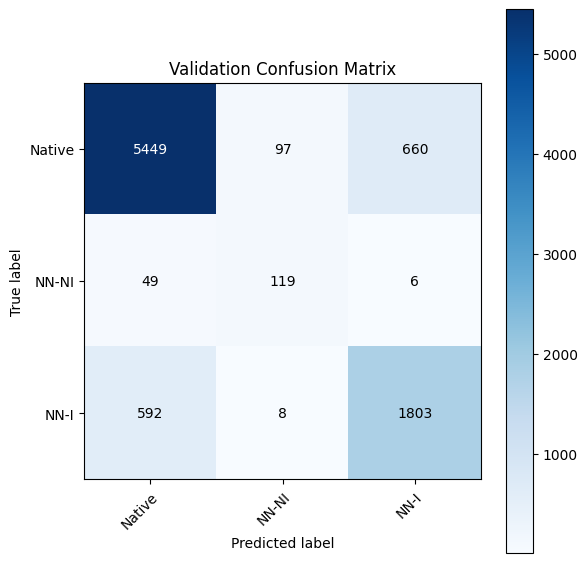


🔁 Epoch 74/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 722.67it/s]


📉 Train Loss: 0.3187 | Accuracy: 0.8593
📈 Val Loss:   0.3562 | Accuracy: 0.8454

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.91      0.89      6206
NN Non-Invasive       0.60      0.60      0.60       174
    NN Invasive       0.77      0.69      0.73      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.73      0.74      8783
   weighted avg       0.84      0.85      0.84      8783



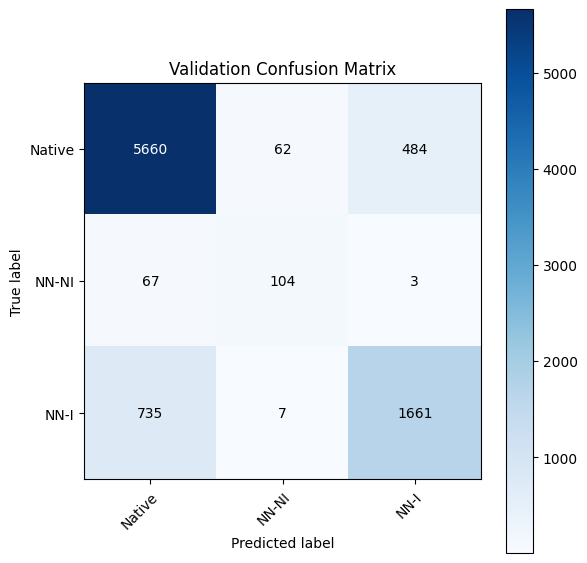


🔁 Epoch 75/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 625.81it/s]


📉 Train Loss: 0.3180 | Accuracy: 0.8608
📈 Val Loss:   0.3545 | Accuracy: 0.8409

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.57      0.60      0.59       174
    NN Invasive       0.74      0.74      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.74      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



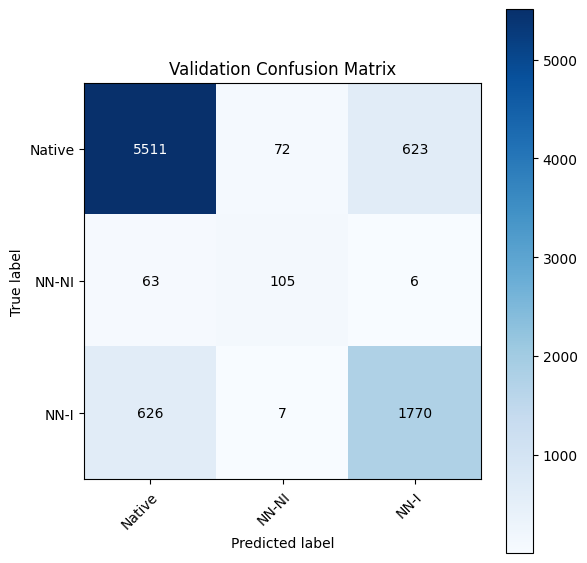


🔁 Epoch 76/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 947.81it/s]


📉 Train Loss: 0.3167 | Accuracy: 0.8612
📈 Val Loss:   0.3545 | Accuracy: 0.8386

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.89      6206
NN Non-Invasive       0.56      0.64      0.60       174
    NN Invasive       0.72      0.76      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.76      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



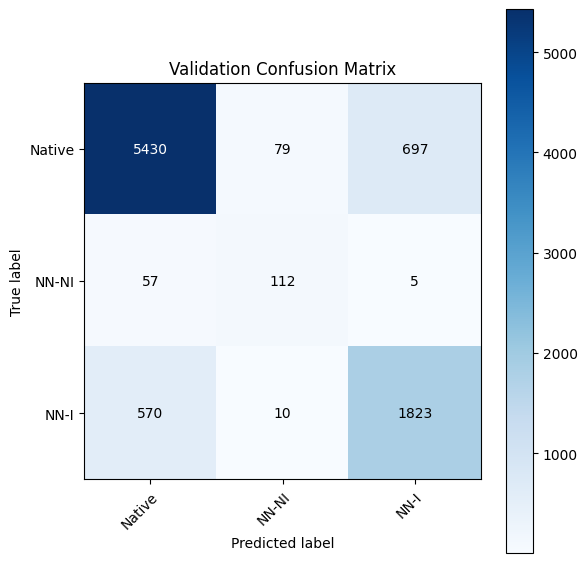


🔁 Epoch 77/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 934.92it/s]


📉 Train Loss: 0.3156 | Accuracy: 0.8623
📈 Val Loss:   0.3614 | Accuracy: 0.8318

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.85      0.88      6206
NN Non-Invasive       0.51      0.71      0.59       174
    NN Invasive       0.70      0.79      0.74      2403

       accuracy                           0.83      8783
      macro avg       0.70      0.79      0.74      8783
   weighted avg       0.84      0.83      0.84      8783



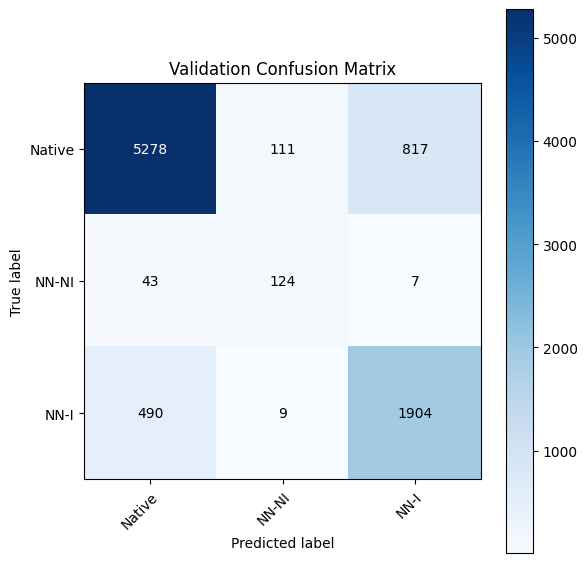


🔁 Epoch 78/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 919.55it/s]


📉 Train Loss: 0.3151 | Accuracy: 0.8623
📈 Val Loss:   0.3606 | Accuracy: 0.8430

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.91      0.89      6206
NN Non-Invasive       0.53      0.69      0.60       174
    NN Invasive       0.78      0.67      0.72      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.76      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



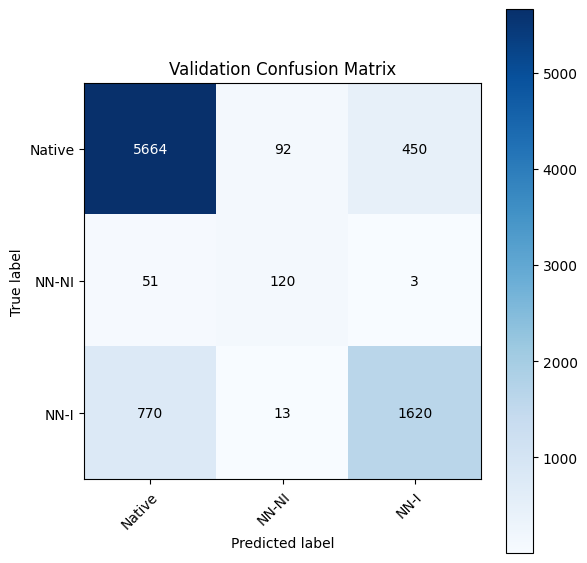


🔁 Epoch 79/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 673.07it/s]


📉 Train Loss: 0.3134 | Accuracy: 0.8636
📈 Val Loss:   0.3553 | Accuracy: 0.8437

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.54      0.68      0.60       174
    NN Invasive       0.75      0.73      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.77      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



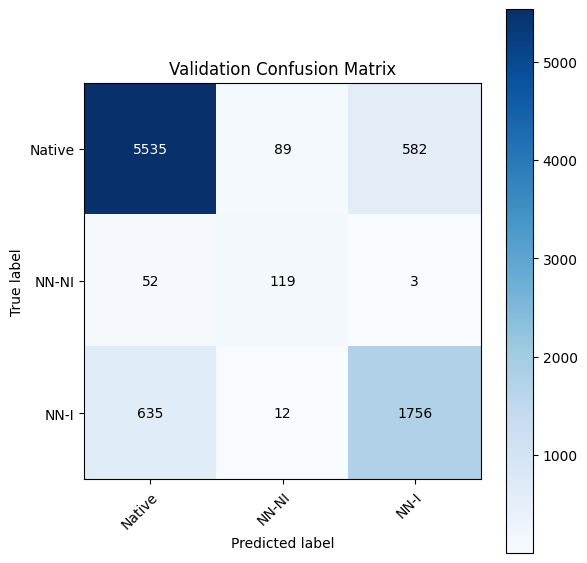


🔁 Epoch 80/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 926.27it/s]


📉 Train Loss: 0.3131 | Accuracy: 0.8648
📈 Val Loss:   0.3525 | Accuracy: 0.8415

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.88      0.89      6206
NN Non-Invasive       0.57      0.66      0.61       174
    NN Invasive       0.74      0.74      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.76      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



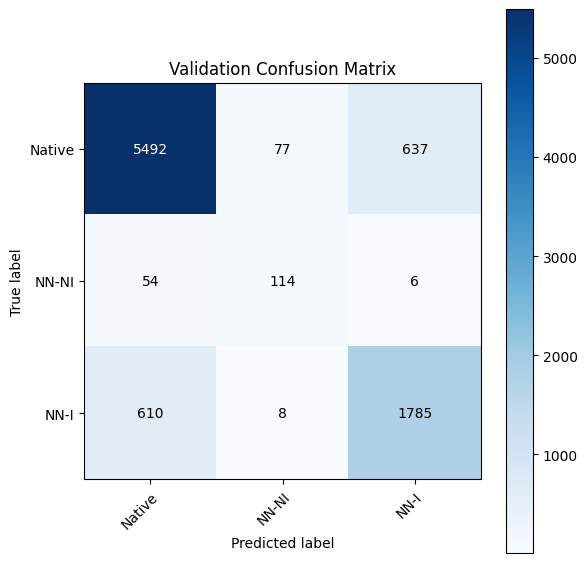


🔁 Epoch 81/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 908.50it/s]


📉 Train Loss: 0.3115 | Accuracy: 0.8638
📈 Val Loss:   0.3580 | Accuracy: 0.8431

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.51      0.72      0.60       174
    NN Invasive       0.76      0.71      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.78      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



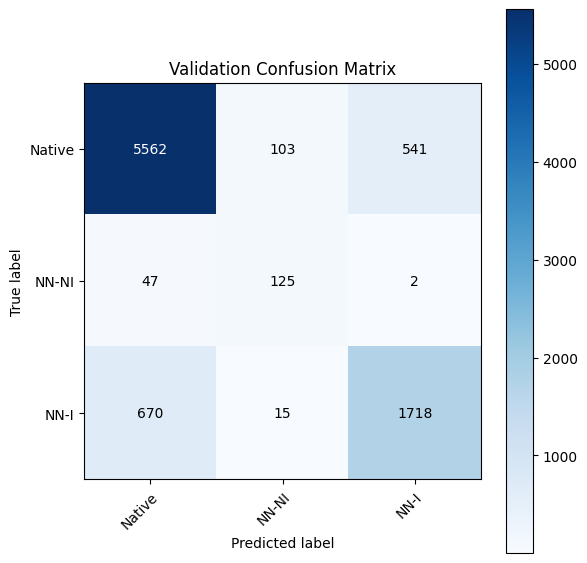


🔁 Epoch 82/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 893.82it/s]


📉 Train Loss: 0.3114 | Accuracy: 0.8640
📈 Val Loss:   0.3550 | Accuracy: 0.8376

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.88      0.89      6206
NN Non-Invasive       0.55      0.71      0.62       174
    NN Invasive       0.73      0.74      0.73      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.78      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



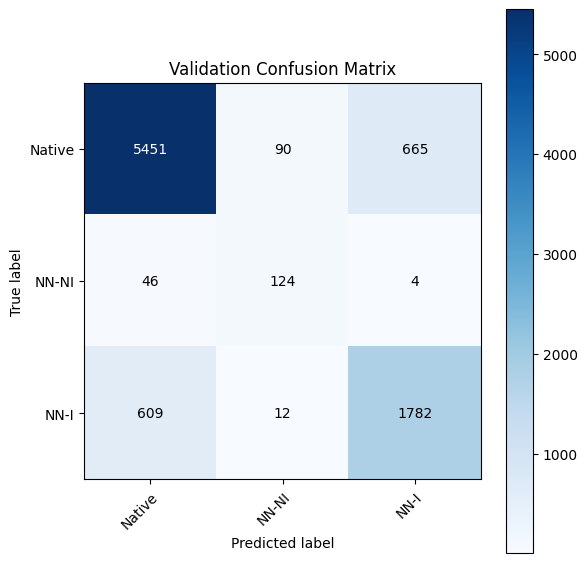


🔁 Epoch 83/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 910.25it/s]


📉 Train Loss: 0.3099 | Accuracy: 0.8641
📈 Val Loss:   0.3544 | Accuracy: 0.8392

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.89      6206
NN Non-Invasive       0.54      0.72      0.62       174
    NN Invasive       0.72      0.76      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.78      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



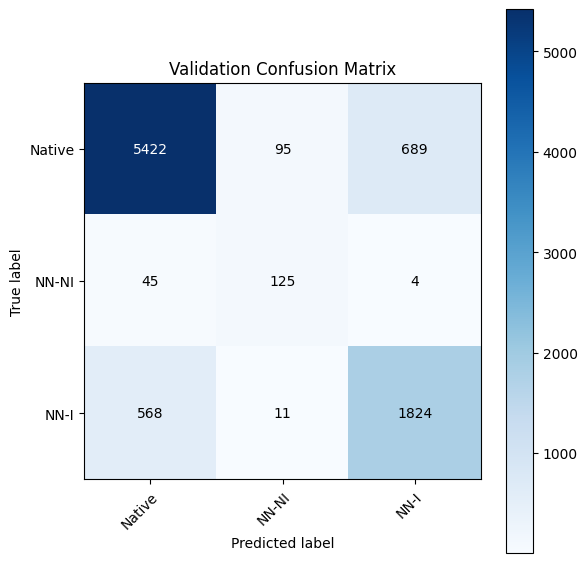


🔁 Epoch 84/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 814.67it/s]


📉 Train Loss: 0.3088 | Accuracy: 0.8656
📈 Val Loss:   0.3532 | Accuracy: 0.8445

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.56      0.71      0.62       174
    NN Invasive       0.76      0.72      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.77      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



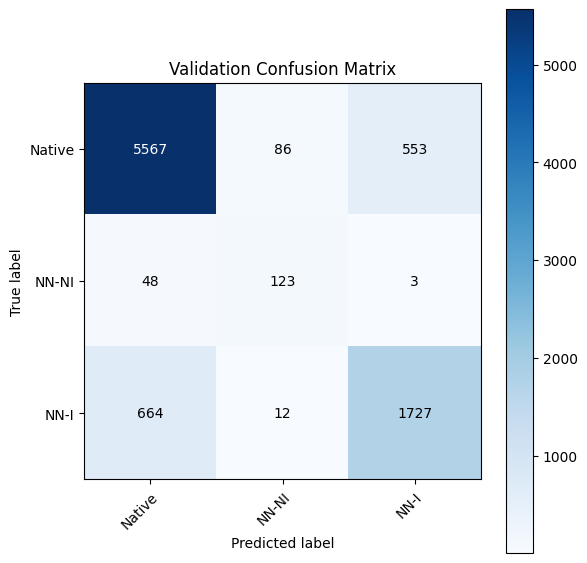


🔁 Epoch 85/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 899.65it/s]


📉 Train Loss: 0.3079 | Accuracy: 0.8657
📈 Val Loss:   0.3567 | Accuracy: 0.8374

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.88      0.89      6206
NN Non-Invasive       0.49      0.75      0.59       174
    NN Invasive       0.74      0.74      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.79      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



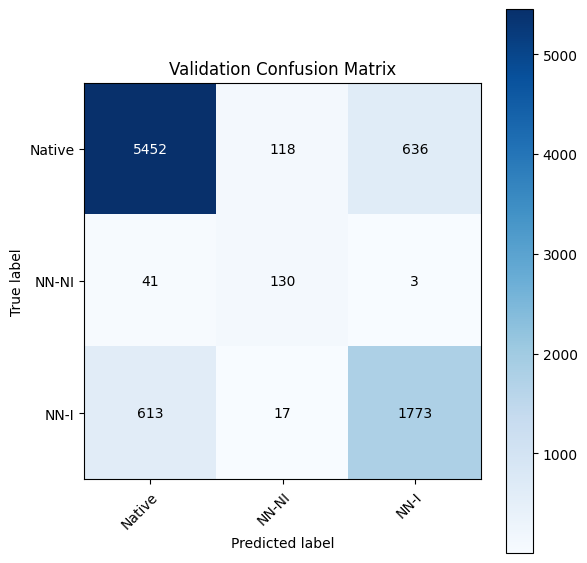


🔁 Epoch 86/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 857.59it/s]


📉 Train Loss: 0.3075 | Accuracy: 0.8650
📈 Val Loss:   0.3548 | Accuracy: 0.8406

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.54      0.76      0.63       174
    NN Invasive       0.73      0.75      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.80      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



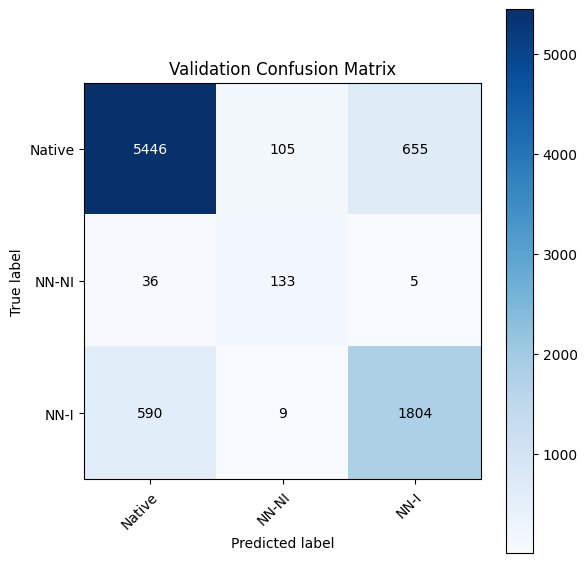


🔁 Epoch 87/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 882.02it/s]


📉 Train Loss: 0.3064 | Accuracy: 0.8656
📈 Val Loss:   0.3510 | Accuracy: 0.8434

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.60      0.66      0.63       174
    NN Invasive       0.74      0.74      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.74      0.76      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



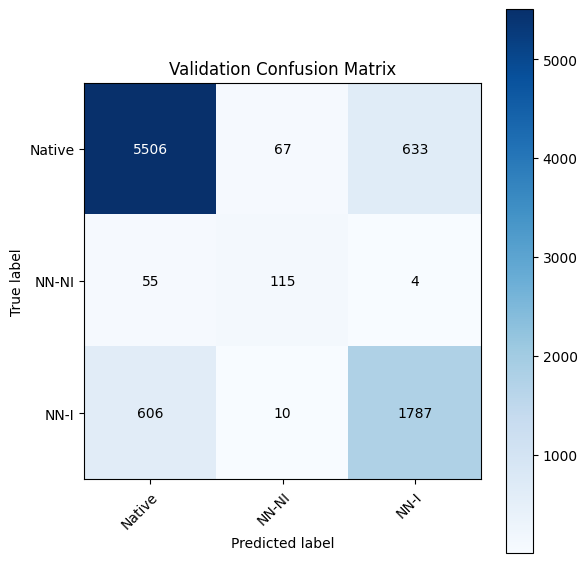


🔁 Epoch 88/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 800.07it/s]


📉 Train Loss: 0.3055 | Accuracy: 0.8671
📈 Val Loss:   0.3559 | Accuracy: 0.8339

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.85      0.88      6206
NN Non-Invasive       0.54      0.74      0.62       174
    NN Invasive       0.70      0.79      0.74      2403

       accuracy                           0.83      8783
      macro avg       0.72      0.79      0.75      8783
   weighted avg       0.84      0.83      0.84      8783



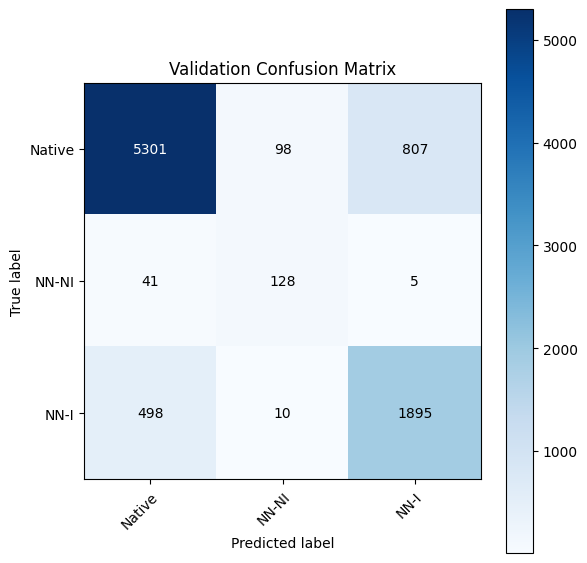


🔁 Epoch 89/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 611.85it/s]


📉 Train Loss: 0.3044 | Accuracy: 0.8688
📈 Val Loss:   0.3543 | Accuracy: 0.8462

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.91      0.89      6206
NN Non-Invasive       0.57      0.70      0.63       174
    NN Invasive       0.77      0.70      0.73      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.77      0.75      8783
   weighted avg       0.84      0.85      0.84      8783



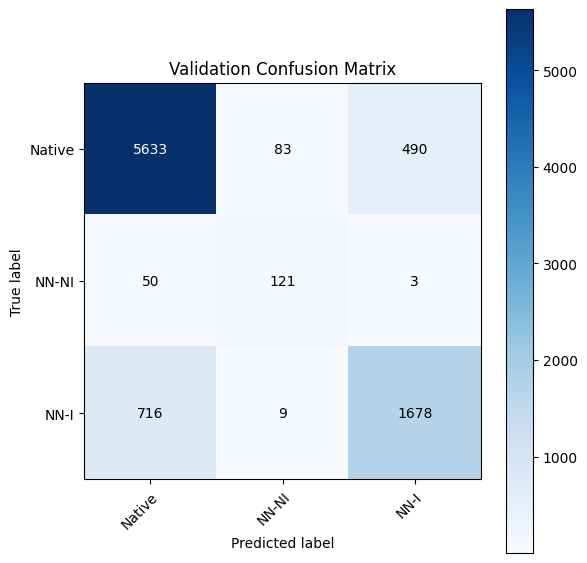


🔁 Epoch 90/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 852.34it/s]


📉 Train Loss: 0.3032 | Accuracy: 0.8682
📈 Val Loss:   0.3497 | Accuracy: 0.8464

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.62      0.63      0.63       174
    NN Invasive       0.75      0.73      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.75      0.75      8783
   weighted avg       0.85      0.85      0.85      8783



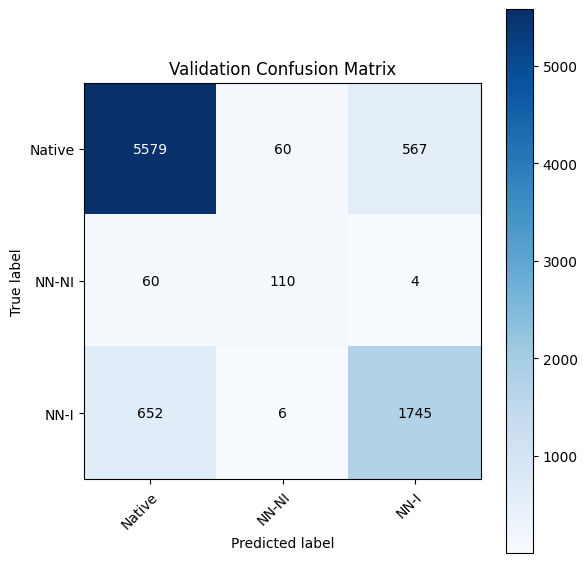


🔁 Epoch 91/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 835.07it/s]


📉 Train Loss: 0.3030 | Accuracy: 0.8672
📈 Val Loss:   0.3559 | Accuracy: 0.8329

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.85      0.88      6206
NN Non-Invasive       0.54      0.74      0.62       174
    NN Invasive       0.70      0.79      0.74      2403

       accuracy                           0.83      8783
      macro avg       0.72      0.79      0.75      8783
   weighted avg       0.84      0.83      0.84      8783



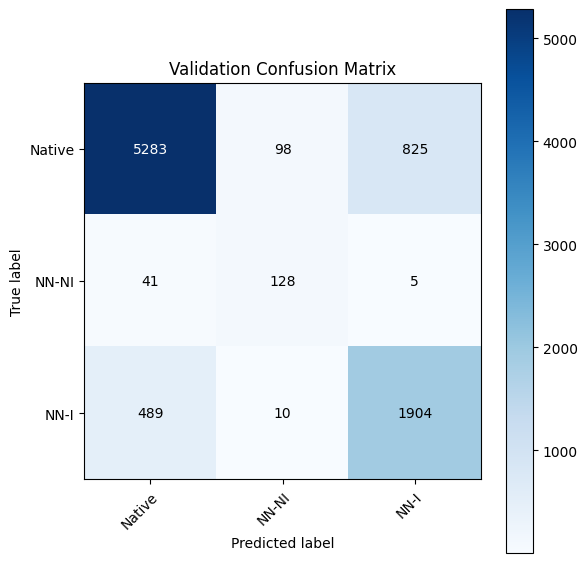


🔁 Epoch 92/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 866.81it/s]


📉 Train Loss: 0.3020 | Accuracy: 0.8680
📈 Val Loss:   0.3547 | Accuracy: 0.8469

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.91      0.89      6206
NN Non-Invasive       0.55      0.74      0.63       174
    NN Invasive       0.78      0.69      0.73      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.78      0.75      8783
   weighted avg       0.85      0.85      0.85      8783



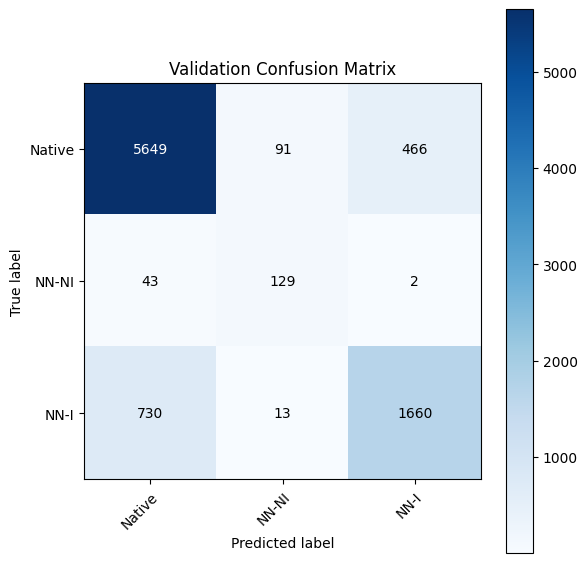


🔁 Epoch 93/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 696.27it/s]


📉 Train Loss: 0.3007 | Accuracy: 0.8687
📈 Val Loss:   0.3523 | Accuracy: 0.8364

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.86      0.88      6206
NN Non-Invasive       0.57      0.72      0.64       174
    NN Invasive       0.71      0.77      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.79      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



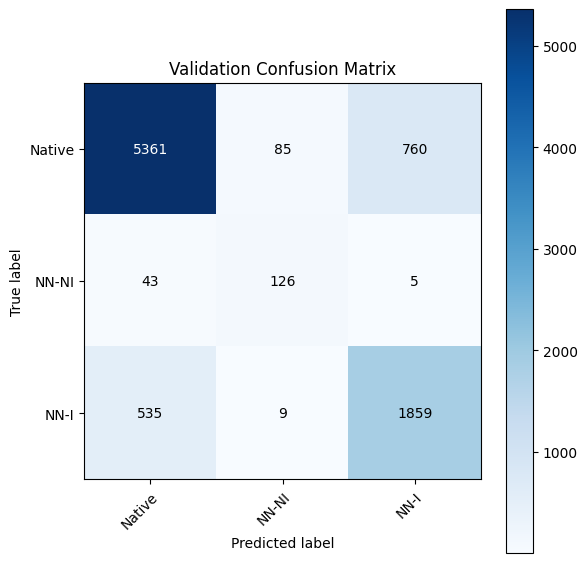


🔁 Epoch 94/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 834.56it/s]


📉 Train Loss: 0.2999 | Accuracy: 0.8697
📈 Val Loss:   0.3490 | Accuracy: 0.8442

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.61      0.71      0.65       174
    NN Invasive       0.73      0.75      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.75      0.78      0.76      8783
   weighted avg       0.85      0.84      0.85      8783



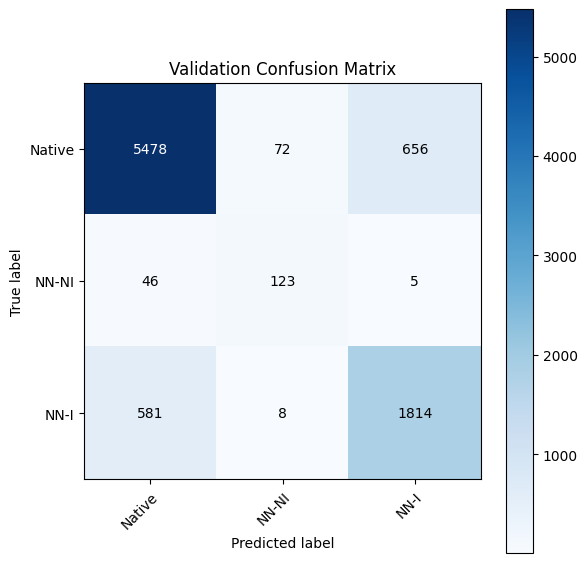


🔁 Epoch 95/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 904.99it/s]


📉 Train Loss: 0.2990 | Accuracy: 0.8692
📈 Val Loss:   0.3512 | Accuracy: 0.8434

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.56      0.75      0.64       174
    NN Invasive       0.74      0.74      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.79      0.76      8783
   weighted avg       0.85      0.84      0.84      8783



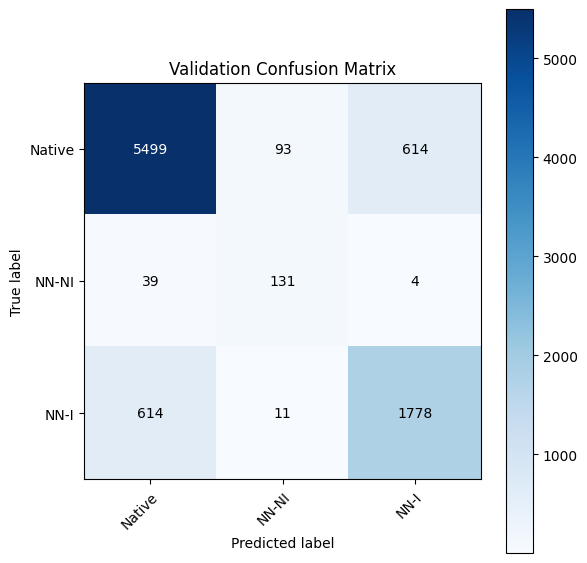


🔁 Epoch 96/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 856.77it/s]


📉 Train Loss: 0.2983 | Accuracy: 0.8701
📈 Val Loss:   0.3505 | Accuracy: 0.8420

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.56      0.71      0.63       174
    NN Invasive       0.73      0.76      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.78      0.75      8783
   weighted avg       0.85      0.84      0.84      8783



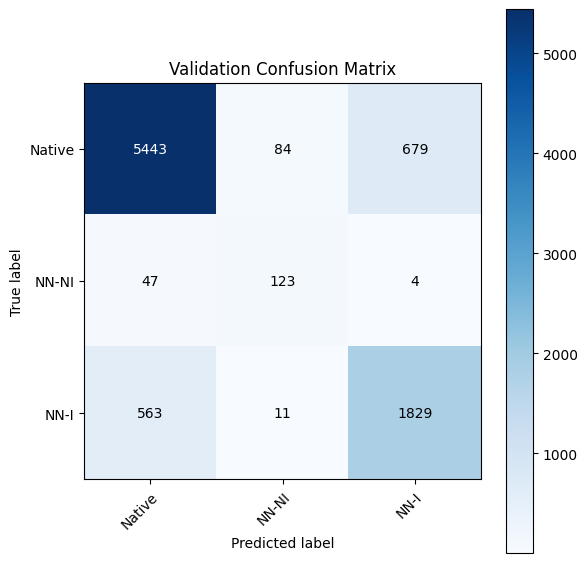


🔁 Epoch 97/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 877.66it/s]


📉 Train Loss: 0.2971 | Accuracy: 0.8709
📈 Val Loss:   0.3567 | Accuracy: 0.8390

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.89      6206
NN Non-Invasive       0.49      0.79      0.60       174
    NN Invasive       0.73      0.75      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.71      0.81      0.74      8783
   weighted avg       0.85      0.84      0.84      8783



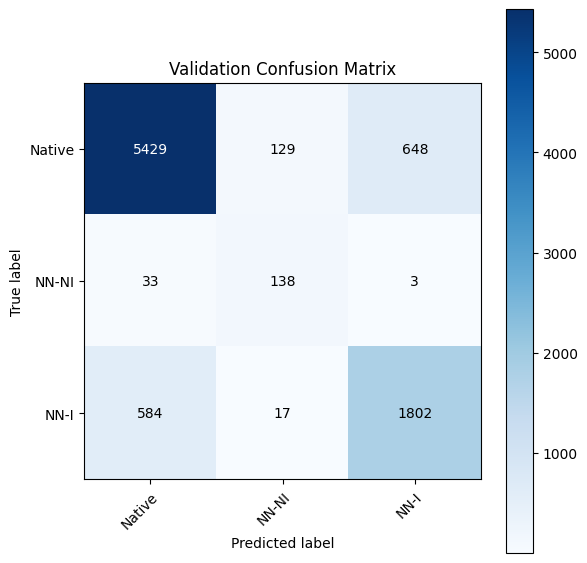


🔁 Epoch 98/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 807.65it/s]


📉 Train Loss: 0.2968 | Accuracy: 0.8702
📈 Val Loss:   0.3491 | Accuracy: 0.8465

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.57      0.72      0.63       174
    NN Invasive       0.76      0.73      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.78      0.76      8783
   weighted avg       0.85      0.85      0.85      8783



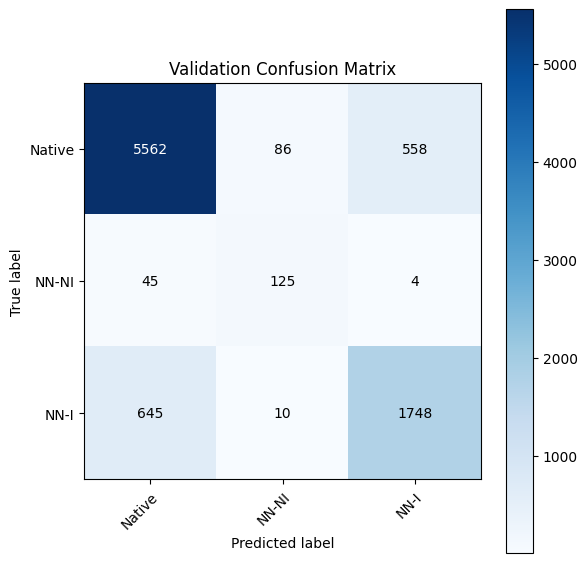


🔁 Epoch 99/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 823.00it/s]


📉 Train Loss: 0.2954 | Accuracy: 0.8713
📈 Val Loss:   0.3499 | Accuracy: 0.8454

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.59      0.71      0.64       174
    NN Invasive       0.76      0.72      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.77      0.76      8783
   weighted avg       0.84      0.85      0.84      8783



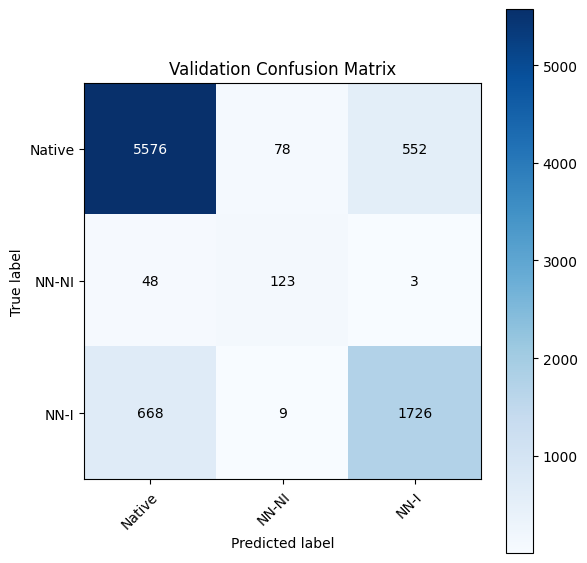


🔁 Epoch 100/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 824.49it/s]


📉 Train Loss: 0.2950 | Accuracy: 0.8713
📈 Val Loss:   0.3468 | Accuracy: 0.8421

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.64      0.63      0.63       174
    NN Invasive       0.72      0.76      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.75      0.76      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



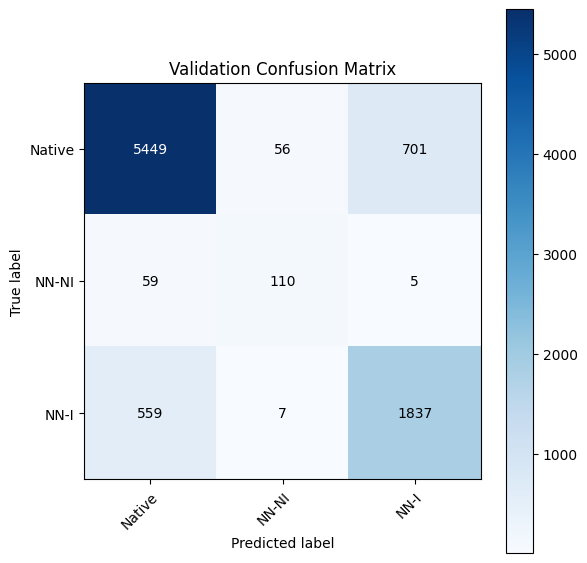


🔁 Epoch 101/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 902.56it/s]


📉 Train Loss: 0.2942 | Accuracy: 0.8711
📈 Val Loss:   0.3472 | Accuracy: 0.8429

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.62      0.68      0.65       174
    NN Invasive       0.73      0.75      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.75      0.77      0.76      8783
   weighted avg       0.84      0.84      0.84      8783



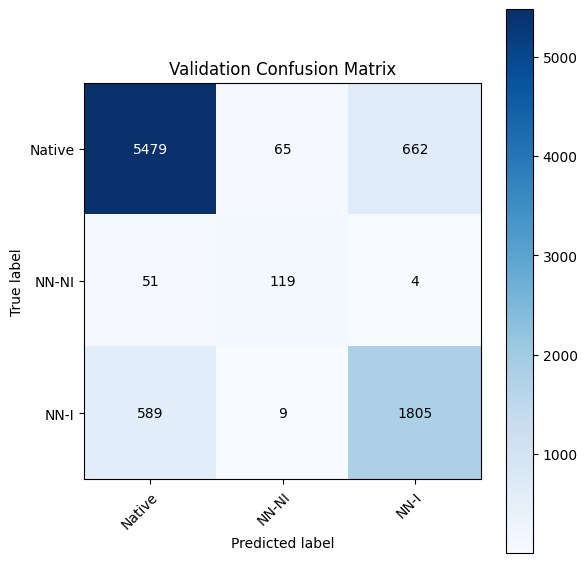


🔁 Epoch 102/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 671.01it/s]


📉 Train Loss: 0.2929 | Accuracy: 0.8725
📈 Val Loss:   0.3517 | Accuracy: 0.8383

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.88      6206
NN Non-Invasive       0.58      0.71      0.64       174
    NN Invasive       0.72      0.77      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.78      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



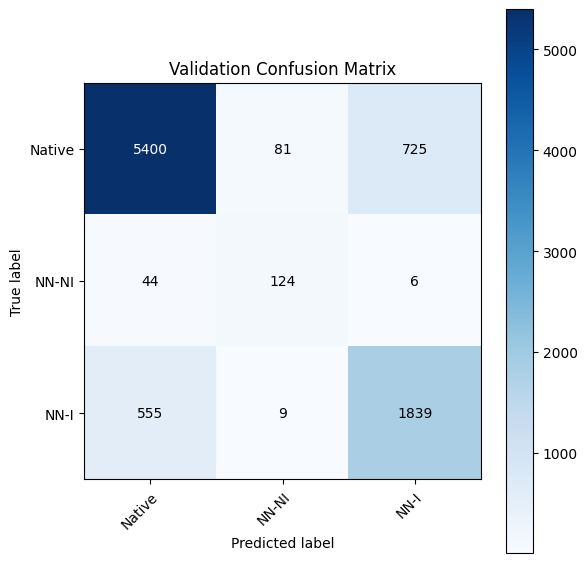


🔁 Epoch 103/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 662.95it/s]


📉 Train Loss: 0.2922 | Accuracy: 0.8726
📈 Val Loss:   0.3481 | Accuracy: 0.8453

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.58      0.74      0.65       174
    NN Invasive       0.74      0.74      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.79      0.76      8783
   weighted avg       0.85      0.85      0.85      8783



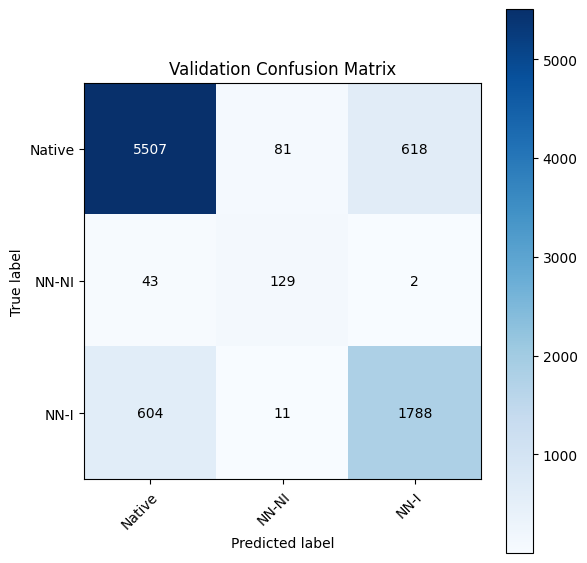


🔁 Epoch 104/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 832.93it/s]


📉 Train Loss: 0.2910 | Accuracy: 0.8734
📈 Val Loss:   0.3494 | Accuracy: 0.8420

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.89      6206
NN Non-Invasive       0.56      0.74      0.64       174
    NN Invasive       0.73      0.77      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.79      0.76      8783
   weighted avg       0.85      0.84      0.84      8783



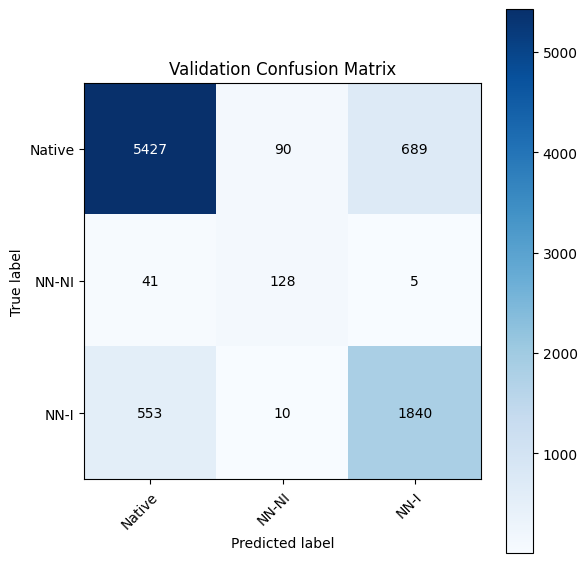


🔁 Epoch 105/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 841.21it/s]


📉 Train Loss: 0.2908 | Accuracy: 0.8729
📈 Val Loss:   0.3458 | Accuracy: 0.8473

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.61      0.66      0.63       174
    NN Invasive       0.75      0.74      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.76      0.76      8783
   weighted avg       0.85      0.85      0.85      8783



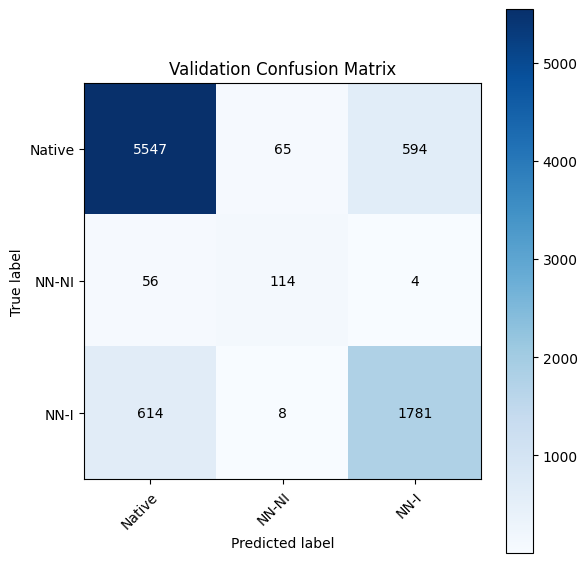


🔁 Epoch 106/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 869.49it/s]


📉 Train Loss: 0.2892 | Accuracy: 0.8742
📈 Val Loss:   0.3551 | Accuracy: 0.8483

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.92      0.90      6206
NN Non-Invasive       0.59      0.73      0.65       174
    NN Invasive       0.80      0.66      0.73      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.77      0.76      8783
   weighted avg       0.85      0.85      0.84      8783



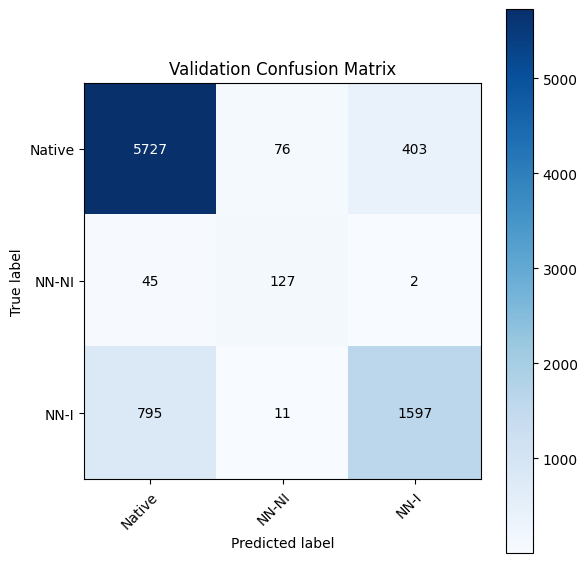


🔁 Epoch 107/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 700.70it/s]


📉 Train Loss: 0.2884 | Accuracy: 0.8747
📈 Val Loss:   0.3465 | Accuracy: 0.8463

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.89      0.89      6206
NN Non-Invasive       0.58      0.71      0.64       174
    NN Invasive       0.74      0.75      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.78      0.76      8783
   weighted avg       0.85      0.85      0.85      8783



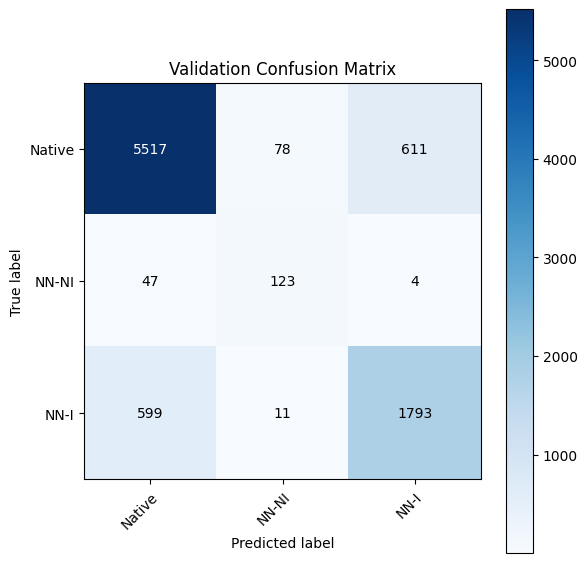


🔁 Epoch 108/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 789.52it/s]


📉 Train Loss: 0.2880 | Accuracy: 0.8752
📈 Val Loss:   0.3495 | Accuracy: 0.8422

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.56      0.79      0.65       174
    NN Invasive       0.73      0.76      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.81      0.76      8783
   weighted avg       0.85      0.84      0.84      8783



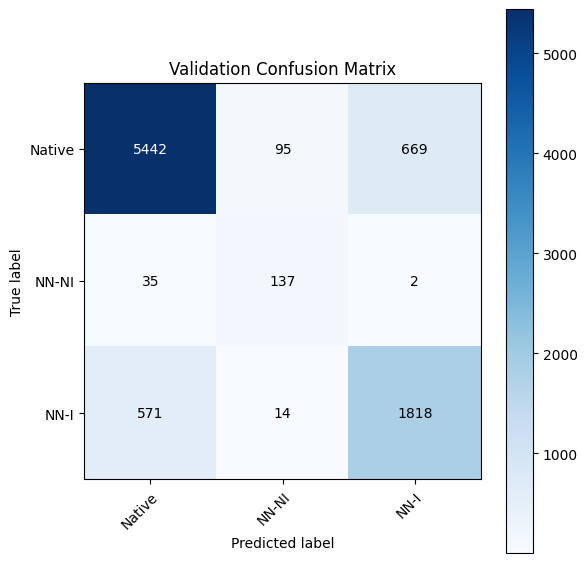


🔁 Epoch 109/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 803.69it/s]


📉 Train Loss: 0.2872 | Accuracy: 0.8745
📈 Val Loss:   0.3485 | Accuracy: 0.8447

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.56      0.76      0.64       174
    NN Invasive       0.74      0.75      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.80      0.76      8783
   weighted avg       0.85      0.84      0.85      8783



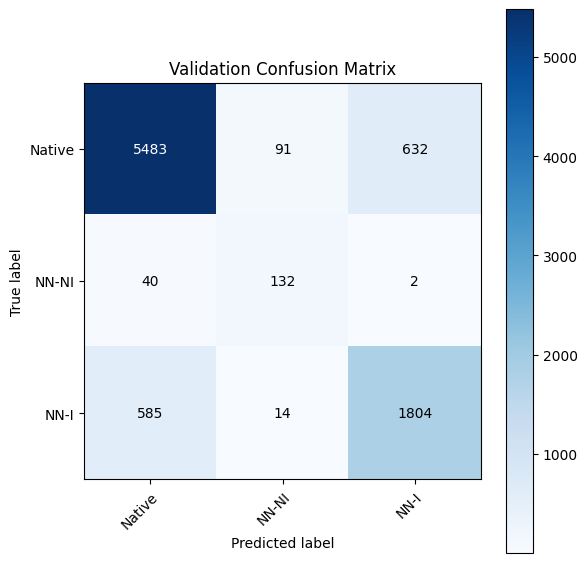


🔁 Epoch 110/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 814.50it/s]


📉 Train Loss: 0.2859 | Accuracy: 0.8759
📈 Val Loss:   0.3453 | Accuracy: 0.8463

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.89      0.89      6206
NN Non-Invasive       0.59      0.72      0.65       174
    NN Invasive       0.74      0.75      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.79      0.76      8783
   weighted avg       0.85      0.85      0.85      8783



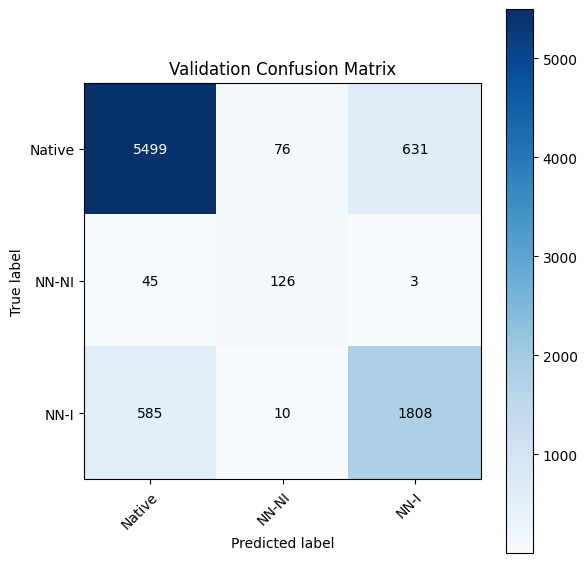


🔁 Epoch 111/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 661.85it/s]


📉 Train Loss: 0.2858 | Accuracy: 0.8758
📈 Val Loss:   0.3523 | Accuracy: 0.8469

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.91      0.89      6206
NN Non-Invasive       0.56      0.79      0.66       174
    NN Invasive       0.77      0.70      0.73      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.80      0.76      8783
   weighted avg       0.85      0.85      0.85      8783



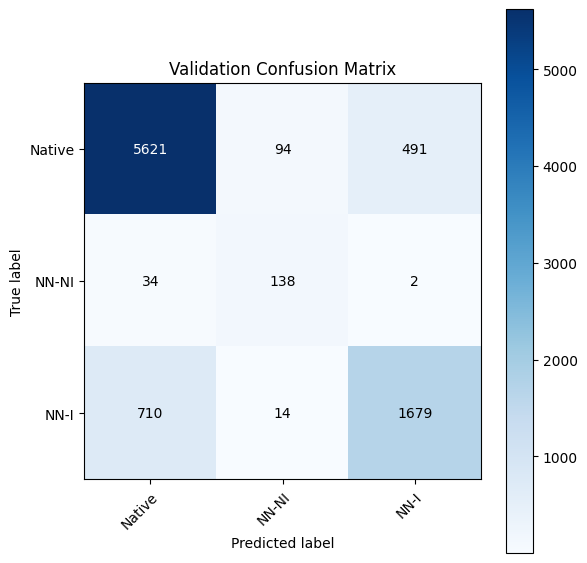


🔁 Epoch 112/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 669.23it/s]


📉 Train Loss: 0.2845 | Accuracy: 0.8768
📈 Val Loss:   0.3479 | Accuracy: 0.8415

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.59      0.73      0.65       174
    NN Invasive       0.73      0.75      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.74      0.79      0.76      8783
   weighted avg       0.84      0.84      0.84      8783



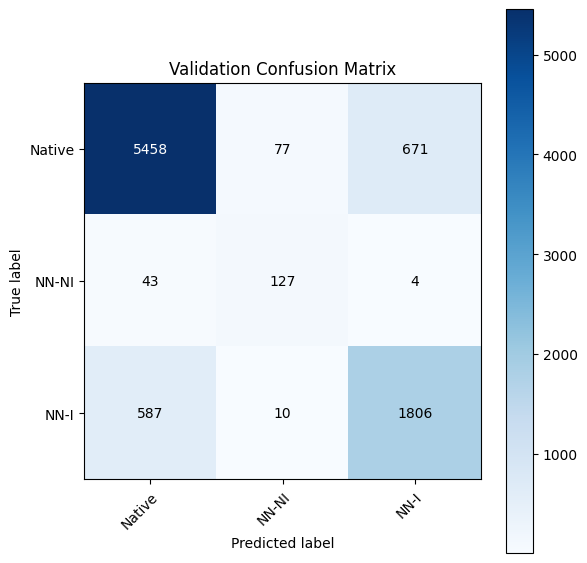


🔁 Epoch 113/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 786.28it/s]


📉 Train Loss: 0.2832 | Accuracy: 0.8765
📈 Val Loss:   0.3469 | Accuracy: 0.8414

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.89      6206
NN Non-Invasive       0.60      0.72      0.65       174
    NN Invasive       0.72      0.77      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.74      0.79      0.76      8783
   weighted avg       0.85      0.84      0.84      8783



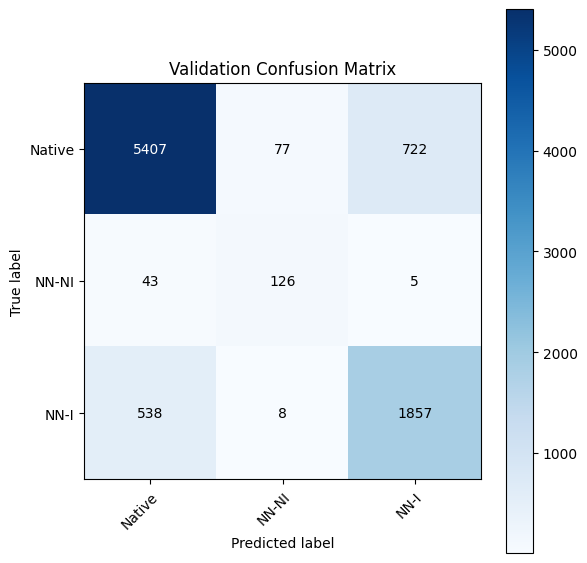


🔁 Epoch 114/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 795.47it/s]


📉 Train Loss: 0.2825 | Accuracy: 0.8766
📈 Val Loss:   0.3515 | Accuracy: 0.8374

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.86      0.88      6206
NN Non-Invasive       0.53      0.80      0.64       174
    NN Invasive       0.71      0.78      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.72      0.81      0.76      8783
   weighted avg       0.85      0.84      0.84      8783



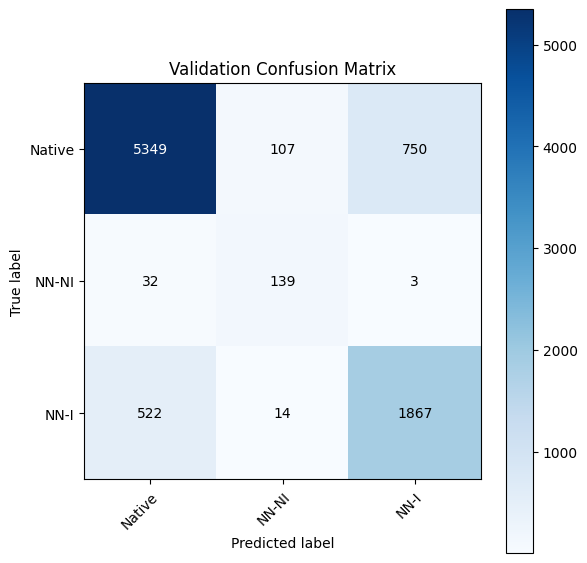


🔁 Epoch 115/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 804.97it/s]


📉 Train Loss: 0.2820 | Accuracy: 0.8776
📈 Val Loss:   0.3478 | Accuracy: 0.8431

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.89      6206
NN Non-Invasive       0.57      0.80      0.66       174
    NN Invasive       0.73      0.76      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.81      0.77      8783
   weighted avg       0.85      0.84      0.84      8783



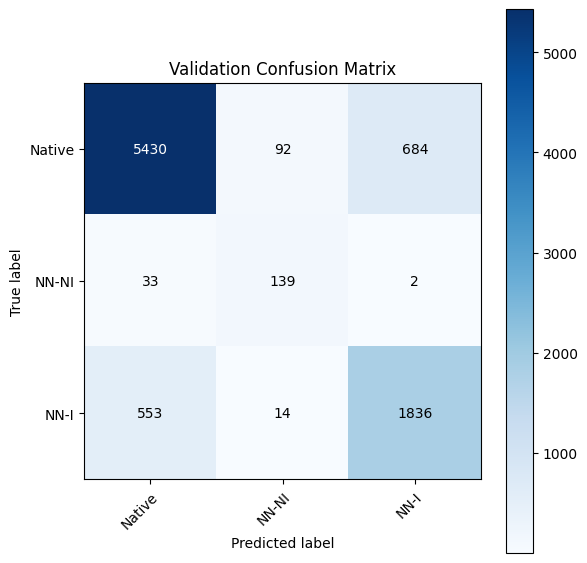


🔁 Epoch 116/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 636.40it/s]


📉 Train Loss: 0.2817 | Accuracy: 0.8766
📈 Val Loss:   0.3544 | Accuracy: 0.8309

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.84      0.88      6206
NN Non-Invasive       0.55      0.78      0.64       174
    NN Invasive       0.69      0.81      0.74      2403

       accuracy                           0.83      8783
      macro avg       0.72      0.81      0.75      8783
   weighted avg       0.84      0.83      0.84      8783



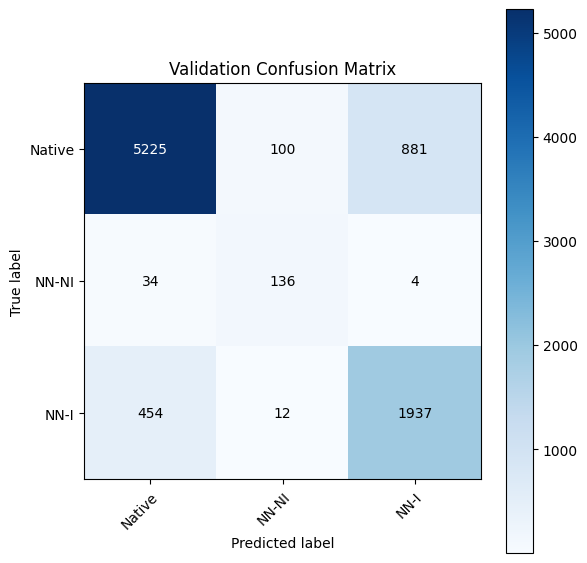


🔁 Epoch 117/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 804.68it/s]


📉 Train Loss: 0.2803 | Accuracy: 0.8784
📈 Val Loss:   0.3457 | Accuracy: 0.8448

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.59      0.76      0.67       174
    NN Invasive       0.74      0.75      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.74      0.80      0.77      8783
   weighted avg       0.85      0.84      0.85      8783



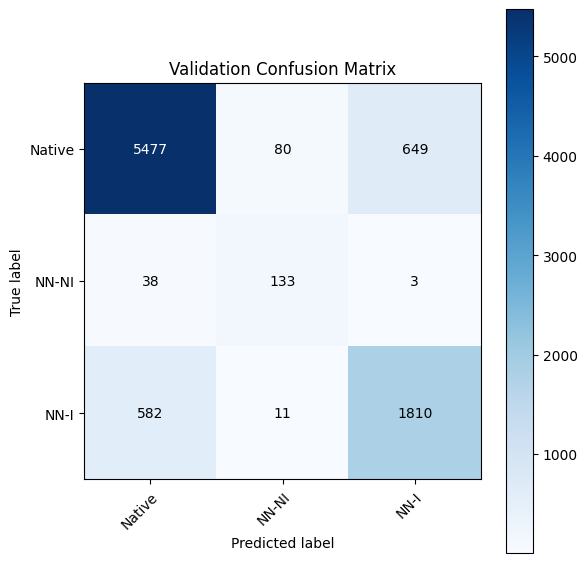


🔁 Epoch 118/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 834.71it/s]


📉 Train Loss: 0.2797 | Accuracy: 0.8783
📈 Val Loss:   0.3441 | Accuracy: 0.8453

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.60      0.75      0.67       174
    NN Invasive       0.74      0.75      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.79      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



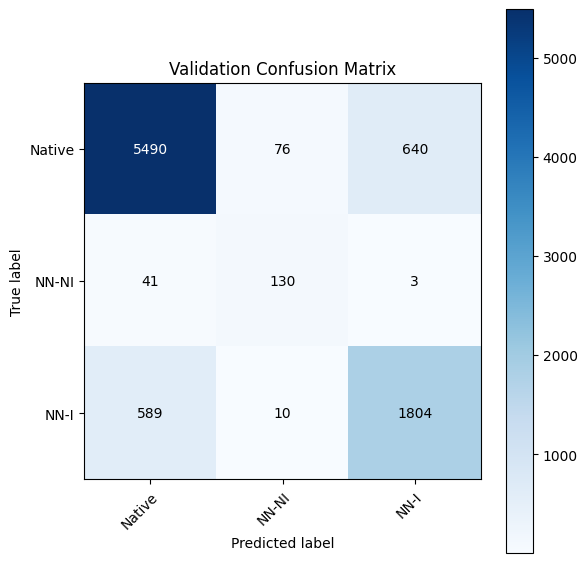


🔁 Epoch 119/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 859.98it/s]


📉 Train Loss: 0.2785 | Accuracy: 0.8786
📈 Val Loss:   0.3462 | Accuracy: 0.8413

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.89      6206
NN Non-Invasive       0.58      0.79      0.67       174
    NN Invasive       0.72      0.77      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.74      0.81      0.77      8783
   weighted avg       0.85      0.84      0.84      8783



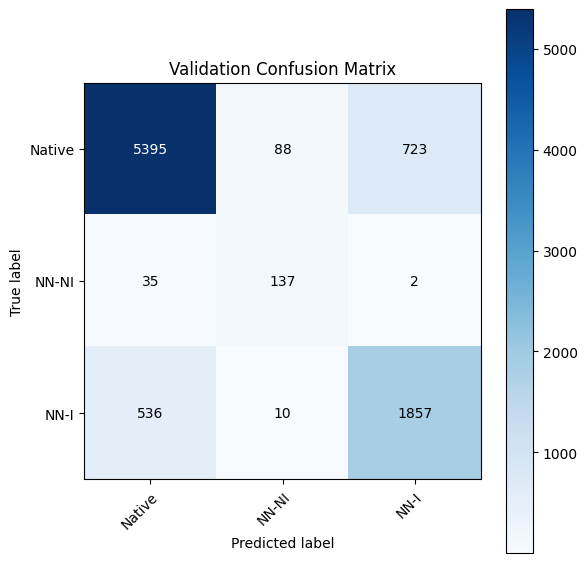


🔁 Epoch 120/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 687.63it/s]


📉 Train Loss: 0.2778 | Accuracy: 0.8798
📈 Val Loss:   0.3436 | Accuracy: 0.8466

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.89      0.89      6206
NN Non-Invasive       0.62      0.74      0.68       174
    NN Invasive       0.74      0.75      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.79      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



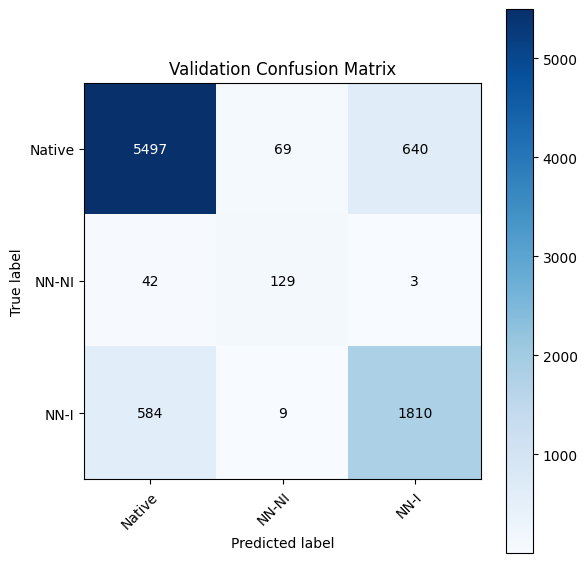


🔁 Epoch 121/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 692.40it/s]


📉 Train Loss: 0.2771 | Accuracy: 0.8798
📈 Val Loss:   0.3492 | Accuracy: 0.8417

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.87      0.89      6206
NN Non-Invasive       0.57      0.79      0.67       174
    NN Invasive       0.72      0.77      0.74      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.81      0.77      8783
   weighted avg       0.85      0.84      0.84      8783



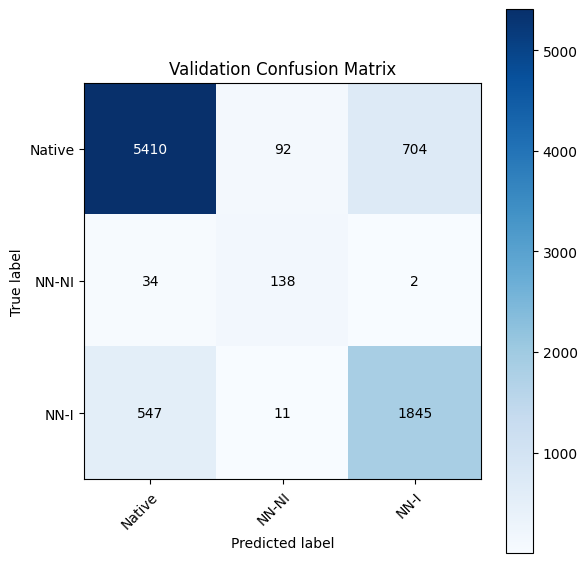


🔁 Epoch 122/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 830.03it/s]


📉 Train Loss: 0.2761 | Accuracy: 0.8797
📈 Val Loss:   0.3485 | Accuracy: 0.8495

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.91      0.90      6206
NN Non-Invasive       0.62      0.74      0.67       174
    NN Invasive       0.78      0.69      0.73      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.78      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



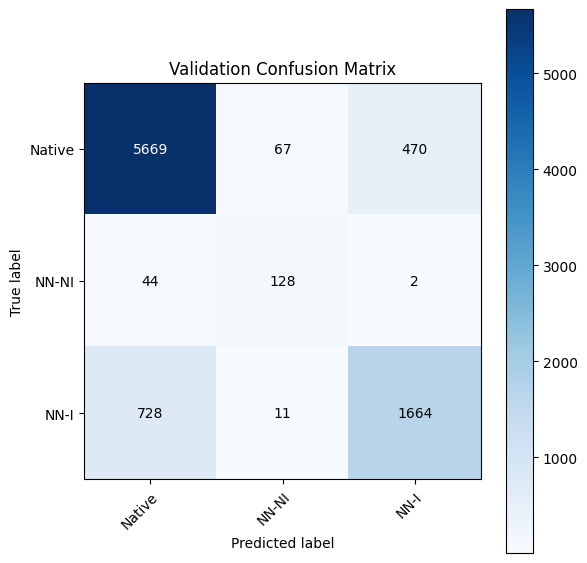


🔁 Epoch 123/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 812.82it/s]


📉 Train Loss: 0.2755 | Accuracy: 0.8807
📈 Val Loss:   0.3446 | Accuracy: 0.8450

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.61      0.75      0.67       174
    NN Invasive       0.73      0.76      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.80      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



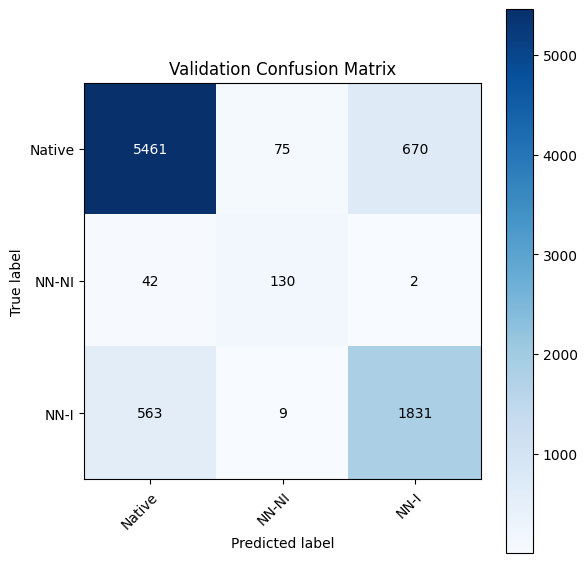


🔁 Epoch 124/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 770.79it/s]


📉 Train Loss: 0.2745 | Accuracy: 0.8815
📈 Val Loss:   0.3622 | Accuracy: 0.8289

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.93      0.82      0.87      6206
NN Non-Invasive       0.57      0.80      0.66       174
    NN Invasive       0.67      0.84      0.75      2403

       accuracy                           0.83      8783
      macro avg       0.72      0.82      0.76      8783
   weighted avg       0.85      0.83      0.83      8783



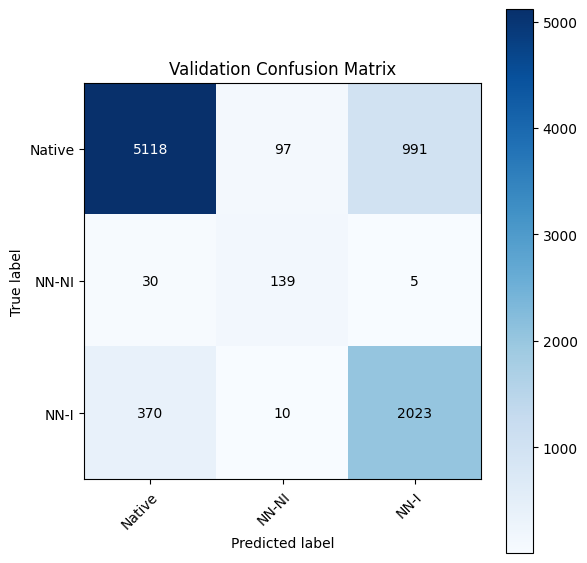


🔁 Epoch 125/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 696.20it/s]


📉 Train Loss: 0.2738 | Accuracy: 0.8812
📈 Val Loss:   0.3469 | Accuracy: 0.8407

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.86      0.89      6206
NN Non-Invasive       0.61      0.74      0.67       174
    NN Invasive       0.71      0.79      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.74      0.80      0.77      8783
   weighted avg       0.85      0.84      0.84      8783



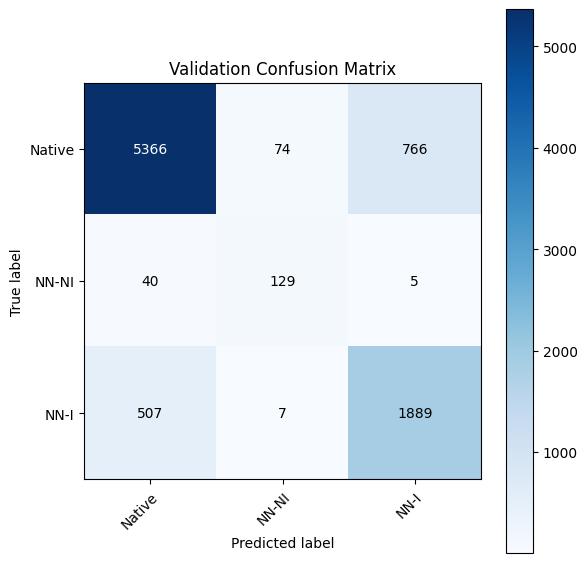


🔁 Epoch 126/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 642.84it/s]


📉 Train Loss: 0.2732 | Accuracy: 0.8823
📈 Val Loss:   0.3468 | Accuracy: 0.8421

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.87      0.89      6206
NN Non-Invasive       0.58      0.79      0.67       174
    NN Invasive       0.72      0.78      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.81      0.77      8783
   weighted avg       0.85      0.84      0.84      8783



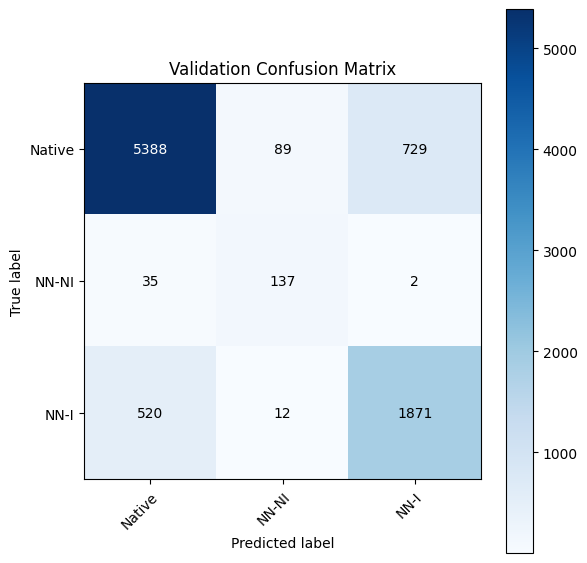


🔁 Epoch 127/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 828.53it/s]


📉 Train Loss: 0.2724 | Accuracy: 0.8821
📈 Val Loss:   0.3445 | Accuracy: 0.8493

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.62      0.75      0.68       174
    NN Invasive       0.76      0.73      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.79      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



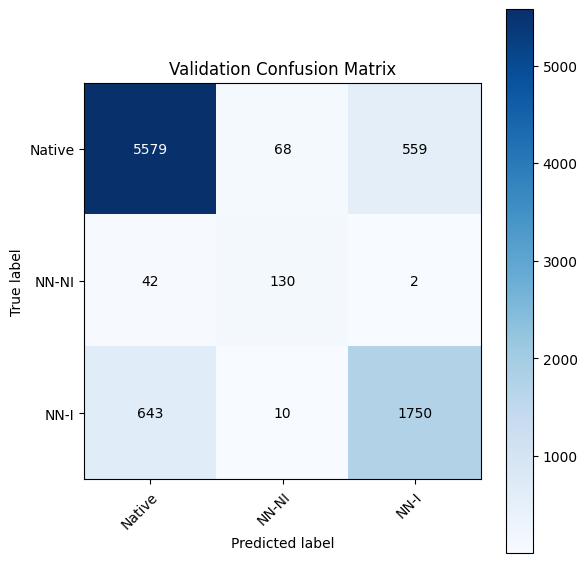


🔁 Epoch 128/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 826.16it/s]


📉 Train Loss: 0.2715 | Accuracy: 0.8836
📈 Val Loss:   0.3432 | Accuracy: 0.8482

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.64      0.73      0.68       174
    NN Invasive       0.76      0.72      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.78      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



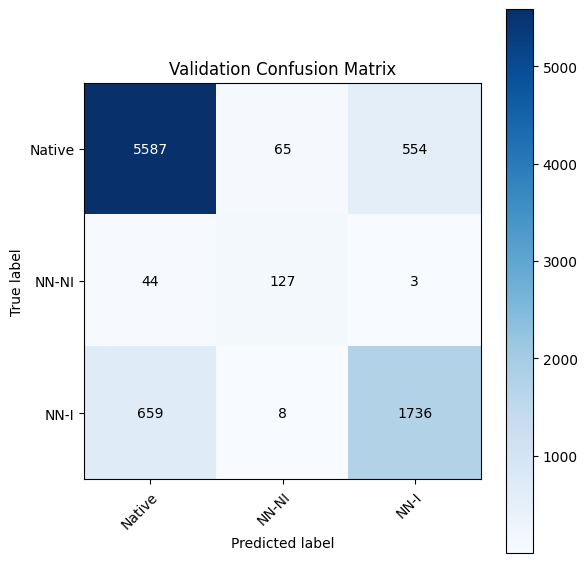


🔁 Epoch 129/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 797.55it/s]


📉 Train Loss: 0.2712 | Accuracy: 0.8834
📈 Val Loss:   0.3529 | Accuracy: 0.8348

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.92      0.84      0.88      6206
NN Non-Invasive       0.57      0.80      0.67       174
    NN Invasive       0.69      0.82      0.75      2403

       accuracy                           0.83      8783
      macro avg       0.73      0.82      0.76      8783
   weighted avg       0.85      0.83      0.84      8783



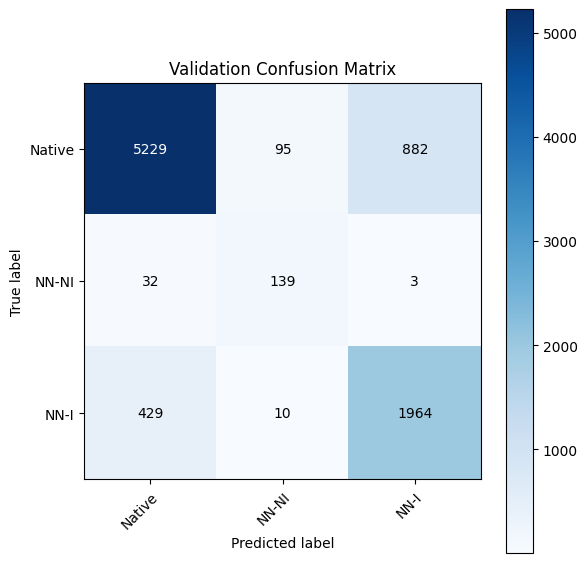


🔁 Epoch 130/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 683.76it/s]


📉 Train Loss: 0.2699 | Accuracy: 0.8829
📈 Val Loss:   0.3468 | Accuracy: 0.8478

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.58      0.79      0.67       174
    NN Invasive       0.76      0.72      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.80      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



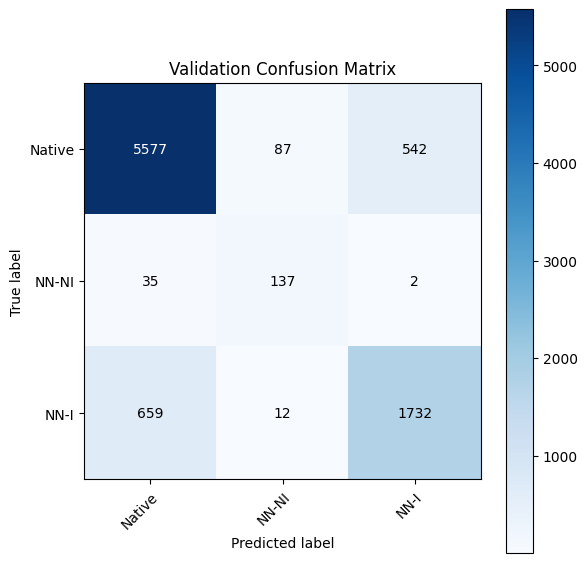


🔁 Epoch 131/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 818.52it/s]


📉 Train Loss: 0.2692 | Accuracy: 0.8850
📈 Val Loss:   0.3428 | Accuracy: 0.8467

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.62      0.74      0.68       174
    NN Invasive       0.74      0.76      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.79      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



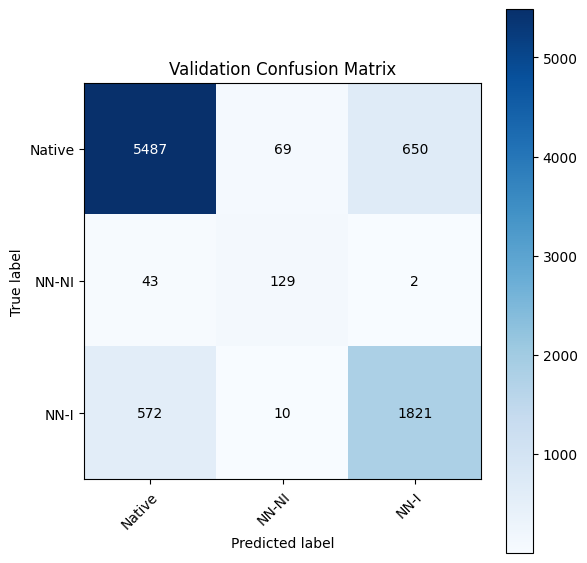


🔁 Epoch 132/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 802.93it/s]


📉 Train Loss: 0.2680 | Accuracy: 0.8849
📈 Val Loss:   0.3435 | Accuracy: 0.8440

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.87      0.89      6206
NN Non-Invasive       0.66      0.70      0.68       174
    NN Invasive       0.71      0.79      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.76      0.78      0.77      8783
   weighted avg       0.85      0.84      0.85      8783



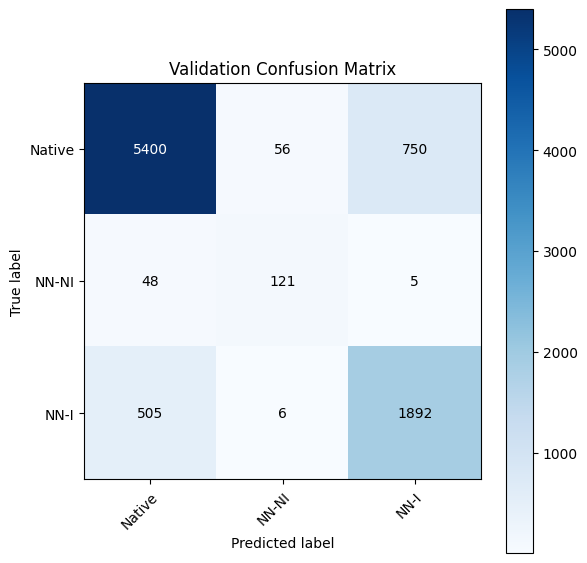


🔁 Epoch 133/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 808.70it/s]


📉 Train Loss: 0.2678 | Accuracy: 0.8856
📈 Val Loss:   0.3460 | Accuracy: 0.8424

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.87      0.89      6206
NN Non-Invasive       0.60      0.79      0.68       174
    NN Invasive       0.72      0.78      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.74      0.81      0.77      8783
   weighted avg       0.85      0.84      0.84      8783



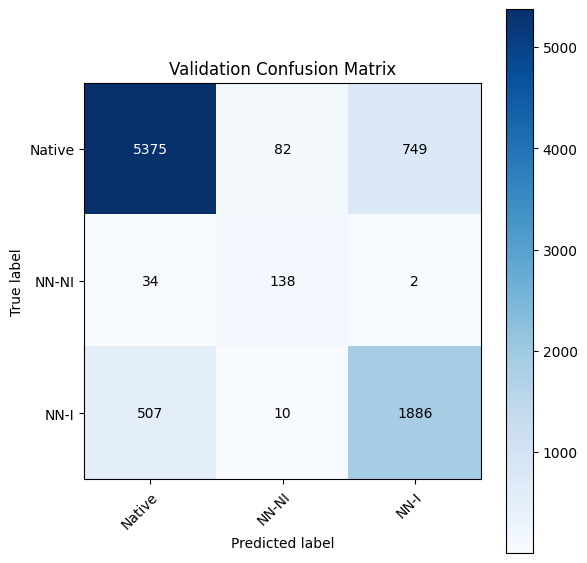


🔁 Epoch 134/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 675.81it/s]


📉 Train Loss: 0.2671 | Accuracy: 0.8856
📈 Val Loss:   0.3423 | Accuracy: 0.8464

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.64      0.71      0.68       174
    NN Invasive       0.73      0.76      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.79      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



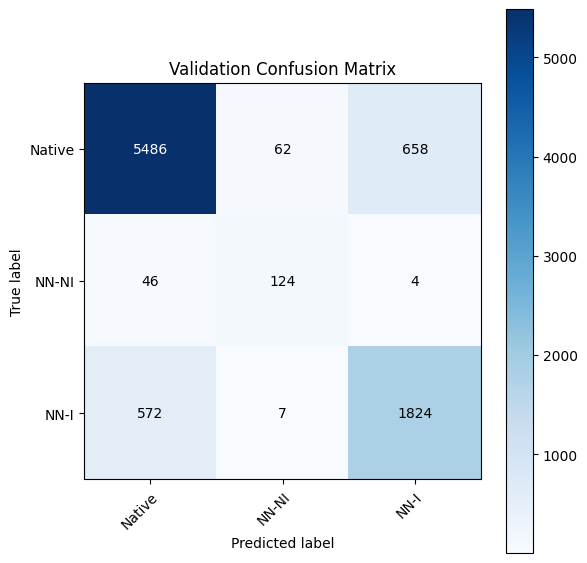


🔁 Epoch 135/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 702.13it/s]


📉 Train Loss: 0.2657 | Accuracy: 0.8862
📈 Val Loss:   0.3456 | Accuracy: 0.8444

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.60      0.79      0.68       174
    NN Invasive       0.73      0.76      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.74      0.81      0.77      8783
   weighted avg       0.85      0.84      0.85      8783



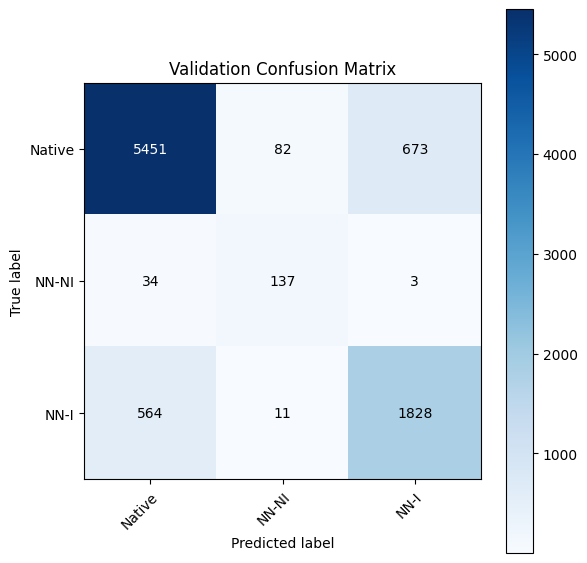


🔁 Epoch 136/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 812.18it/s]


📉 Train Loss: 0.2651 | Accuracy: 0.8862
📈 Val Loss:   0.3420 | Accuracy: 0.8495

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.90      6206
NN Non-Invasive       0.64      0.73      0.68       174
    NN Invasive       0.76      0.72      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.78      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



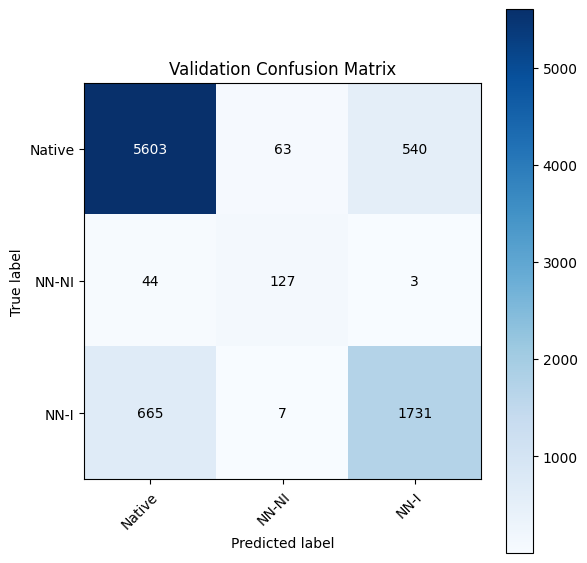


🔁 Epoch 137/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 787.48it/s]


📉 Train Loss: 0.2646 | Accuracy: 0.8857
📈 Val Loss:   0.3438 | Accuracy: 0.8444

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.87      0.89      6206
NN Non-Invasive       0.60      0.79      0.68       174
    NN Invasive       0.72      0.77      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.74      0.81      0.77      8783
   weighted avg       0.85      0.84      0.85      8783



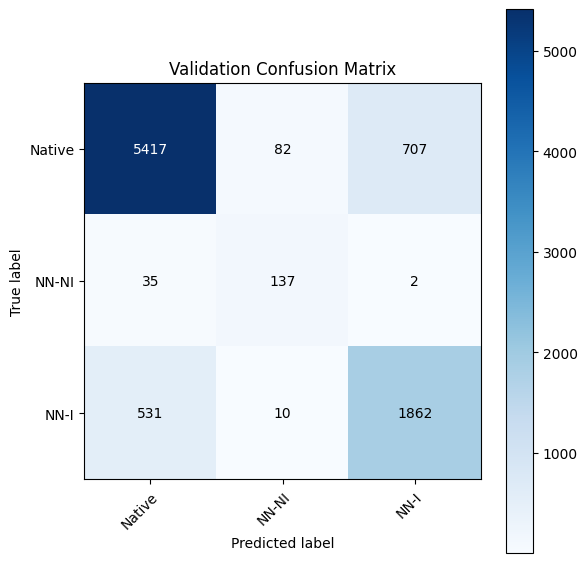


🔁 Epoch 138/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 806.44it/s]


📉 Train Loss: 0.2640 | Accuracy: 0.8872
📈 Val Loss:   0.3444 | Accuracy: 0.8431

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.87      0.89      6206
NN Non-Invasive       0.62      0.76      0.68       174
    NN Invasive       0.72      0.79      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.75      0.81      0.77      8783
   weighted avg       0.85      0.84      0.85      8783



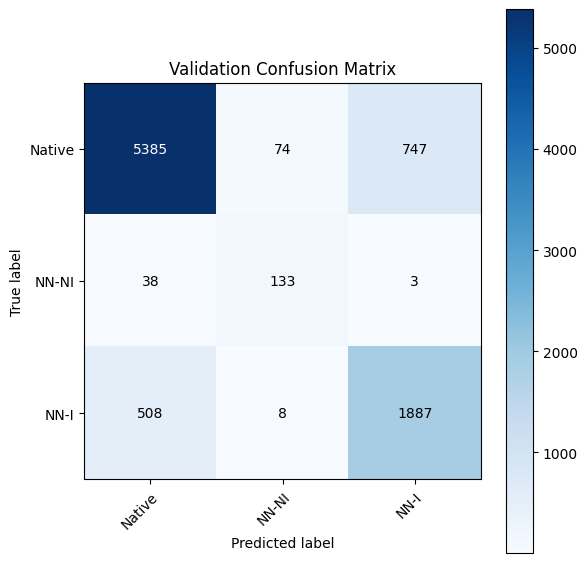


🔁 Epoch 139/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 686.33it/s]


📉 Train Loss: 0.2626 | Accuracy: 0.8879
📈 Val Loss:   0.3418 | Accuracy: 0.8479

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.63      0.71      0.67       174
    NN Invasive       0.75      0.74      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.78      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



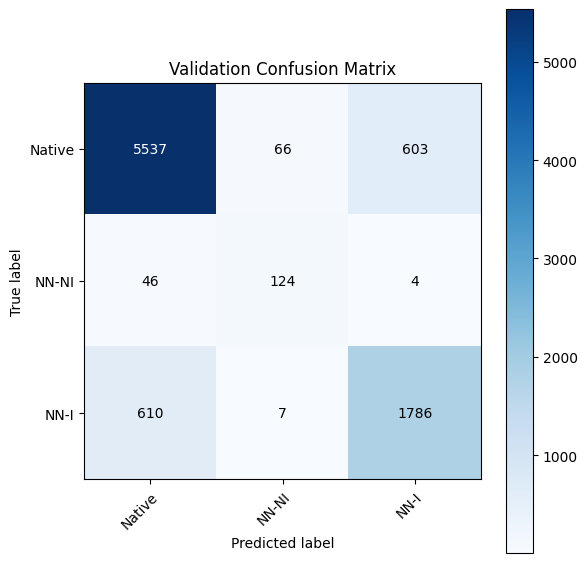


🔁 Epoch 140/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 817.22it/s]


📉 Train Loss: 0.2625 | Accuracy: 0.8876
📈 Val Loss:   0.3466 | Accuracy: 0.8454

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.89      0.89      6206
NN Non-Invasive       0.54      0.83      0.65       174
    NN Invasive       0.75      0.74      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.73      0.82      0.76      8783
   weighted avg       0.85      0.85      0.85      8783



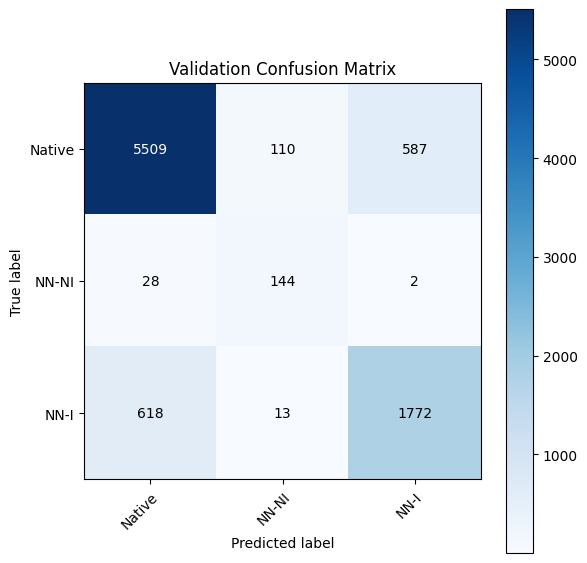


🔁 Epoch 141/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 792.77it/s]


📉 Train Loss: 0.2615 | Accuracy: 0.8879
📈 Val Loss:   0.3489 | Accuracy: 0.8397

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.92      0.85      0.88      6206
NN Non-Invasive       0.58      0.79      0.67       174
    NN Invasive       0.70      0.81      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.82      0.77      8783
   weighted avg       0.85      0.84      0.84      8783



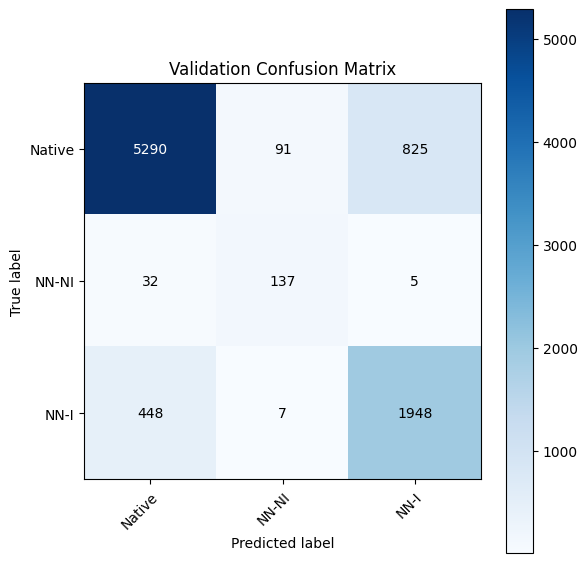


🔁 Epoch 142/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 819.77it/s]


📉 Train Loss: 0.2606 | Accuracy: 0.8882
📈 Val Loss:   0.3406 | Accuracy: 0.8471

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.64      0.74      0.69       174
    NN Invasive       0.73      0.76      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.79      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



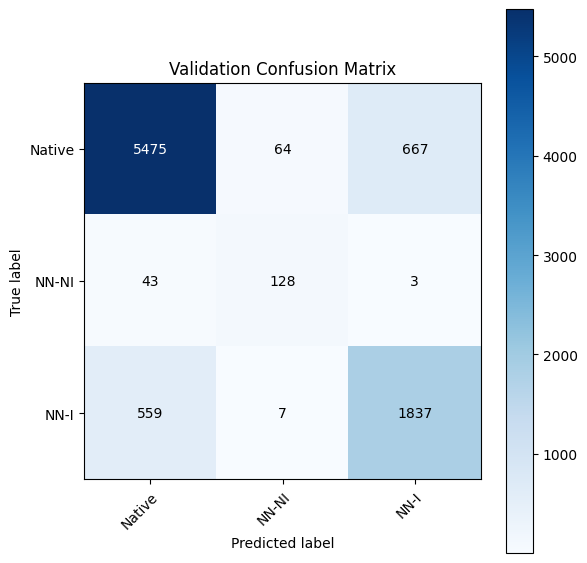


🔁 Epoch 143/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 702.17it/s]


📉 Train Loss: 0.2601 | Accuracy: 0.8889
📈 Val Loss:   0.3435 | Accuracy: 0.8498

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.91      0.90      6206
NN Non-Invasive       0.62      0.72      0.67       174
    NN Invasive       0.77      0.71      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.78      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



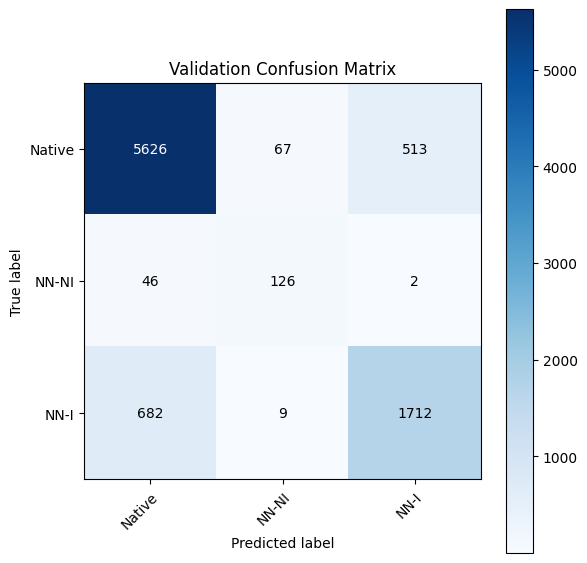


🔁 Epoch 144/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 811.56it/s]


📉 Train Loss: 0.2592 | Accuracy: 0.8898
📈 Val Loss:   0.3432 | Accuracy: 0.8471

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.89      0.89      6206
NN Non-Invasive       0.60      0.77      0.68       174
    NN Invasive       0.74      0.75      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.80      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



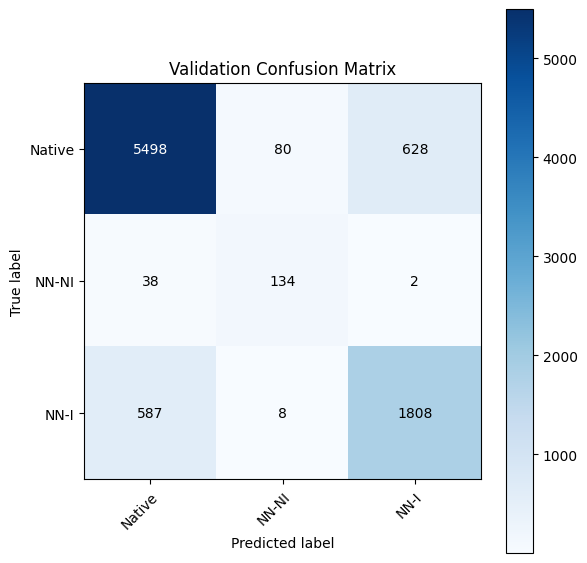


🔁 Epoch 145/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 830.91it/s]


📉 Train Loss: 0.2585 | Accuracy: 0.8895
📈 Val Loss:   0.3429 | Accuracy: 0.8477

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.62      0.78      0.69       174
    NN Invasive       0.75      0.73      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.80      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



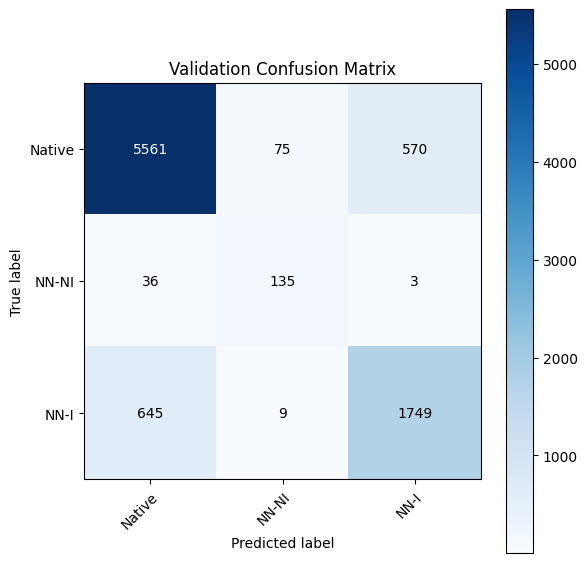


🔁 Epoch 146/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 801.06it/s]


📉 Train Loss: 0.2576 | Accuracy: 0.8903
📈 Val Loss:   0.3416 | Accuracy: 0.8491

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.62      0.78      0.69       174
    NN Invasive       0.76      0.73      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.80      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



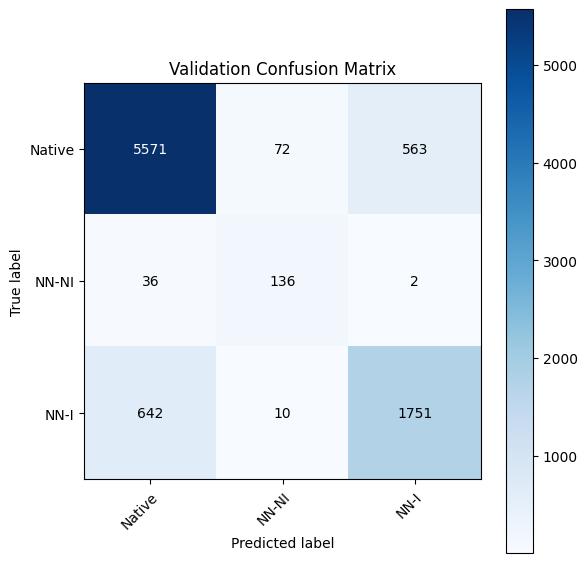


🔁 Epoch 147/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 663.22it/s]


📉 Train Loss: 0.2568 | Accuracy: 0.8903
📈 Val Loss:   0.3466 | Accuracy: 0.8448

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.87      0.89      6206
NN Non-Invasive       0.56      0.84      0.67       174
    NN Invasive       0.73      0.77      0.75      2403

       accuracy                           0.84      8783
      macro avg       0.73      0.83      0.77      8783
   weighted avg       0.85      0.84      0.85      8783



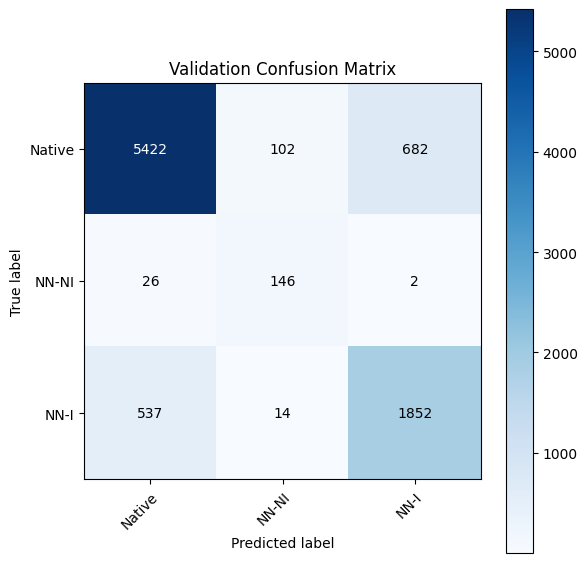


🔁 Epoch 148/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 620.82it/s]


📉 Train Loss: 0.2556 | Accuracy: 0.8919
📈 Val Loss:   0.3415 | Accuracy: 0.8505

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.91      0.90      6206
NN Non-Invasive       0.66      0.71      0.69       174
    NN Invasive       0.77      0.71      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.77      0.78      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



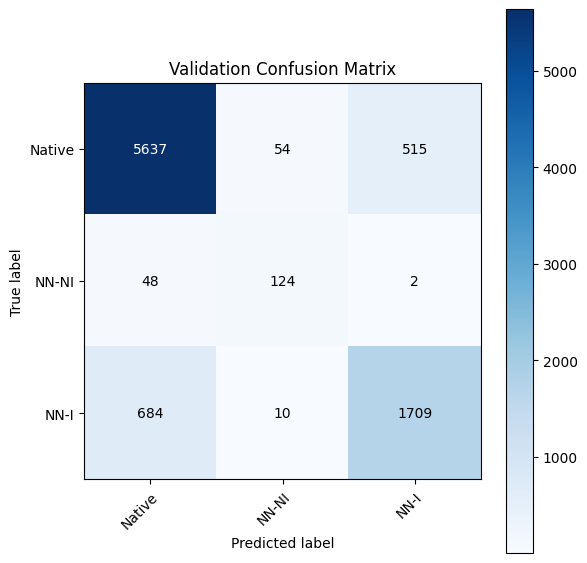


🔁 Epoch 149/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 805.90it/s]


📉 Train Loss: 0.2555 | Accuracy: 0.8923
📈 Val Loss:   0.3418 | Accuracy: 0.8489

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.89      0.89      6206
NN Non-Invasive       0.62      0.80      0.69       174
    NN Invasive       0.75      0.74      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.81      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



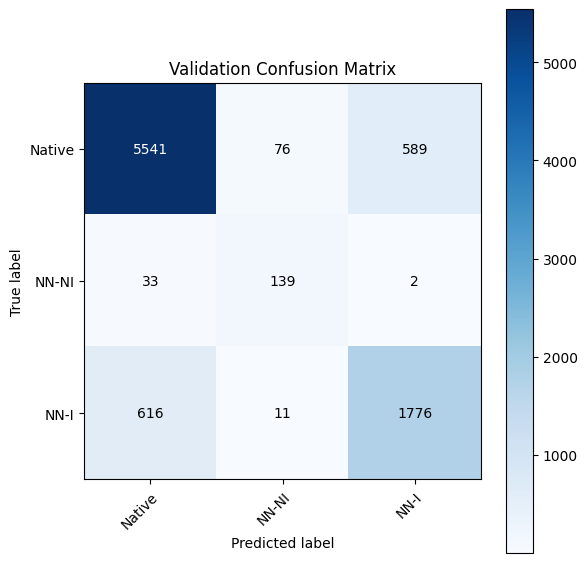


🔁 Epoch 150/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 813.36it/s]


📉 Train Loss: 0.2544 | Accuracy: 0.8911
📈 Val Loss:   0.3415 | Accuracy: 0.8462

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.88      0.89      6206
NN Non-Invasive       0.62      0.79      0.69       174
    NN Invasive       0.73      0.77      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.81      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



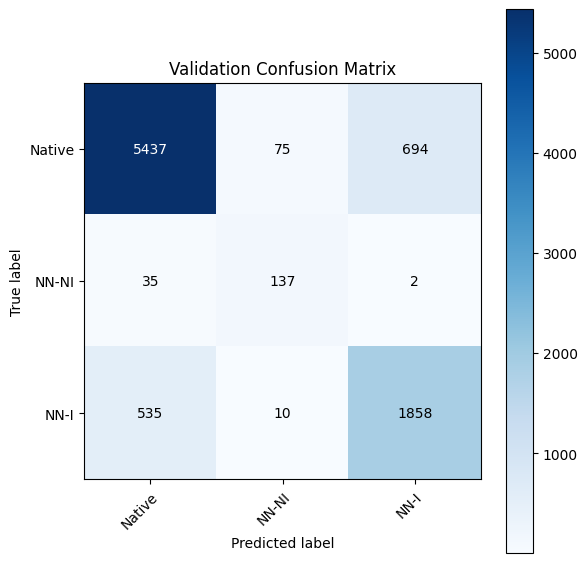


🔁 Epoch 151/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 821.41it/s]


📉 Train Loss: 0.2540 | Accuracy: 0.8916
📈 Val Loss:   0.3405 | Accuracy: 0.8483

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.62      0.76      0.69       174
    NN Invasive       0.75      0.74      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.80      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



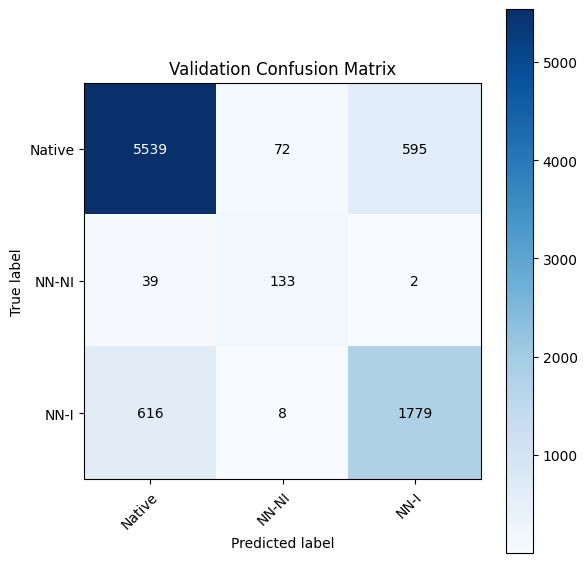


🔁 Epoch 152/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 725.74it/s]


📉 Train Loss: 0.2532 | Accuracy: 0.8925
📈 Val Loss:   0.3441 | Accuracy: 0.8485

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.60      0.80      0.69       174
    NN Invasive       0.76      0.71      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.81      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



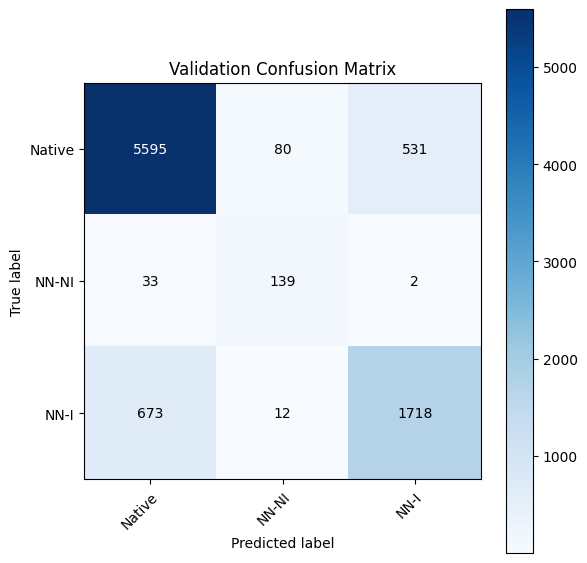


🔁 Epoch 153/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 802.24it/s]


📉 Train Loss: 0.2527 | Accuracy: 0.8920
📈 Val Loss:   0.3437 | Accuracy: 0.8456

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.59      0.82      0.68       174
    NN Invasive       0.73      0.77      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.82      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



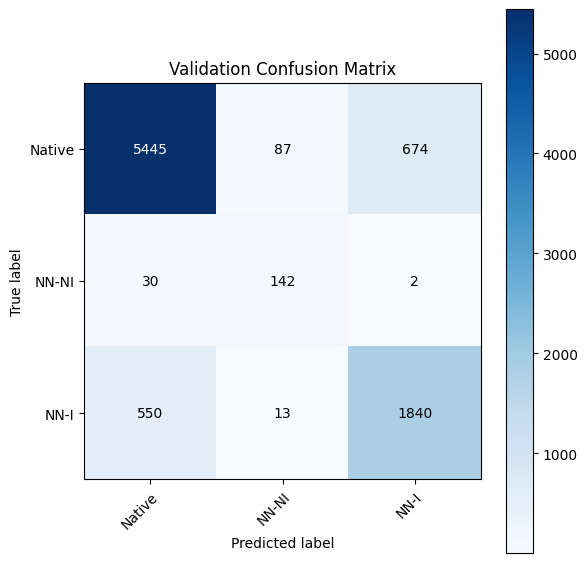


🔁 Epoch 154/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 784.01it/s]


📉 Train Loss: 0.2515 | Accuracy: 0.8924
📈 Val Loss:   0.3402 | Accuracy: 0.8488

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.89      0.89      6206
NN Non-Invasive       0.64      0.77      0.70       174
    NN Invasive       0.75      0.74      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.80      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



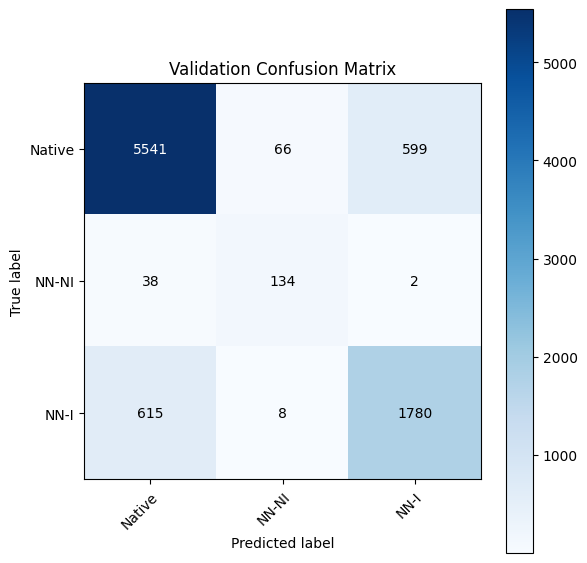


🔁 Epoch 155/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 786.68it/s]


📉 Train Loss: 0.2514 | Accuracy: 0.8935
📈 Val Loss:   0.3397 | Accuracy: 0.8506

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.90      6206
NN Non-Invasive       0.67      0.74      0.70       174
    NN Invasive       0.75      0.74      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.77      0.79      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



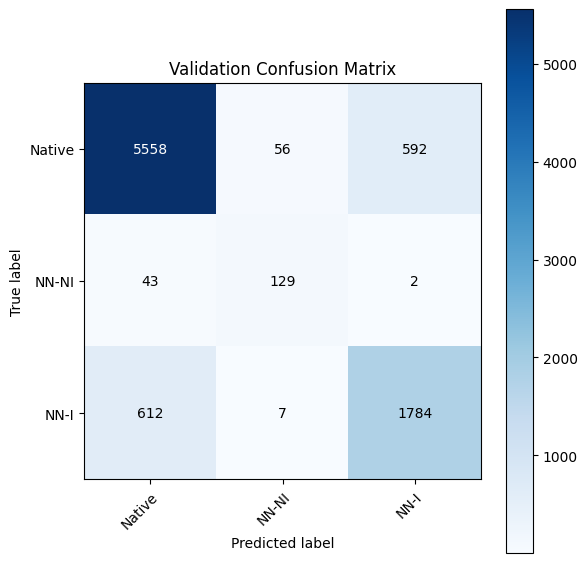


🔁 Epoch 156/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 749.58it/s]


📉 Train Loss: 0.2501 | Accuracy: 0.8945
📈 Val Loss:   0.3414 | Accuracy: 0.8514

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.91      0.90      6206
NN Non-Invasive       0.68      0.74      0.71       174
    NN Invasive       0.77      0.72      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.78      0.79      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



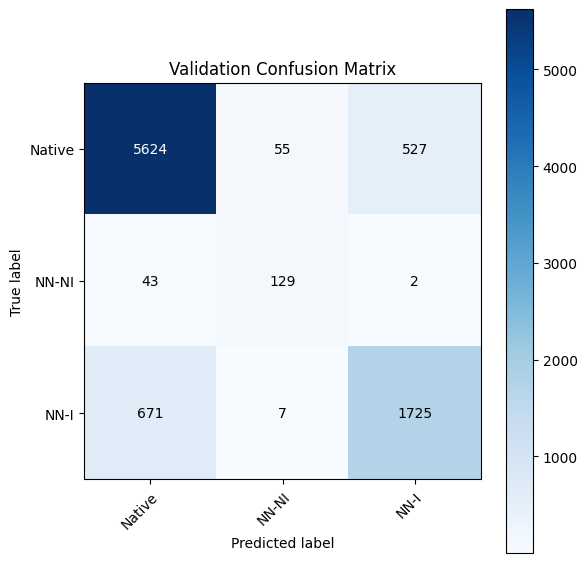


🔁 Epoch 157/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 644.75it/s]


📉 Train Loss: 0.2494 | Accuracy: 0.8950
📈 Val Loss:   0.3452 | Accuracy: 0.8452

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.91      0.87      0.89      6206
NN Non-Invasive       0.59      0.83      0.69       174
    NN Invasive       0.72      0.78      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.83      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



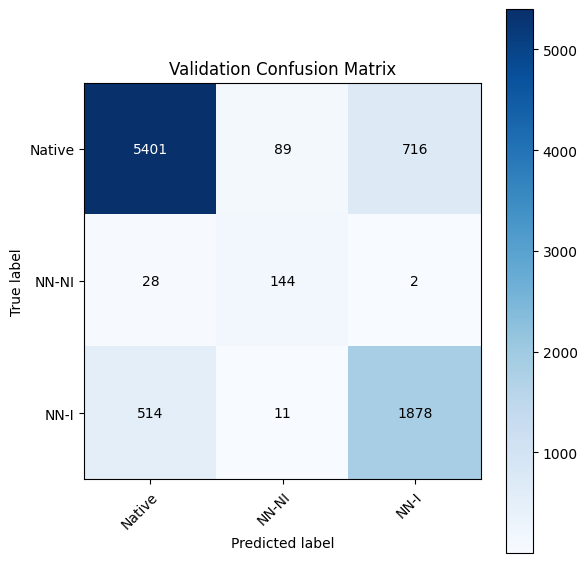


🔁 Epoch 158/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 778.19it/s]


📉 Train Loss: 0.2486 | Accuracy: 0.8953
📈 Val Loss:   0.3400 | Accuracy: 0.8523

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.90      6206
NN Non-Invasive       0.66      0.76      0.71       174
    NN Invasive       0.76      0.73      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.77      0.80      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



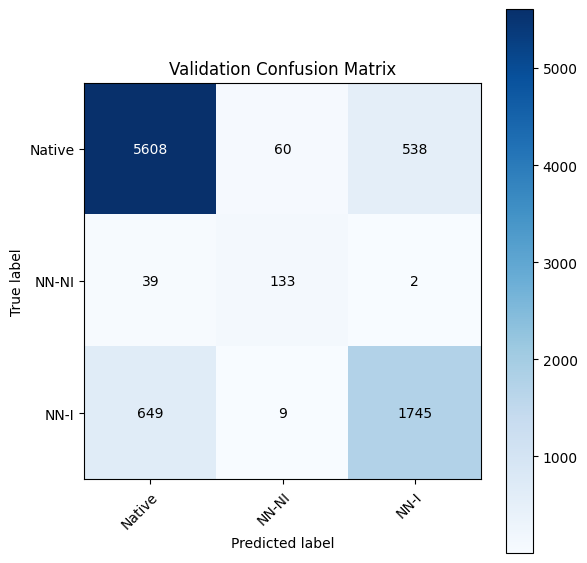


🔁 Epoch 159/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 739.01it/s]


📉 Train Loss: 0.2479 | Accuracy: 0.8957
📈 Val Loss:   0.3423 | Accuracy: 0.8471

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.61      0.80      0.69       174
    NN Invasive       0.74      0.76      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.82      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



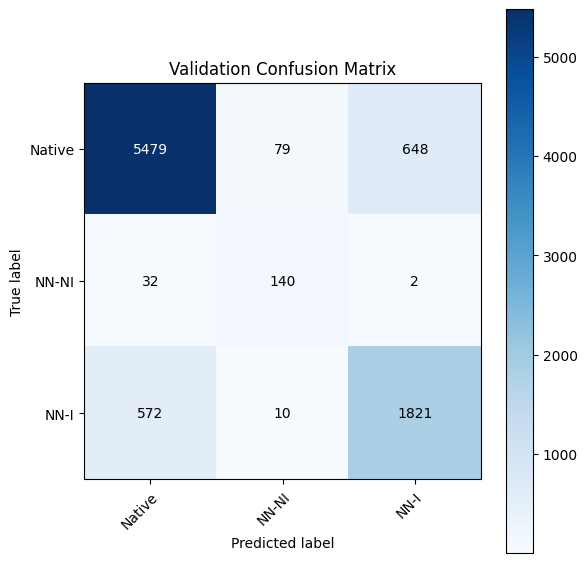


🔁 Epoch 160/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 819.53it/s]


📉 Train Loss: 0.2473 | Accuracy: 0.8963
📈 Val Loss:   0.3402 | Accuracy: 0.8513

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.90      6206
NN Non-Invasive       0.65      0.74      0.69       174
    NN Invasive       0.76      0.73      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.77      0.79      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



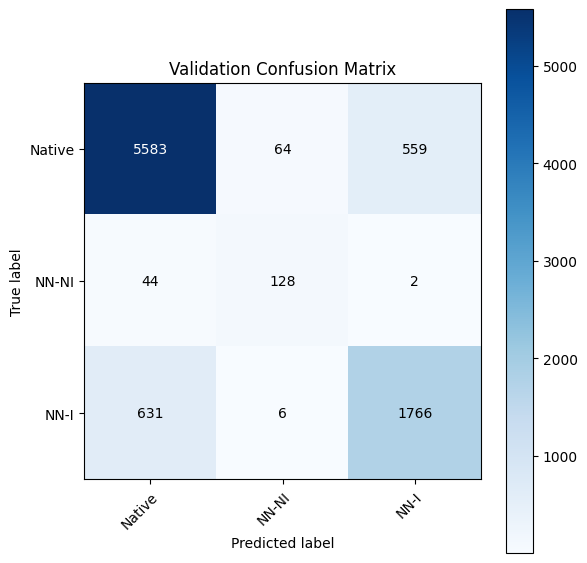


🔁 Epoch 161/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 722.15it/s]


📉 Train Loss: 0.2472 | Accuracy: 0.8954
📈 Val Loss:   0.3426 | Accuracy: 0.8479

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.89      0.89      6206
NN Non-Invasive       0.60      0.78      0.68       174
    NN Invasive       0.75      0.74      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.80      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



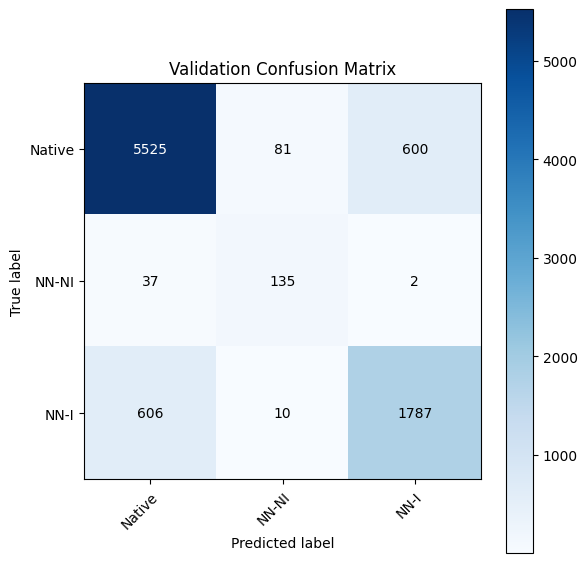


🔁 Epoch 162/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 796.86it/s]


📉 Train Loss: 0.2455 | Accuracy: 0.8964
📈 Val Loss:   0.3423 | Accuracy: 0.8475

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.62      0.80      0.70       174
    NN Invasive       0.73      0.77      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.82      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



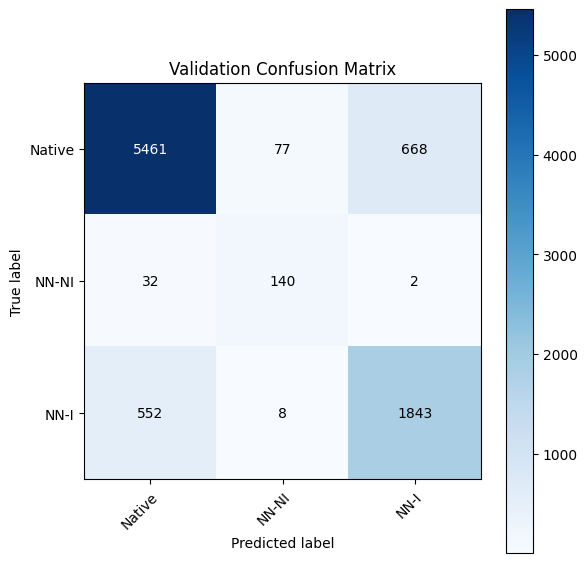


🔁 Epoch 163/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 793.60it/s]


📉 Train Loss: 0.2449 | Accuracy: 0.8969
📈 Val Loss:   0.3459 | Accuracy: 0.8473

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.89      6206
NN Non-Invasive       0.58      0.81      0.68       174
    NN Invasive       0.76      0.71      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.81      0.77      8783
   weighted avg       0.85      0.85      0.85      8783



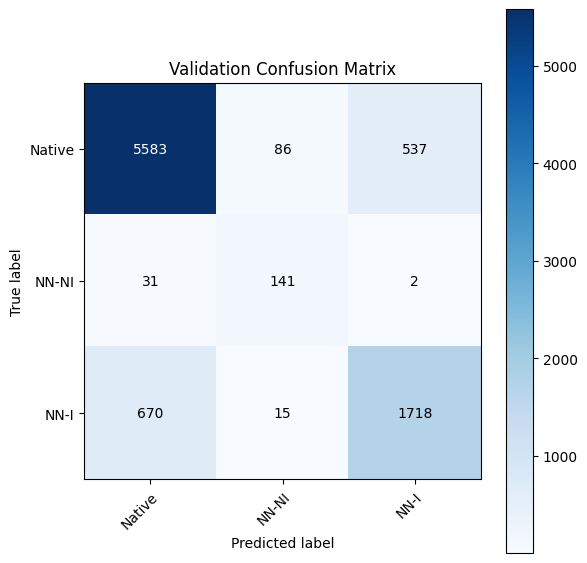


🔁 Epoch 164/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 816.49it/s]


📉 Train Loss: 0.2447 | Accuracy: 0.8969
📈 Val Loss:   0.3396 | Accuracy: 0.8497

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.89      0.89      6206
NN Non-Invasive       0.65      0.78      0.71       174
    NN Invasive       0.75      0.75      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.81      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



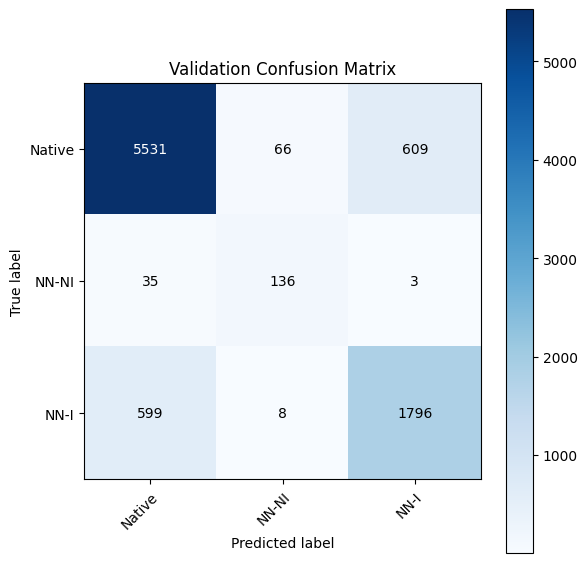


🔁 Epoch 165/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 660.55it/s]


📉 Train Loss: 0.2444 | Accuracy: 0.8970
📈 Val Loss:   0.3433 | Accuracy: 0.8503

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.90      6206
NN Non-Invasive       0.61      0.82      0.70       174
    NN Invasive       0.77      0.72      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.81      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



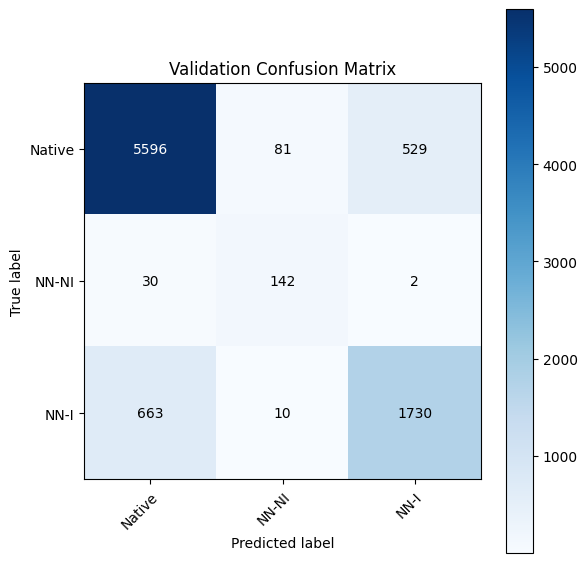


🔁 Epoch 166/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 679.19it/s]


📉 Train Loss: 0.2429 | Accuracy: 0.8970
📈 Val Loss:   0.3409 | Accuracy: 0.8511

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.90      6206
NN Non-Invasive       0.65      0.78      0.71       174
    NN Invasive       0.76      0.72      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.77      0.80      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



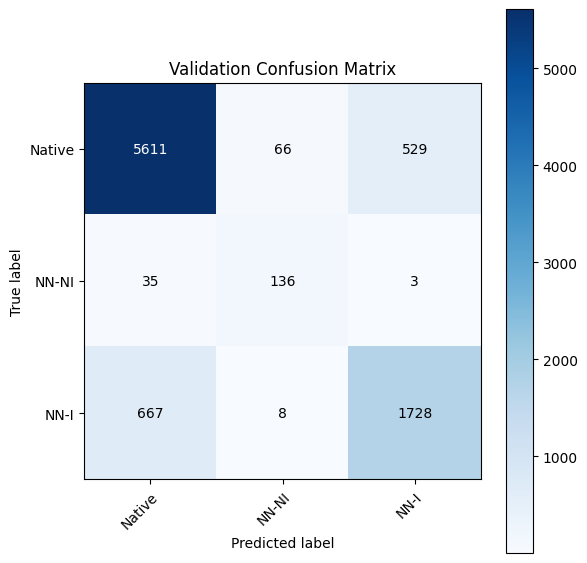


🔁 Epoch 167/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 832.94it/s]


📉 Train Loss: 0.2426 | Accuracy: 0.8986
📈 Val Loss:   0.3398 | Accuracy: 0.8496

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.90      6206
NN Non-Invasive       0.65      0.74      0.69       174
    NN Invasive       0.76      0.73      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.79      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



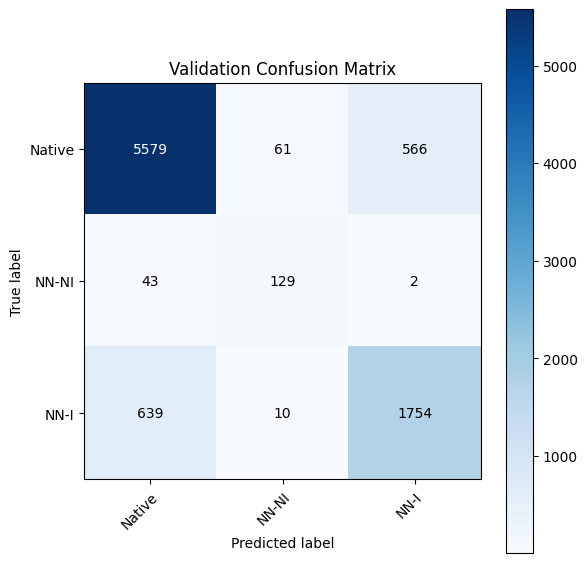


🔁 Epoch 168/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 805.62it/s]


📉 Train Loss: 0.2414 | Accuracy: 0.8981
📈 Val Loss:   0.3425 | Accuracy: 0.8515

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.91      0.90      6206
NN Non-Invasive       0.62      0.79      0.69       174
    NN Invasive       0.78      0.71      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.80      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



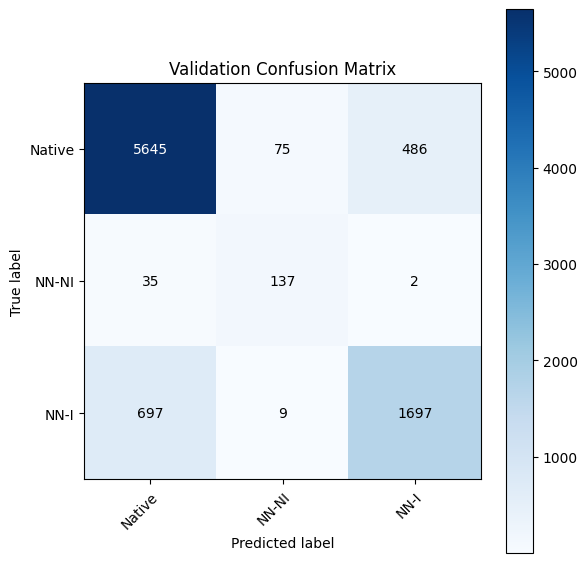


🔁 Epoch 169/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 778.45it/s]


📉 Train Loss: 0.2407 | Accuracy: 0.8990
📈 Val Loss:   0.3410 | Accuracy: 0.8489

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.88      0.89      6206
NN Non-Invasive       0.66      0.71      0.69       174
    NN Invasive       0.73      0.77      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.77      0.79      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



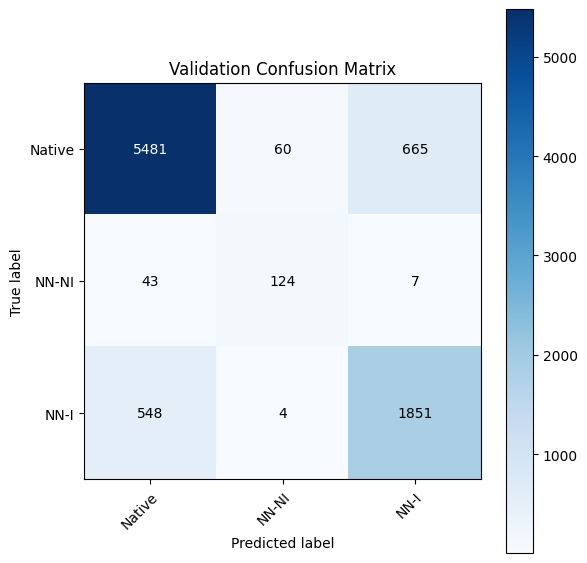


🔁 Epoch 170/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 655.99it/s]


📉 Train Loss: 0.2402 | Accuracy: 0.8992
📈 Val Loss:   0.3409 | Accuracy: 0.8490

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.89      0.89      6206
NN Non-Invasive       0.60      0.81      0.69       174
    NN Invasive       0.75      0.75      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.75      0.82      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



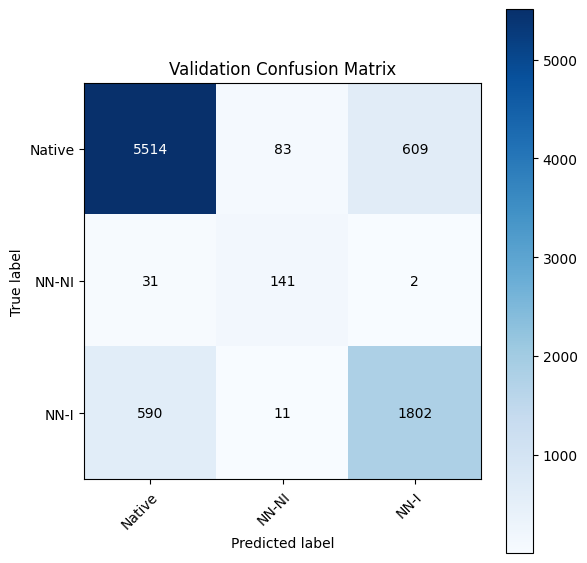


🔁 Epoch 171/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 781.86it/s]


📉 Train Loss: 0.2394 | Accuracy: 0.9001
📈 Val Loss:   0.3469 | Accuracy: 0.8454

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.92      0.86      0.89      6206
NN Non-Invasive       0.60      0.80      0.69       174
    NN Invasive       0.72      0.80      0.76      2403

       accuracy                           0.85      8783
      macro avg       0.74      0.82      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



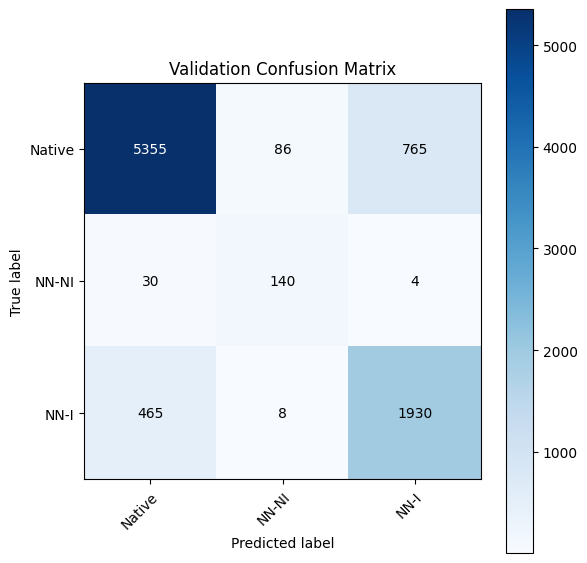


🔁 Epoch 172/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 775.98it/s]


📉 Train Loss: 0.2394 | Accuracy: 0.8994
📈 Val Loss:   0.3409 | Accuracy: 0.8514

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.90      0.90      6206
NN Non-Invasive       0.62      0.81      0.70       174
    NN Invasive       0.76      0.74      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.81      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



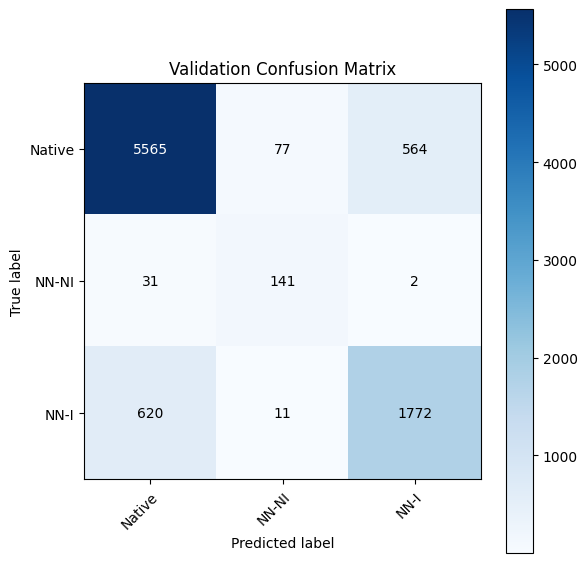


🔁 Epoch 173/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 754.64it/s]


📉 Train Loss: 0.2381 | Accuracy: 0.9008
📈 Val Loss:   0.3403 | Accuracy: 0.8516

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.91      0.90      6206
NN Non-Invasive       0.65      0.79      0.71       174
    NN Invasive       0.77      0.72      0.74      2403

       accuracy                           0.85      8783
      macro avg       0.77      0.81      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



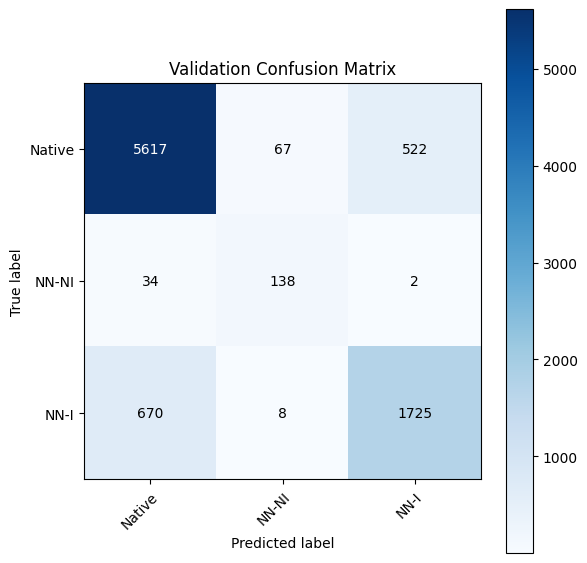


🔁 Epoch 174/10000


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 807.10it/s]


📉 Train Loss: 0.2380 | Accuracy: 0.9000
📈 Val Loss:   0.3400 | Accuracy: 0.8521

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.90      0.90      6206
NN Non-Invasive       0.64      0.79      0.70       174
    NN Invasive       0.76      0.73      0.75      2403

       accuracy                           0.85      8783
      macro avg       0.76      0.81      0.78      8783
   weighted avg       0.85      0.85      0.85      8783



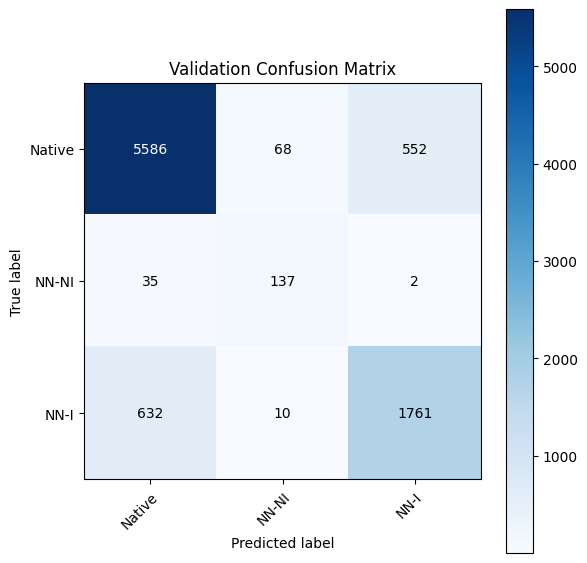

Stopping early as no improvement has been observed.
Early stopping at epoch 173
📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


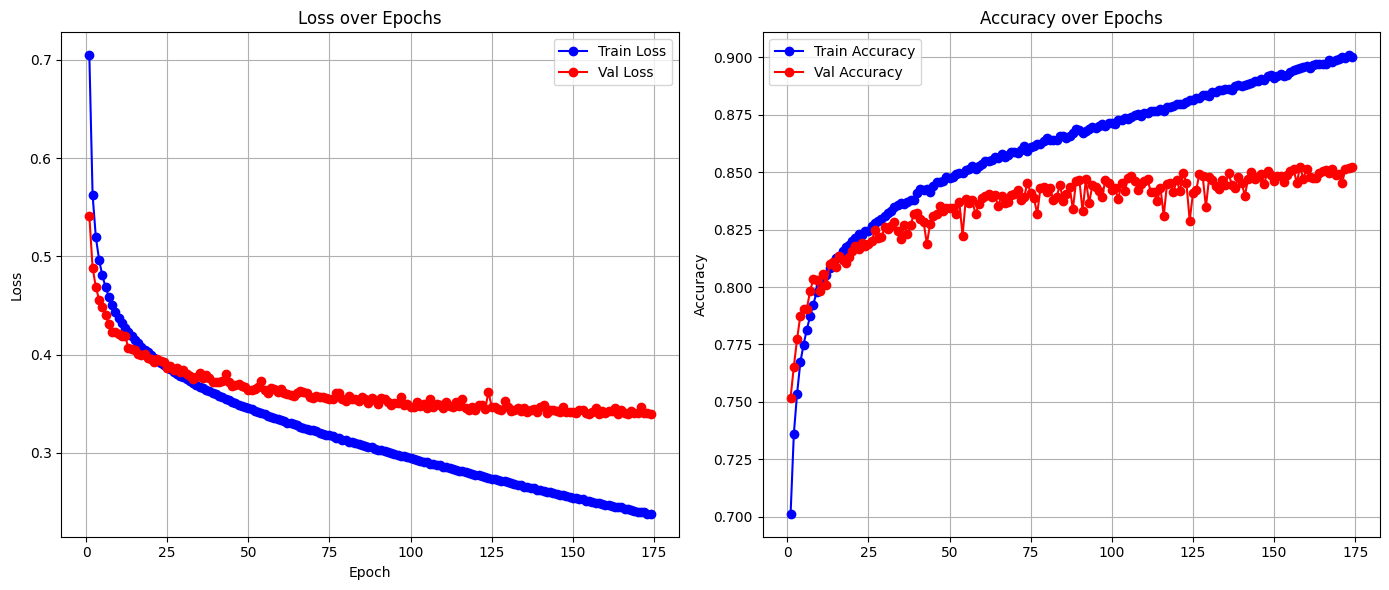

Full model built...
Total execution time: 704.73 seconds


(0.34002251908323916, 0.852100648980986)

In [22]:
#USARE VALORI DI BESTHP COME PARAMETRI

final_HP_search = {'augmentation': True, 'loss_type': 'CE', 'factor': 2, 'val_loss': 0.35223526106626696, 'val_accuracy': 0.8417397244677217}
embeddings_save_path_BC2 = '/content/drive/MyDrive/Thesis/bioclip_2_embeddings.pt'
model_name_final = 'best_HP_10000_epochs'
epochs=10000

create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=final_HP_search['augmentation'],
                                          augmentation_factor=final_HP_search['factor'], loss_type=final_HP_search['loss_type'],
                                         bioclip_version=2, output_dir="invasive_species", model_name=model_name_final,
                                           save_model=True, verbose=True, embeddings_save_path=embeddings_save_path_BC2,
                                             epochs=epochs, debug_subset_size=None)